# Hospital Readmission Analytics

## Data Quality Assessment

**Project Type:** Healthcare Data Analytics  
**Domain:** Hospital Readmissions / Diabetes  
**Tool:** Python / Pandas  

---

## 1. Objective

The objective of this notebook is to assess the quality of the raw healthcare dataset before performing data cleaning and analysis.

We will identify:

- Missing values
- Placeholder values
- Duplicate records
- Unexpected or inconsistent values
- Categorical variable representations
- Variables requiring transformation

The purpose of this assessment is to understand the data-quality issues before deciding how they should be handled.

---

## 2. Data Quality Workflow

The assessment follows this process:

**Load Data → Check Missing Values → Check Placeholders → Check Duplicates → Examine Categories → Identify Issues → Define Cleaning Strategy**

No data-cleaning transformations will be performed until the data-quality issues have been documented.

## 3. Import Libraries

We will use Pandas and NumPy for data loading and data-quality assessment.

In [2]:
import pandas as pd
import numpy as np

## 4. Load Raw Dataset

The original dataset is stored in the `01_Raw_Data` folder.

We will load the raw CSV file into a Pandas DataFrame named `df`.

The original CSV file will not be modified.

In [3]:
file_path = "../01_Raw_Data/diabetic_data.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 101766
Columns: 50


## 5. Missing Value Assessment

Missing values are important in healthcare analytics because incomplete clinical or administrative information can affect analysis and potentially introduce bias.

We will first count missing values in every column.

In [4]:
missing_values = df.isnull().sum()
missing_values

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### 5.1 Columns Containing Missing Values

The following code displays only variables that contain one or more actual missing values.

In [5]:
missing_values[missing_values > 0]

max_glu_serum    96420
A1Cresult        84748
dtype: int64

### 5.2 Missing Value Percentage

We calculate the percentage of records with missing values for each variable.

This helps us understand the magnitude of each missing-data problem relative to the size of the dataset.

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64

### 5.3 Missing Value Summary Table

We combine the missing-value count and percentage into a single summary table.

In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_summary = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)
missing_summary

,Missing Count,Missing Percentage
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322


## 6. Placeholder Value Assessment

Not all missing information is represented as a standard `NaN` value.

In this dataset, some variables use the character `?` to represent unavailable or unknown information.

Because Pandas treats `?` as a regular text value, these records were not included in the previous missing-value assessment.

We will identify where the `?` placeholder occurs and measure its frequency before deciding how it should be handled.

In [8]:
question_mark_counts = (df == "?").sum()
question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

### 6.1 Percentage of Placeholder Values

We calculate the percentage of records containing `?` in each affected variable.

This provides a better understanding of the scale of the data-quality issue.

In [9]:
question_mark_percentage = ((df == "?").sum() / len(df)) * 100
question_mark_percentage[question_mark_percentage > 0].sort_values(
    ascending=False
)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

### 6.2 Placeholder Value Summary

The following table combines the number and percentage of `?` placeholder values for each affected variable.

In [10]:
question_mark_summary = pd.DataFrame({
    "Placeholder Count": (df == "?").sum(),
    "Placeholder Percentage": ((df == "?").sum() / len(df)) * 100
})
question_mark_summary = (
    question_mark_summary[question_mark_summary["Placeholder Count"] > 0]
    .sort_values("Placeholder Percentage", ascending=False)
)
question_mark_summary

,Placeholder Count,Placeholder Percentage
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## 7. Duplicate Record Assessment

Duplicate records can lead to double-counting and incorrect analytical results.

We will perform two checks:

1. Duplicate complete rows
2. Duplicate `encounter_id` values

The encounter ID check was performed in the previous validation stage, but it is included here as part of the overall data-quality assessment.

In [11]:
duplicate_rows = df.duplicated().sum()
print("Duplicate complete rows:", duplicate_rows)

Duplicate complete rows: 0


In [12]:
duplicate_encounter_ids = df["encounter_id"].duplicated().sum()
print("Duplicate encounter IDs:", duplicate_encounter_ids)

Duplicate encounter IDs: 0


## 8. Categorical Variable Assessment

Categorical variables contain a limited set of possible values.

Before cleaning categorical variables, we need to understand the categories actually present in the dataset.

We will begin with the `gender` variable.

In [13]:
df["gender"].value_counts(dropna=False)

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

## 9. Target Variable Assessment

The primary outcome variable for this project is `readmitted`.

It indicates whether the patient was:

- Not readmitted
- Readmitted within 30 days
- Readmitted after 30 days

We will examine the distribution of these categories before creating any analytical variables.

In [14]:
df["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## 10. Categorical Variable Exploration

We will examine important categorical variables to identify:

- The categories present in the raw data
- Their frequencies
- Unknown or invalid categories
- Placeholder values
- Variables requiring interpretation or transformation

This assessment will help us design the data-cleaning strategy.

In [15]:
df["age"].value_counts(dropna=False).sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

### 10.1 Race

Race is a categorical demographic variable.

We will examine its distribution and identify any placeholder or unknown values.

In [16]:
df["race"].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

### 10.2 Admission Type

`admission_type_id` is a coded variable describing the type of hospital admission.

We will first examine the codes present in the raw dataset.

The meaning of each code will be interpreted using the dataset documentation rather than assumed from the numeric value.

In [17]:
df["admission_type_id"].value_counts(dropna=False).sort_index()

admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

### 10.3 Discharge Disposition

`discharge_disposition_id` contains coded information about the patient's disposition at discharge.

We will examine the available codes and their frequencies before determining whether any codes require special handling.

In [18]:
df["discharge_disposition_id"].value_counts(dropna=False).sort_index()

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

### 10.4 Admission Source

`admission_source_id` contains coded information about how the patient was admitted to the hospital.

We will examine the available codes before transforming or interpreting them.

In [19]:
df["admission_source_id"].value_counts(dropna=False).sort_index()

admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64

# 11. Data Quality Inventory

Based on the validation and exploratory checks, several data-quality issues have been identified.

### Identified Issues

| Variable | Issue | Magnitude |
|---|---|---:|
| `max_glu_serum` | Actual missing values | 94.75% |
| `A1Cresult` | Actual missing values | 83.28% |
| `weight` | `?` placeholder | 96.86% |
| `medical_specialty` | `?` placeholder | 49.08% |
| `payer_code` | `?` placeholder | 39.56% |
| `race` | `?` placeholder | 2.23% |
| `diag_3` | `?` placeholder | 1.40% |
| `diag_2` | `?` placeholder | 0.35% |
| `diag_1` | `?` placeholder | 0.02% |
| `gender` | `Unknown/Invalid` | 3 records |

### Duplicate Assessment

- Duplicate complete records: **0**
- Duplicate encounter IDs: **0**

### Categorical Variables

The dataset contains coded variables including:

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

These codes will be interpreted using the dataset documentation before transformation.

# 12. Data Cleaning Strategy

The cleaning process will be based on the data-quality assessment rather than applying automatic deletion or imputation rules.

### 12.1 Placeholder Values

The `?` character will be treated as missing information for variables where it represents unavailable data.

We will convert these placeholders to a consistent missing-value representation during the cleaning stage.

### 12.2 High-Missingness Variables

Variables with very high levels of missing information will not automatically be deleted.

Their analytical usefulness will be evaluated based on:

- Missingness level
- Clinical relevance
- Relationship to the project objective
- Potential impact on analysis

### 12.3 Categorical Variables

Categorical variables will be standardized where appropriate.

Unknown or invalid categories will be handled separately from genuine clinical categories.

### 12.4 Coded Variables

Variables such as `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` will be mapped using the dataset's documented definitions.

We will not infer the meaning of numeric codes from their values alone.

### 12.5 Target Variable

The original `readmitted` variable will be preserved.

A separate analytical variable representing 30-day readmission will be created later.

### 12.6 Raw Data Preservation

The original CSV file will remain unchanged.

All transformations will be performed programmatically so that the cleaning process is reproducible.

# 13. Create Working Copy for Cleaning

To preserve the raw dataset within our Python workflow, we create a separate working copy.

The original `df` DataFrame will remain unchanged.

All cleaning operations will be performed on `df_clean`.

In [20]:
df_clean = df.copy()
print("Working copy created.")
print("Raw dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Working copy created.
Raw dataset shape: (101766, 50)
Working dataset shape: (101766, 50)


## 13.1 Standardize Placeholder Missing Values

The dataset uses `?` as a placeholder for unavailable information in several categorical variables.

We will convert `?` to `NaN` so that Pandas and subsequent analytical tools can consistently recognize these values as missing.

This transformation is performed only on `df_clean`.

In [21]:
df_clean = df_clean.replace("?", np.nan)

### 13.2 Verify Placeholder Conversion

We will verify that the `?` placeholders have been converted to missing values.

In [22]:
question_mark_remaining = (df_clean == "?").sum().sum()
print("Remaining '?' values:", question_mark_remaining)

Remaining '?' values: 0


In [23]:
df_clean.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
patient_nbr              0
dtype: int64

## 9. Data Cleaning Decision Log

The dataset contains both actual missing values and placeholder values. Placeholder values (`?`) have been converted to standard `NaN` values.

Variables with substantial missingness will not be automatically removed. Each variable will be evaluated based on:

- Percentage of missing values
- Relevance to the business question
- Potential analytical value
- Risk of introducing bias
- Availability of sufficient observations

The raw dataset will remain unchanged. All cleaning and transformation steps will be performed on the working copy (`df_clean`).

### Initial Cleaning Decisions

- `weight`: Very high missingness; unlikely to provide reliable population-level analysis. Candidate for exclusion from the core analysis.
- `max_glu_serum`: Very high missingness; candidate for exclusion from the core analysis.
- `A1Cresult`: High missingness; candidate for exclusion from the core analysis.
- `medical_specialty`: Substantial missingness; requires further evaluation before deciding.
- `payer_code`: Substantial missingness and limited relevance to the primary readmission question; requires evaluation.
- `race`: Low missingness; retain.
- `diag_1`, `diag_2`, `diag_3`: Low missingness; retain for potential diagnosis-related analysis.

No columns will be permanently removed until their analytical relevance has been evaluated.

## 10. Missingness Assessment After Standardization

After converting placeholder values to `NaN`, missingness is reassessed to understand the extent of incomplete information across variables.

In [24]:
missing_summary_clean = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
})
missing_summary_clean = (
    missing_summary_clean[missing_summary_clean["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)
missing_summary_clean

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## 11. Handling High-Missingness Variables

Variables with extremely high levels of missingness may provide limited reliable information for the core analysis.

For this project, variables with more than 80% missing values will be excluded from the primary analytical dataset:

- `weight`
- `max_glu_serum`
- `A1Cresult`

These variables are excluded from the core analysis because the large proportion of missing observations would substantially reduce the available information.

Variables with lower but still substantial missingness, such as `medical_specialty` and `payer_code`, will be retained temporarily and evaluated separately.

The original raw dataset remains unchanged.

In [25]:
high_missing_columns = [
    "weight",
    "max_glu_serum",
    "A1Cresult"
]
print("Columns identified for exclusion:")
for column in high_missing_columns:
    print("-", column)

Columns identified for exclusion:
- weight
- max_glu_serum
- A1Cresult


### 11.1 Creating the Analytical Dataset

A separate analytical dataset is created from the cleaned working dataset.

This preserves the cleaned dataset while allowing us to build a focused dataset for readmission analysis.

In [26]:
df_analysis = df_clean.drop(columns=high_missing_columns)
print("Original cleaned dataset shape:", df_clean.shape)
print("Analytical dataset shape:", df_analysis.shape)

Original cleaned dataset shape: (101766, 50)
Analytical dataset shape: (101766, 47)


In [27]:
remaining_high_missing = [
    column for column in high_missing_columns
    if column in df_analysis.columns
]
print("High-missingness columns still present:", remaining_high_missing)

High-missingness columns still present: []


## 12. Remaining Missing Values in the Analytical Dataset

After excluding variables with extremely high missingness, the remaining variables are reassessed.

The purpose of this step is to determine whether additional handling is required before analysis.

Variables with relatively low missingness may be retained without imputation for analyses where the missing values are not required.

Variables with substantial missingness will be reviewed based on their analytical relevance rather than removed automatically.

In [28]:
remaining_missing = pd.DataFrame({
    "Missing Count": df_analysis.isnull().sum(),
    "Missing Percentage": (df_analysis.isnull().sum() / len(df_analysis)) * 100
})
remaining_missing = (
    remaining_missing[remaining_missing["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)
remaining_missing

,Missing Count,Missing Percentage
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## 13. Creating the 30-Day Readmission Outcome

The original `readmitted` variable contains three categories:

- `NO`: The patient was not readmitted during the relevant follow-up period.
- `>30`: The patient was readmitted after 30 days.
- `<30`: The patient was readmitted within 30 days.

For the primary analysis, the outcome of interest is 30-day readmission.

A new binary variable, `readmitted_30d`, will therefore be created:

- `<30` → 1 (30-day readmission)
- `NO` → 0 (No 30-day readmission)
- `>30` → 0 (No 30-day readmission)

The original `readmitted` variable will be preserved.

In [29]:
df_analysis["readmitted_30d"] = (
    df_analysis["readmitted"] == "<30"
).astype(int)
print("30-day readmission variable created.")

30-day readmission variable created.


In [30]:
df_analysis["readmitted_30d"].value_counts().sort_index()

readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

### 13.1 Overall 30-Day Readmission Rate

The overall 30-day readmission rate represents the proportion of hospital encounters in which the patient was readmitted within 30 days.

This metric will serve as the baseline against which different patient and encounter characteristics can be compared.

In [31]:
readmission_rate = df_analysis["readmitted_30d"].mean() * 100
print(f"Overall 30-day readmission rate: {readmission_rate:.2f}%")

Overall 30-day readmission rate: 11.16%


In [32]:
comparison = pd.crosstab(
    df_analysis["readmitted"],
    df_analysis["readmitted_30d"]
)
comparison

readmitted_30d,0,1
readmitted,,
<30,0,11357
>30,35545,0
NO,54864,0


## 14. Key Variable Review

Before conducting exploratory analysis, key variables are reviewed according to their analytical role.

Variables are classified into:

- Patient characteristics
- Encounter characteristics
- Clinical characteristics
- Utilization/history variables
- Outcome variables

This helps ensure that variables are interpreted correctly during analysis.

In [33]:
key_columns = [
    "patient_nbr",
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted",
    "readmitted_30d"
]
df_analysis[key_columns].head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,readmitted_30d
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,NO,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,>30,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,NO,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,NO,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,NO,0


In [34]:
df_analysis[key_columns].dtypes

patient_nbr                 int64
race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
number_diagnoses            int64
readmitted                    str
readmitted_30d              int64
dtype: object

In [35]:
numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]
df_analysis[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


## 15. Age and 30-Day Readmission

Age group is evaluated to determine whether the proportion of encounters resulting in 30-day readmission differs across age categories.

Because age groups contain different numbers of encounters, readmission rate rather than readmission count will be used for comparison.

Readmission rate is calculated as:

30-Day Readmission Rate = 30-Day Readmissions / Total Encounters × 100

In [36]:
age_analysis = (
    df_analysis
    .groupby("age")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
age_analysis["readmission_rate"] = (
    age_analysis["readmissions_30d"]
    / age_analysis["total_encounters"]
    * 100
)
age_analysis

,age,total_encounters,readmissions_30d,readmission_rate
0,[0-10),161,3,1.863354
1,[10-20),691,40,5.788712
2,[20-30),1657,236,14.242607
3,[30-40),3775,424,11.231788
4,[40-50),9685,1027,10.604027
5,[50-60),17256,1668,9.666203
6,[60-70),22483,2502,11.128408
7,[70-80),26068,3069,11.773055
8,[80-90),17197,2078,12.083503
9,[90-100),2793,310,11.099177


In [37]:
age_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,age,total_encounters,readmissions_30d,readmission_rate
2,[20-30),1657,236,14.242607
8,[80-90),17197,2078,12.083503
7,[70-80),26068,3069,11.773055
3,[30-40),3775,424,11.231788
6,[60-70),22483,2502,11.128408
9,[90-100),2793,310,11.099177
4,[40-50),9685,1027,10.604027
5,[50-60),17256,1668,9.666203
1,[10-20),691,40,5.788712
0,[0-10),161,3,1.863354


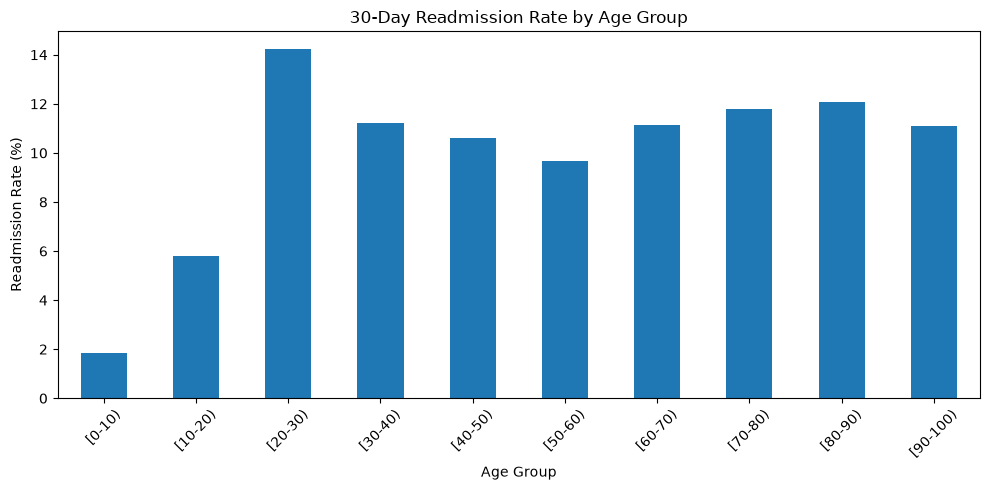

In [38]:
import matplotlib.pyplot as plt
age_chart = age_analysis.sort_values("age")
age_chart.plot(
    x="age",
    y="readmission_rate",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="30-Day Readmission Rate by Age Group"
)
plt.ylabel("Readmission Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Gender and 30-Day Readmission

Gender is evaluated to determine whether the observed 30-day readmission rate differs between gender categories.

Both encounter volume and readmission rate will be reported because counts alone can be misleading when groups have different numbers of encounters.

In [39]:
gender_analysis = (
    df_analysis
    .groupby("gender")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
gender_analysis["readmission_rate"] = (
    gender_analysis["readmissions_30d"]
    / gender_analysis["total_encounters"]
    * 100
)
gender_analysis

,gender,total_encounters,readmissions_30d,readmission_rate
0,Female,54708,6152,11.245156
1,Male,47055,5205,11.061524
2,Unknown/Invalid,3,0,0.000000


In [40]:
gender_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,gender,total_encounters,readmissions_30d,readmission_rate
0,Female,54708,6152,11.245156
1,Male,47055,5205,11.061524
2,Unknown/Invalid,3,0,0.000000


In [41]:
df_analysis["gender"].value_counts(dropna=False)

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

### Gender Analysis Findings

The 30-day readmission rate was similar across female and male encounters.

Female encounters had a 30-day readmission rate of approximately 11.25%, compared with 11.06% for male encounters. The difference was small at approximately 0.18 percentage points.

Female encounters had a higher absolute number of 30-day readmissions (6,152) because there were more female encounters in the dataset.

The Unknown/Invalid category contained only 3 encounters and was excluded from substantive interpretation.

These findings represent unadjusted associations and should not be interpreted as evidence that gender causes differences in readmission risk.

## 17. Prior Inpatient Utilization and 30-Day Readmission

Prior inpatient utilization is evaluated to determine whether patients with different numbers of inpatient visits in the previous year show different observed 30-day readmission rates.

Because this is a count variable with a skewed distribution, the analysis will first examine its frequency distribution before creating analytical groups.

In [42]:
df_analysis["number_inpatient"].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

In [43]:
inpatient_counts = (
    df_analysis["number_inpatient"]
    .value_counts()
    .sort_index()
)
inpatient_counts

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
Name: count, dtype: int64

In [44]:
inpatient_percentage = (
    df_analysis["number_inpatient"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
inpatient_percentage

number_inpatient
0     66.456380
1     19.182242
2      7.434703
3      3.351807
4      1.593853
5      0.797909
6      0.471670
7      0.263349
8      0.148380
9      0.109074
10     0.059941
11     0.048150
12     0.033410
13     0.019653
14     0.009826
15     0.008844
16     0.005896
17     0.000983
18     0.000983
19     0.001965
21     0.000983
Name: proportion, dtype: float64

### Grouping Prior Inpatient Utilization

The `number_inpatient` variable is highly right-skewed, with most encounters having zero or one prior inpatient visit and very few encounters having high values.

To maintain adequate group sizes while preserving meaningful differences at lower utilization levels, the variable will be grouped into:

- 0 prior inpatient visits
- 1 prior inpatient visit
- 2 prior inpatient visits
- 3 prior inpatient visits
- 4 or more prior inpatient visits

The original `number_inpatient` variable will be retained, and the grouped variable will be used for categorical analysis.

In [45]:
df_analysis["inpatient_utilization_group"] = pd.cut(
    df_analysis["number_inpatient"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)
df_analysis["inpatient_utilization_group"].value_counts().sort_index()

inpatient_utilization_group
0     67630
1     19521
2      7566
3      3411
4+     3638
Name: count, dtype: int64

In [46]:
pd.crosstab(
    df_analysis["number_inpatient"],
    df_analysis["inpatient_utilization_group"]
)

inpatient_utilization_group,0,1,2,3,4+
number_inpatient,,,,,
0,67630,0,0,0,0
1,0,19521,0,0,0
2,0,0,7566,0,0
3,0,0,0,3411,0
4,0,0,0,0,1622
5,0,0,0,0,812
6,0,0,0,0,480
7,0,0,0,0,268
8,0,0,0,0,151


### Prior Inpatient Utilization and 30-Day Readmission

The grouped prior inpatient utilization variable will be compared with the 30-day readmission indicator.

For each utilization group, the analysis will calculate:

- Total encounters
- Number of 30-day readmissions
- 30-day readmission rate

This allows comparison of both encounter volume and readmission rates across different levels of prior inpatient utilization.

In [47]:
inpatient_analysis = (
    df_analysis
    .groupby("inpatient_utilization_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
inpatient_analysis["readmission_rate"] = (
    inpatient_analysis["readmissions_30d"]
    / inpatient_analysis["total_encounters"]
    * 100
)
inpatient_analysis

,inpatient_utilization_group,total_encounters,readmissions_30d,readmission_rate
0,0,67630,5706,8.437084
1,1,19521,2523,12.924543
2,2,7566,1319,17.433254
3,3,3411,692,20.287306
4,4+,3638,1117,30.703683


In [48]:
inpatient_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,inpatient_utilization_group,total_encounters,readmissions_30d,readmission_rate
4,4+,3638,1117,30.703683
3,3,3411,692,20.287306
2,2,7566,1319,17.433254
1,1,19521,2523,12.924543
0,0,67630,5706,8.437084


### Inpatient Utilization Findings

A clear increasing pattern was observed between prior inpatient utilization and 30-day readmission rate.

Encounters with no prior inpatient visits had a 30-day readmission rate of 8.44%. The rate increased to 12.92% for patients with one prior inpatient visit, 17.43% for two visits, and 20.29% for three visits.

The 4+ prior inpatient visit group had the highest observed 30-day readmission rate at 30.70%.

Compared with the 0-visit group, the 4+ group had a difference of approximately 22.27 percentage points in observed readmission rate.

This represents an unadjusted association. The analysis does not establish that prior inpatient utilization causes 30-day readmission, because other patient and clinical characteristics may also contribute to the observed relationship.

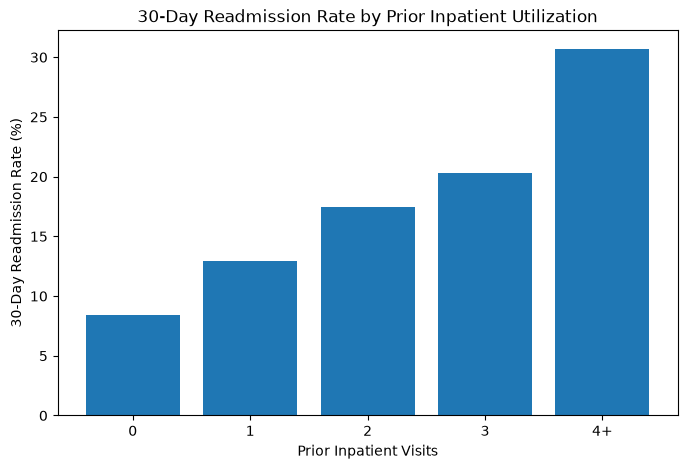

In [49]:
plt.figure(figsize=(8, 5))
plt.bar(
    inpatient_analysis["inpatient_utilization_group"].astype(str),
    inpatient_analysis["readmission_rate"]
)
plt.xlabel("Prior Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Inpatient Utilization")
plt.show()

## 18. Prior Emergency Utilization and 30-Day Readmission

Prior emergency utilization is evaluated to determine whether the number of emergency visits in the previous year is associated with the observed 30-day readmission rate.

Because emergency utilization is a count variable and may be highly skewed, its distribution will first be examined before analytical groups are created.

In [50]:
df_analysis["number_emergency"].describe()

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

In [51]:
emergency_counts = (
    df_analysis["number_emergency"]
    .value_counts()
    .sort_index()
)
emergency_counts

number_emergency
0     90383
1      7677
2      2042
3       725
4       374
5       192
6        94
7        73
8        50
9        33
10       34
11       23
12       10
13       12
14        3
15        3
16        5
18        5
19        4
20        4
21        2
22        6
24        1
25        2
28        1
29        1
37        1
42        1
46        1
54        1
63        1
64        1
76        1
Name: count, dtype: int64

In [52]:
emergency_percentage = (
    df_analysis["number_emergency"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
emergency_percentage

number_emergency
0     88.814535
1      7.543777
2      2.006564
3      0.712419
4      0.367510
5      0.188668
6      0.092369
7      0.071733
8      0.049132
9      0.032427
10     0.033410
11     0.022601
12     0.009826
13     0.011792
14     0.002948
15     0.002948
16     0.004913
18     0.004913
19     0.003931
20     0.003931
21     0.001965
22     0.005896
24     0.000983
25     0.001965
28     0.000983
29     0.000983
37     0.000983
42     0.000983
46     0.000983
54     0.000983
63     0.000983
64     0.000983
76     0.000983
Name: proportion, dtype: float64

### Grouping Prior Emergency Utilization

The `number_emergency` variable is highly right-skewed, with 88.81% of encounters having no prior emergency visits.

To avoid extremely small analytical categories while retaining meaningful differences in utilization, the variable will be grouped into:

- 0 prior emergency visits
- 1 prior emergency visit
- 2 prior emergency visits
- 3 or more prior emergency visits

The original `number_emergency` variable will be retained, and the grouped variable will be used for categorical analysis.

In [53]:
df_analysis["emergency_utilization_group"] = pd.cut(
    df_analysis["number_emergency"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["0", "1", "2", "3+"]
)
df_analysis["emergency_utilization_group"].value_counts().sort_index()

emergency_utilization_group
0     90383
1      7677
2      2042
3+     1664
Name: count, dtype: int64

In [54]:
pd.crosstab(
    df_analysis["number_emergency"],
    df_analysis["emergency_utilization_group"]
)

emergency_utilization_group,0,1,2,3+
number_emergency,,,,
0,90383,0,0,0
1,0,7677,0,0
2,0,0,2042,0
3,0,0,0,725
4,0,0,0,374
5,0,0,0,192
6,0,0,0,94
7,0,0,0,73
8,0,0,0,50


### Prior Emergency Utilization and 30-Day Readmission

The grouped prior emergency utilization variable will be compared with the 30-day readmission indicator.

For each utilization group, the analysis will calculate:

- Total encounters
- Number of 30-day readmissions
- 30-day readmission rate

This will allow comparison of observed readmission rates across different levels of prior emergency utilization.

In [55]:
emergency_analysis = (
    df_analysis
    .groupby("emergency_utilization_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
emergency_analysis["readmission_rate"] = (
    emergency_analysis["readmissions_30d"]
    / emergency_analysis["total_encounters"]
    * 100
)
emergency_analysis

,emergency_utilization_group,total_encounters,readmissions_30d,readmission_rate
0,0,90383,9467,10.474315
1,1,7677,1102,14.354566
2,2,2042,373,18.266405
3,3+,1664,415,24.939904


In [56]:
emergency_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,emergency_utilization_group,total_encounters,readmissions_30d,readmission_rate
3,3+,1664,415,24.939904
2,2,2042,373,18.266405
1,1,7677,1102,14.354566
0,0,90383,9467,10.474315


### Emergency Utilization Findings

A clear increasing pattern was observed between prior emergency utilization and 30-day readmission rate.

Encounters with no prior emergency visits had a 30-day readmission rate of 10.47%. The rate increased to 14.35% for patients with one prior emergency visit and 18.27% for patients with two prior emergency visits.

The 3+ prior emergency visit group had the highest observed 30-day readmission rate at 24.94%.

Compared with the 0-visit group, the 3+ group had a difference of approximately 14.47 percentage points in observed readmission rate.

This represents an unadjusted association. The analysis does not establish that prior emergency utilization causes 30-day readmission, because underlying disease burden, comorbidities, and other patient or clinical characteristics may contribute to the observed relationship.

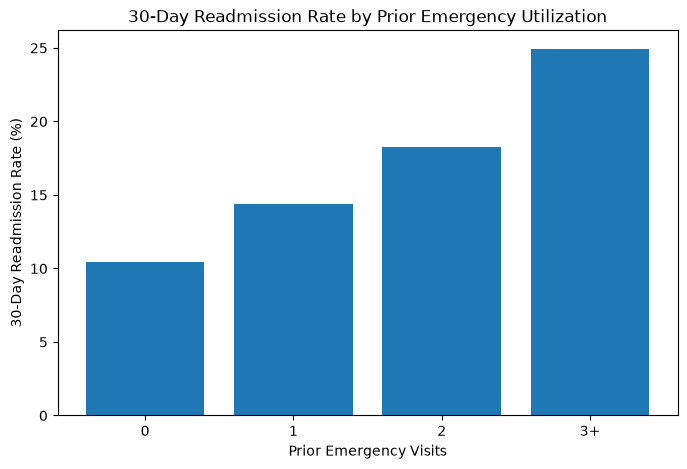

In [57]:
plt.figure(figsize=(8, 5))
plt.bar(
    emergency_analysis["emergency_utilization_group"].astype(str),
    emergency_analysis["readmission_rate"]
)
plt.xlabel("Prior Emergency Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Emergency Utilization")
plt.show()

## 19. Prior Outpatient Utilization and 30-Day Readmission

Prior outpatient utilization is evaluated to determine whether the number of outpatient visits in the previous year is associated with the observed 30-day readmission rate.

Because `number_outpatient` is a count variable and may be right-skewed, its distribution will first be examined before analytical groups are created.

In [58]:
df_analysis["number_outpatient"].describe()

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

In [59]:
outpatient_counts = (
    df_analysis["number_outpatient"]
    .value_counts()
    .sort_index()
)
outpatient_counts

number_outpatient
0     85027
1      8547
2      3594
3      2042
4      1099
5       533
6       303
7       155
8        98
9        83
10       57
11       42
12       30
13       31
14       28
15       20
16       15
17        8
18        5
19        3
20        7
21        7
22        5
23        2
24        3
25        2
26        2
27        3
28        1
29        2
33        2
34        1
35        2
36        2
37        1
38        1
39        1
40        1
42        1
Name: count, dtype: int64

### Grouping Prior Outpatient Utilization

The `number_outpatient` variable is highly right-skewed, with most encounters having zero prior outpatient visits and progressively fewer encounters at higher utilization levels.

To maintain adequate group sizes while preserving meaningful differences in lower utilization levels, the variable will be grouped into:

- 0 prior outpatient visits
- 1 prior outpatient visit
- 2 prior outpatient visits
- 3 prior outpatient visits
- 4 or more prior outpatient visits

The original `number_outpatient` variable will be retained, and the grouped variable will be used for categorical analysis.

In [60]:
df_analysis["outpatient_utilization_group"] = pd.cut(
    df_analysis["number_outpatient"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)
df_analysis["outpatient_utilization_group"].value_counts().sort_index()

outpatient_utilization_group
0     85027
1      8547
2      3594
3      2042
4+     2556
Name: count, dtype: int64

In [61]:
pd.crosstab(
    df_analysis["number_outpatient"],
    df_analysis["outpatient_utilization_group"]
)

outpatient_utilization_group,0,1,2,3,4+
number_outpatient,,,,,
0,85027,0,0,0,0
1,0,8547,0,0,0
2,0,0,3594,0,0
3,0,0,0,2042,0
4,0,0,0,0,1099
5,0,0,0,0,533
6,0,0,0,0,303
7,0,0,0,0,155
8,0,0,0,0,98


### Prior Outpatient Utilization and 30-Day Readmission

The grouped prior outpatient utilization variable will be compared with the 30-day readmission indicator.

For each utilization group, the analysis will calculate:

- Total encounters
- Number of 30-day readmissions
- 30-day readmission rate

This will allow comparison of observed readmission rates across different levels of prior outpatient utilization.

In [62]:
outpatient_analysis = (
    df_analysis
    .groupby("outpatient_utilization_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
outpatient_analysis["readmission_rate"] = (
    outpatient_analysis["readmissions_30d"]
    / outpatient_analysis["total_encounters"]
    * 100
)
outpatient_analysis

,outpatient_utilization_group,total_encounters,readmissions_30d,readmission_rate
0,0,85027,9076,10.674256
1,1,8547,1190,13.923014
2,2,3594,494,13.745131
3,3,2042,251,12.291871
4,4+,2556,346,13.536776


In [63]:
outpatient_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,outpatient_utilization_group,total_encounters,readmissions_30d,readmission_rate
1,1,8547,1190,13.923014
2,2,3594,494,13.745131
4,4+,2556,346,13.536776
3,3,2042,251,12.291871
0,0,85027,9076,10.674256


### Outpatient Utilization Findings

The observed relationship between prior outpatient utilization and 30-day readmission was different from the patterns observed for prior inpatient and emergency utilization.

Encounters with no prior outpatient visits had a 30-day readmission rate of 10.67%. The rate was higher among encounters with one prior outpatient visit (13.92%) and two prior outpatient visits (13.75%).

The rate decreased to 12.29% for three prior outpatient visits and was 13.54% for four or more visits.

Therefore, the relationship does not show a consistent stepwise increase as outpatient utilization increases. Instead, encounters with any prior outpatient utilization generally had higher observed readmission rates than encounters with no prior outpatient visits.

This represents an unadjusted association and does not establish that outpatient utilization causes differences in 30-day readmission.

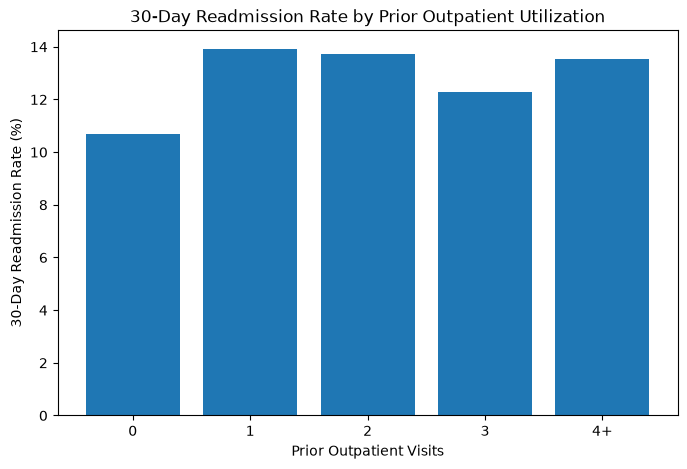

In [64]:
plt.figure(figsize=(8, 5))
plt.bar(
    outpatient_analysis["outpatient_utilization_group"].astype(str),
    outpatient_analysis["readmission_rate"]
)
plt.xlabel("Prior Outpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Outpatient Utilization")
plt.show()

## 20. Length of Hospital Stay and 30-Day Readmission

Length of hospital stay is evaluated to determine whether encounters with different hospitalization durations show different observed 30-day readmission rates.

The `time_in_hospital` variable represents the number of days spent in the current hospital encounter.

The distribution will first be examined before analytical groups are created.

In [65]:
df_analysis["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

In [66]:
los_counts = (
    df_analysis["time_in_hospital"]
    .value_counts()
    .sort_index()
)
los_counts

time_in_hospital
1     14208
2     17224
3     17756
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
Name: count, dtype: int64

### Grouping Length of Hospital Stay

The `time_in_hospital` variable ranges from 1 to 14 days, with a median of 4 days.

To compare 30-day readmission rates across meaningful hospitalization durations while avoiding overly granular categories, length of stay will be grouped into:

- 1–2 days
- 3–4 days
- 5–6 days
- 7–9 days
- 10 or more days

The original `time_in_hospital` variable will be retained, and the grouped variable will be used for categorical analysis.

In [67]:
df_analysis["los_group"] = pd.cut(
    df_analysis["time_in_hospital"],
    bins=[0, 2, 4, 6, 9, float("inf")],
    labels=["1-2", "3-4", "5-6", "7-9", "10+"]
)
df_analysis["los_group"].value_counts().sort_index()

los_group
1-2    31432
3-4    31680
5-6    17505
7-9    13252
10+     7897
Name: count, dtype: int64

In [68]:
pd.crosstab(
    df_analysis["time_in_hospital"],
    df_analysis["los_group"]
)

los_group,1-2,3-4,5-6,7-9,10+
time_in_hospital,,,,,
1,14208,0,0,0,0
2,17224,0,0,0,0
3,0,17756,0,0,0
4,0,13924,0,0,0
5,0,0,9966,0,0
6,0,0,7539,0,0
7,0,0,0,5859,0
8,0,0,0,4391,0
9,0,0,0,3002,0


In [69]:
los_analysis = (
    df_analysis
    .groupby("los_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
los_analysis["readmission_rate"] = (
    los_analysis["readmissions_30d"]
    / los_analysis["total_encounters"]
    * 100
)
los_analysis

,los_group,total_encounters,readmissions_30d,readmission_rate
0,1-2,31432,2874,9.143548
1,3-4,31680,3538,11.167929
2,5-6,17505,2148,12.270780
3,7-9,13252,1789,13.499849
4,10+,7897,1008,12.764341


In [70]:
los_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,los_group,total_encounters,readmissions_30d,readmission_rate
3,7-9,13252,1789,13.499849
4,10+,7897,1008,12.764341
2,5-6,17505,2148,12.270780
1,3-4,31680,3538,11.167929
0,1-2,31432,2874,9.143548


### Length of Stay Findings

The observed 30-day readmission rate generally increased as length of hospital stay increased from 1–2 days through 7–9 days.

Encounters with a 1–2 day stay had a 30-day readmission rate of 9.14%. The rate increased to 11.17% for 3–4 days, 12.27% for 5–6 days, and 13.50% for 7–9 days.

The 10+ day group had a slightly lower observed rate of 12.76%. Therefore, the relationship was generally increasing but was not strictly linear across all length-of-stay categories.

The 7–9 day group had the highest observed 30-day readmission rate at 13.50%.

Compared with the 1–2 day group, the 7–9 day group had a difference of approximately 4.36 percentage points.

These findings represent an unadjusted association and do not establish that longer hospital stays cause higher 30-day readmission rates. Other factors, such as illness severity, comorbidities, procedures, and prior healthcare utilization, may contribute to the observed relationship.

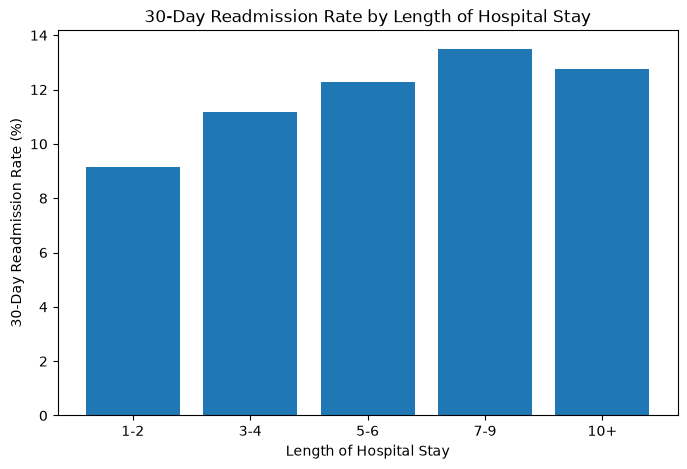

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(
    los_analysis["los_group"].astype(str),
    los_analysis["readmission_rate"]
)
plt.xlabel("Length of Hospital Stay")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Length of Hospital Stay")
plt.show()

## 21. Number of Medications and 30-Day Readmission

The number of medications administered during the hospital encounter is evaluated to determine whether medication burden is associated with the observed 30-day readmission rate.

The distribution of `num_medications` will first be examined before analytical groups are created.

In [72]:
df_analysis["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

In [73]:
medication_counts = (
    df_analysis["num_medications"]
    .value_counts()
    .sort_index()
)
medication_counts

num_medications
1      262
2      470
3      900
4     1417
5     2017
      ... 
72       3
74       1
75       2
79       1
81       1
Name: count, Length: 75, dtype: int64

### Grouping Number of Medications

The `num_medications` variable ranges from 1 to 81 medications and has a right-skewed distribution.

To compare 30-day readmission rates across meaningful medication-burden categories while avoiding very small categories at the upper end, the variable will be grouped into:

- 1–5 medications
- 6–10 medications
- 11–15 medications
- 16–20 medications
- 21–30 medications
- 31 or more medications

The original `num_medications` variable will be retained, and the grouped variable will be used for categorical analysis.

In [74]:
df_analysis["medication_group"] = pd.cut(
    df_analysis["num_medications"],
    bins=[0, 5, 10, 15, 20, 30, float("inf")],
    labels=["1-5", "6-10", "11-15", "16-20", "21-30", "31+"]
)
df_analysis["medication_group"].value_counts().sort_index()

medication_group
1-5       5066
6-10     20795
11-15    29384
16-20    22641
21-30    18643
31+       5237
Name: count, dtype: int64

In [75]:
pd.crosstab(
    df_analysis["num_medications"],
    df_analysis["medication_group"]
)

medication_group,1-5,6-10,11-15,16-20,21-30,31+
num_medications,,,,,,
1,262,0,0,0,0,0
2,470,0,0,0,0,0
3,900,0,0,0,0,0
4,1417,0,0,0,0,0
5,2017,0,0,0,0,0
...,...,...,...,...,...,...
72,0,0,0,0,0,3
74,0,0,0,0,0,1
75,0,0,0,0,0,2


In [76]:
medication_analysis = (
    df_analysis
    .groupby("medication_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
medication_analysis["readmission_rate"] = (
    medication_analysis["readmissions_30d"]
    / medication_analysis["total_encounters"]
    * 100
)
medication_analysis

,medication_group,total_encounters,readmissions_30d,readmission_rate
0,1-5,5066,379,7.481248
1,6-10,20795,1965,9.449387
2,11-15,29384,3206,10.910700
3,16-20,22641,2756,12.172607
4,21-30,18643,2400,12.873465
5,31+,5237,651,12.430781


In [77]:
medication_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,medication_group,total_encounters,readmissions_30d,readmission_rate
4,21-30,18643,2400,12.873465
5,31+,5237,651,12.430781
3,16-20,22641,2756,12.172607
2,11-15,29384,3206,10.910700
1,6-10,20795,1965,9.449387
0,1-5,5066,379,7.481248


### Medication Burden Findings

The observed 30-day readmission rate generally increased as the number of medications administered during the encounter increased from 1–5 through 21–30 medications.

The 1–5 medication group had a 30-day readmission rate of 7.48%. The rate increased to 9.45% for 6–10 medications, 10.91% for 11–15, 12.17% for 16–20, and 12.87% for 21–30 medications.

The 31+ medication group had a slightly lower observed rate of 12.43%. Therefore, the relationship was generally increasing but was not strictly linear across all medication groups.

The difference between the 1–5 and 21–30 medication groups was approximately 5.39 percentage points.

These findings represent an unadjusted association and do not establish that a higher number of medications causes higher 30-day readmission rates. Medication burden may also reflect underlying disease complexity, comorbidities, or illness severity.

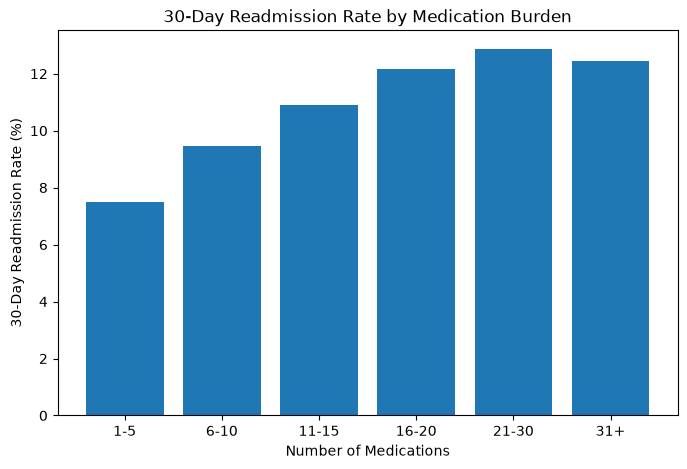

In [78]:
plt.figure(figsize=(8, 5))
plt.bar(
    medication_analysis["medication_group"].astype(str),
    medication_analysis["readmission_rate"]
)
plt.xlabel("Number of Medications")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Medication Burden")
plt.show()

## 22. Number of Diagnoses and 30-Day Readmission

The number of diagnoses recorded during the hospital encounter is evaluated to determine whether clinical complexity, as represented by the number of recorded diagnoses, is associated with the observed 30-day readmission rate.

The distribution of `number_diagnoses` will first be examined before analytical groups are created.

In [79]:
df_analysis["number_diagnoses"].describe()

count    101766.000000
mean          7.422607
std           1.933600
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64

In [80]:
diagnosis_counts = (
    df_analysis["number_diagnoses"]
    .value_counts()
    .sort_index()
)
diagnosis_counts

number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
Name: count, dtype: int64

### Grouping Number of Diagnoses

The `number_diagnoses` variable ranges from 1 to 16 diagnoses, with a median of 8.

The distribution is highly concentrated at 9 diagnoses, which accounts for a large proportion of encounters. In addition, values above 9 are relatively sparse.

To preserve the major distributional pattern while maintaining adequate group sizes, the variable will be grouped into:

- 1–4 diagnoses
- 5–6 diagnoses
- 7–8 diagnoses
- 9 diagnoses
- 10 or more diagnoses

The original `number_diagnoses` variable will be retained, and the grouped variable will be used for categorical analysis.

In [81]:
df_analysis["diagnosis_group"] = pd.cut(
    df_analysis["number_diagnoses"],
    bins=[0, 4, 6, 8, 9, float("inf")],
    labels=["1-4", "5-6", "7-8", "9", "10+"]
)
df_analysis["diagnosis_group"].value_counts().sort_index()

diagnosis_group
1-4     9614
5-6    21554
7-8    21009
9      49474
10+      115
Name: count, dtype: int64

In [82]:
pd.crosstab(
    df_analysis["number_diagnoses"],
    df_analysis["diagnosis_group"]
)

diagnosis_group,1-4,5-6,7-8,9,10+
number_diagnoses,,,,,
1,219,0,0,0,0
2,1023,0,0,0,0
3,2835,0,0,0,0
4,5537,0,0,0,0
5,0,11393,0,0,0
6,0,10161,0,0,0
7,0,0,10393,0,0
8,0,0,10616,0,0
9,0,0,0,49474,0


In [83]:
diagnosis_analysis = (
    df_analysis
    .groupby("diagnosis_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diagnosis_analysis["readmission_rate"] = (
    diagnosis_analysis["readmissions_30d"]
    / diagnosis_analysis["total_encounters"]
    * 100
)
diagnosis_analysis

,diagnosis_group,total_encounters,readmissions_30d,readmission_rate
0,1-4,9614,741,7.707510
1,5-6,21554,2101,9.747611
2,7-8,21009,2373,11.295159
3,9,49474,6125,12.380240
4,10+,115,17,14.782609


In [84]:
diagnosis_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,diagnosis_group,total_encounters,readmissions_30d,readmission_rate
4,10+,115,17,14.782609
3,9,49474,6125,12.380240
2,7-8,21009,2373,11.295159
1,5-6,21554,2101,9.747611
0,1-4,9614,741,7.707510


### Number of Diagnoses Findings

A consistent increasing pattern was observed between the number of diagnoses recorded during the encounter and the observed 30-day readmission rate.

The 1–4 diagnosis group had a 30-day readmission rate of 7.71%. The rate increased to 9.75% for 5–6 diagnoses, 11.30% for 7–8 diagnoses, and 12.38% for encounters with exactly 9 diagnoses.

The 10+ diagnosis group had the highest observed rate at 14.78%. However, this group contained only 115 encounters and 17 readmissions, so its rate should be interpreted cautiously.

The difference between the 1–4 diagnosis group and the 9-diagnosis group was approximately 4.67 percentage points.

These findings represent an unadjusted association and do not establish that having more diagnoses causes higher 30-day readmission rates. A greater number of recorded diagnoses may reflect underlying clinical complexity, comorbidities, or illness severity.

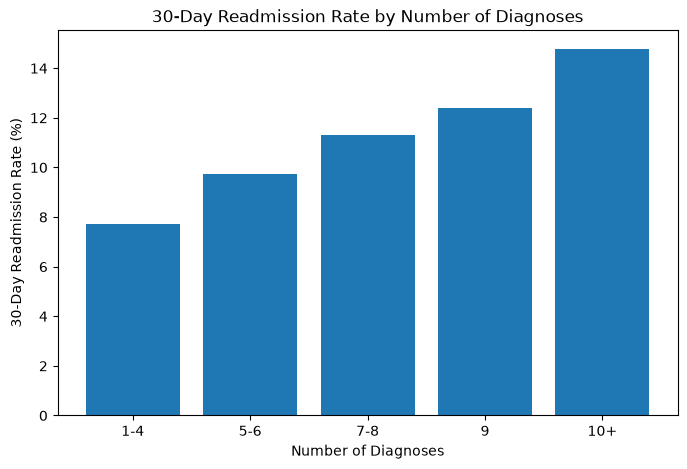

In [85]:
plt.figure(figsize=(8, 5))
plt.bar(
    diagnosis_analysis["diagnosis_group"].astype(str),
    diagnosis_analysis["readmission_rate"]
)
plt.xlabel("Number of Diagnoses")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Diagnoses")
plt.show()

## 23. Number of Lab Procedures and 30-Day Readmission

The number of laboratory procedures performed during the hospital encounter is evaluated to determine whether the intensity of laboratory testing is associated with the observed 30-day readmission rate.

The distribution of `num_lab_procedures` will first be examined before analytical groups are created.

In [86]:
lab_procedure_stats = df_analysis["num_lab_procedures"].describe()
lab_procedure_stats

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

In [87]:
df_analysis["num_lab_procedures"].value_counts().sort_index()

num_lab_procedures
1      3208
2      1101
3       668
4       378
5       286
       ... 
120       1
121       1
126       1
129       1
132       1
Name: count, Length: 118, dtype: int64

### Grouping Number of Lab Procedures

The `num_lab_procedures` variable ranges from 1 to 132 procedures, with a median of 44.

To make the analysis easier to interpret while maintaining reasonably sized groups, the variable will be grouped into:

- 1–30 laboratory procedures
- 31–44 laboratory procedures
- 45–57 laboratory procedures
- 58+ laboratory procedures

These groups approximately reflect the lower quartile, middle ranges, and upper quartile of the distribution.

In [88]:
df_analysis["lab_procedure_group"] = pd.cut(
    df_analysis["num_lab_procedures"],
    bins=[0, 30, 44, 57, float("inf")],
    labels=["1–30", "31–44", "45–57", "58+"]
)

In [89]:
df_analysis["lab_procedure_group"].value_counts().sort_index()

lab_procedure_group
1–30     24201
31–44    27614
45–57    25594
58+      24357
Name: count, dtype: int64

In [90]:
lab_analysis = (
    df_analysis
    .groupby("lab_procedure_group", observed=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
lab_analysis["readmission_rate"] = (
    lab_analysis["readmissions_30d"]
    / lab_analysis["total_encounters"]
    * 100
)
lab_analysis

,lab_procedure_group,total_encounters,readmissions_30d,readmission_rate
0,1–30,24201,2445,10.102888
1,31–44,27614,3088,11.182733
2,45–57,25594,2925,11.428460
3,58+,24357,2899,11.902123


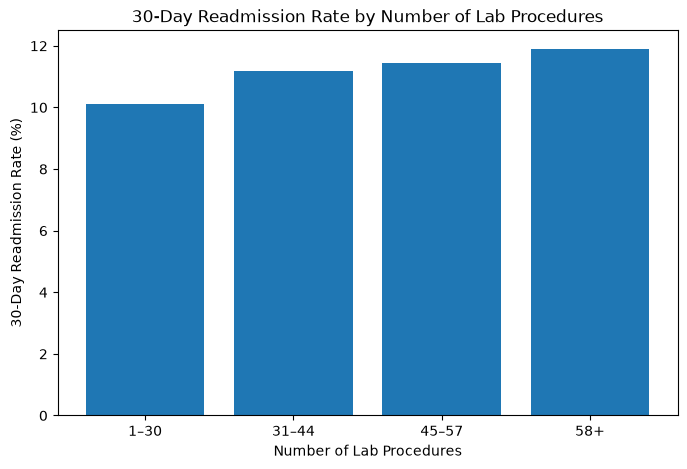

In [91]:
plt.figure(figsize=(8, 5))
plt.bar(
    lab_analysis["lab_procedure_group"].astype(str),
    lab_analysis["readmission_rate"]
)
plt.xlabel("Number of Lab Procedures")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Lab Procedures")
plt.show()

### Number of Lab Procedures Findings

The observed 30-day readmission rate gradually increased as the number of laboratory procedures performed during the encounter increased.

The 1–30 laboratory procedure group had a 30-day readmission rate of 10.10%. The rate increased to 11.18% for 31–44 procedures, 11.43% for 45–57 procedures, and 11.90% for 58 or more procedures.

The difference between the lowest and highest groups was approximately 1.80 percentage points.

Compared with several other variables analyzed in this project, the observed difference was relatively modest. Nevertheless, the pattern suggests a positive unadjusted association between laboratory procedure volume and 30-day readmission.

These findings do not establish that a higher number of laboratory procedures causes readmission. Greater laboratory testing may reflect underlying illness severity, clinical complexity, or other patient characteristics that are also associated with readmission.

## 24. Number of Procedures and 30-Day Readmission

The number of procedures performed during the hospital encounter is evaluated to determine whether procedural intensity is associated with the observed 30-day readmission rate.

The distribution of `num_procedures` will first be examined before analytical groups are created.

In [92]:
procedure_stats = df_analysis["num_procedures"].describe()
procedure_stats

count    101766.000000
mean          1.339730
std           1.705807
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64

In [93]:
df_analysis["num_procedures"].value_counts().sort_index()

num_procedures
0    46652
1    20742
2    12717
3     9443
4     4180
5     3078
6     4954
Name: count, dtype: int64

In [94]:
procedure_analysis = (
    df_analysis
    .groupby("num_procedures")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
procedure_analysis["readmission_rate"] = (
    procedure_analysis["readmissions_30d"]
    / procedure_analysis["total_encounters"]
    * 100
)
procedure_analysis

,num_procedures,total_encounters,readmissions_30d,readmission_rate
0,0,46652,5168,11.077767
1,1,20742,2532,12.207116
2,2,12717,1422,11.181883
3,3,9443,1009,10.685164
4,4,4180,461,11.028708
5,5,3078,290,9.421702
6,6,4954,475,9.588212


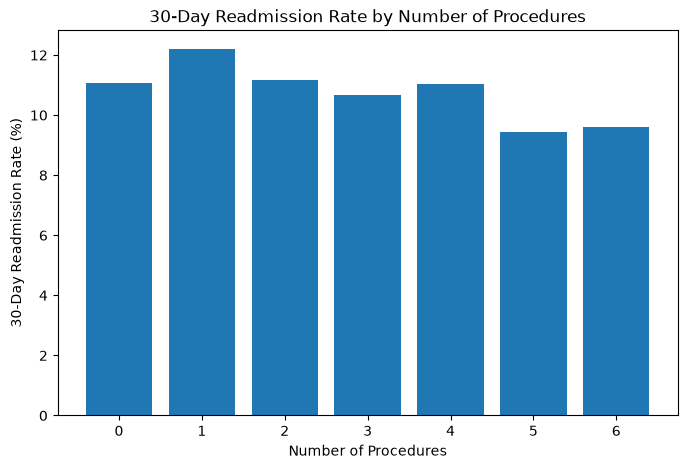

In [95]:
plt.figure(figsize=(8, 5))
plt.bar(
    procedure_analysis["num_procedures"].astype(str),
    procedure_analysis["readmission_rate"]
)
plt.xlabel("Number of Procedures")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Procedures")
plt.show()

### Number of Procedures Findings

The observed 30-day readmission rate did not show a consistent increasing or decreasing pattern across the number of procedures performed during the hospital encounter.

The 0-procedure group had a readmission rate of 11.08%. The rate was highest among encounters with 1 procedure at 12.21%, then decreased to 11.18% for 2 procedures and 10.69% for 3 procedures.

The rate was 11.03% for 4 procedures, 9.42% for 5 procedures, and 9.59% for 6 procedures.

The highest observed rate was therefore 12.21% for encounters with 1 procedure, while the lowest was 9.42% for encounters with 5 procedures.

Overall, the results do not indicate a clear monotonic relationship between the number of procedures and 30-day readmission in this dataset.

These findings represent unadjusted associations and do not establish that the number of procedures causes differences in readmission risk. Procedure volume may be influenced by patient characteristics, clinical condition, diagnosis, and other factors.

## 25. Admission Type and 30-Day Readmission

Admission type is evaluated to determine whether the observed 30-day readmission rate differs across different admission pathways.

The dataset stores admission type as coded values in `admission_type_id`. The code distribution will first be examined before calculating readmission rates.

In [96]:
admission_type_counts = (
    df_analysis["admission_type_id"]
    .value_counts()
    .sort_index()
)
admission_type_counts

admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

In [97]:
sorted(df_analysis["admission_type_id"].dropna().unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8)]

### Mapping Admission Type Codes

The `admission_type_id` variable contains coded admission categories.

To make the analysis interpretable, the documented codes will be mapped to descriptive labels while retaining the original numeric variable.

The original `admission_type_id` column will not be modified.

In [98]:
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL / Not Mapped",
    7: "Trauma Center",
    8: "Not Mapped"
}
df_analysis["admission_type"] = (
    df_analysis["admission_type_id"]
    .map(admission_type_map)
)

In [99]:
pd.crosstab(
    df_analysis["admission_type_id"],
    df_analysis["admission_type"]
)

admission_type,Elective,Emergency,NULL / Not Mapped,Newborn,Not Available,Not Mapped,Trauma Center,Urgent
admission_type_id,,,,,,,,
1,0,53990,0,0,0,0,0,0
2,0,0,0,0,0,0,0,18480
3,18869,0,0,0,0,0,0,0
4,0,0,0,10,0,0,0,0
5,0,0,0,0,4785,0,0,0
6,0,0,5291,0,0,0,0,0
7,0,0,0,0,0,0,21,0
8,0,0,0,0,0,320,0,0


In [100]:
admission_analysis = (
    df_analysis
    .groupby("admission_type")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
admission_analysis["readmission_rate"] = (
    admission_analysis["readmissions_30d"]
    / admission_analysis["total_encounters"]
    * 100
)
admission_analysis

,admission_type,total_encounters,readmissions_30d,readmission_rate
0,Elective,18869,1961,10.392708
1,Emergency,53990,6221,11.522504
2,NULL / Not Mapped,5291,586,11.075411
3,Newborn,10,1,10.000000
4,Not Available,4785,495,10.344828
5,Not Mapped,320,27,8.437500
6,Trauma Center,21,0,0.000000
7,Urgent,18480,2066,11.179654


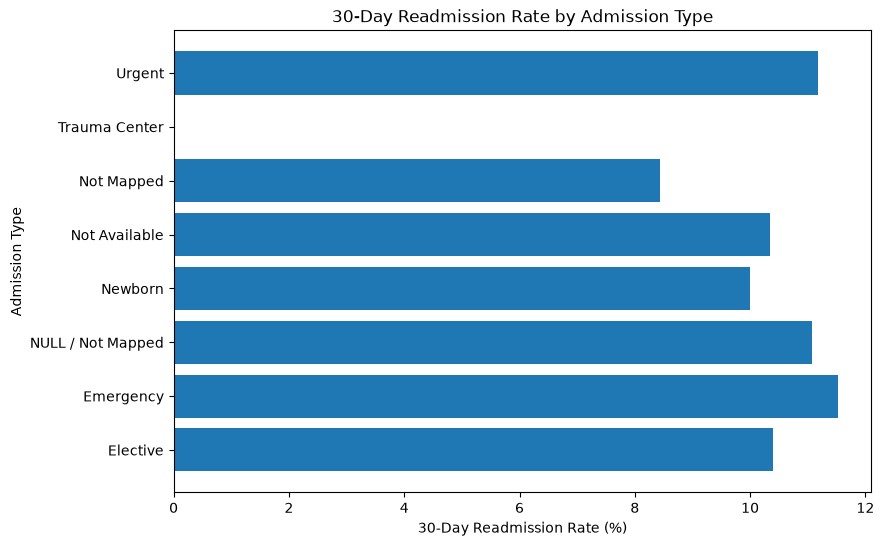

In [101]:
plt.figure(figsize=(9, 6))
plt.barh(
    admission_analysis["admission_type"].astype(str),
    admission_analysis["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Admission Type")
plt.title("30-Day Readmission Rate by Admission Type")
plt.show()

### Admission Type Findings

The observed 30-day readmission rate varied modestly across the major admission categories.

Emergency admissions had a 30-day readmission rate of 11.52%, followed by urgent admissions at 11.18% and elective admissions at 10.39%.

The difference between emergency and elective admissions was approximately 1.13 percentage points.

Several coded categories had very small numbers of encounters. Newborn had 10 encounters, while Trauma Center had 21 encounters. Their observed rates should therefore not be used for substantive comparison.

Overall, admission type showed a relatively modest unadjusted difference in 30-day readmission rates among the major categories.

These findings represent unadjusted associations and do not establish that admission type causes differences in readmission risk. Admission type may also reflect differences in patient condition, clinical urgency, and other characteristics.

## 26. Admission Source and 30-Day Readmission

Admission source describes the pathway through which a patient entered the hospital.

The dataset stores admission source as coded values in `admission_source_id`. The code distribution will first be examined before mapping the codes to descriptive categories and calculating 30-day readmission rates.

In [102]:
admission_source_counts = (
    df_analysis["admission_source_id"]
    .value_counts()
    .sort_index()
)
admission_source_counts

admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64

In [103]:
sorted(df_analysis["admission_source_id"].dropna().unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(13),
 np.int64(14),
 np.int64(17),
 np.int64(20),
 np.int64(22),
 np.int64(25)]

### Mapping Admission Source Codes

The `admission_source_id` variable contains coded admission-source categories.

To make the analysis interpretable, the documented codes will be mapped to descriptive labels while retaining the original numeric variable.

The original `admission_source_id` column will not be modified.

In [104]:
admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from Hospital",
    5: "Transfer from Skilled Nursing Facility",
    6: "Transfer from Other Healthcare Facility",
    7: "Emergency Room",
    8: "Court / Law Enforcement",
    9: "Not Available",
    10: "Transfer from Critical Access Hospital",
    11: "Normal Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    17: "NULL / Not Mapped",
    20: "Not Mapped",
    22: "Transfer from Hospital Inpatient / Other",
    25: "Not Available"
}
df_analysis["admission_source"] = (
    df_analysis["admission_source_id"]
    .map(admission_source_map)
)

In [105]:
pd.crosstab(
    df_analysis["admission_source_id"],
    df_analysis["admission_source"]
)

admission_source,Clinic Referral,Court / Law Enforcement,Emergency Room,Extramural Birth,HMO Referral,NULL / Not Mapped,Normal Delivery,Not Available,Not Mapped,Physician Referral,Sick Baby,Transfer from Critical Access Hospital,Transfer from Hospital,Transfer from Hospital Inpatient / Other,Transfer from Other Healthcare Facility,Transfer from Skilled Nursing Facility
admission_source_id,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,29565,0,0,0,0,0,0
2,1104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,187,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3187,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,855
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2264,0
7,0,0,57494,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,125,0,0,0,0,0,0,0,0


In [106]:
admission_source_analysis = (
    df_analysis
    .groupby("admission_source")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
admission_source_analysis["readmission_rate"] = (
    admission_source_analysis["readmissions_30d"]
    / admission_source_analysis["total_encounters"]
    * 100
)
admission_source_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,admission_source,total_encounters,readmissions_30d,readmission_rate
13,Transfer from Hospital Inpatient / Other,12,2,16.666667
4,HMO Referral,187,29,15.508021
8,Not Mapped,161,22,13.664596
1,Court / Law Enforcement,16,2,12.500000
15,Transfer from Skilled Nursing Facility,855,101,11.812865
2,Emergency Room,57494,6720,11.688176
9,Physician Referral,29565,3130,10.586843
5,NULL / Not Mapped,6781,706,10.411444
7,Not Available,127,13,10.236220
0,Clinic Referral,1104,111,10.054348


### Admission Source Visualization

Because several admission-source categories contain very few encounters, their observed readmission rates may be unstable.

For visualization, admission sources with at least 500 encounters will be included. The complete results remain available in `admission_source_analysis`.

A minimum denominator is used here to improve interpretability and avoid emphasizing rates based on extremely small groups.

In [107]:
admission_source_viz = (
    admission_source_analysis[
        admission_source_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
admission_source_viz

,admission_source,total_encounters,readmissions_30d,readmission_rate
15,Transfer from Skilled Nursing Facility,855,101,11.812865
2,Emergency Room,57494,6720,11.688176
9,Physician Referral,29565,3130,10.586843
5,NULL / Not Mapped,6781,706,10.411444
0,Clinic Referral,1104,111,10.054348
12,Transfer from Hospital,3187,309,9.695639
14,Transfer from Other Healthcare Facility,2264,212,9.363958


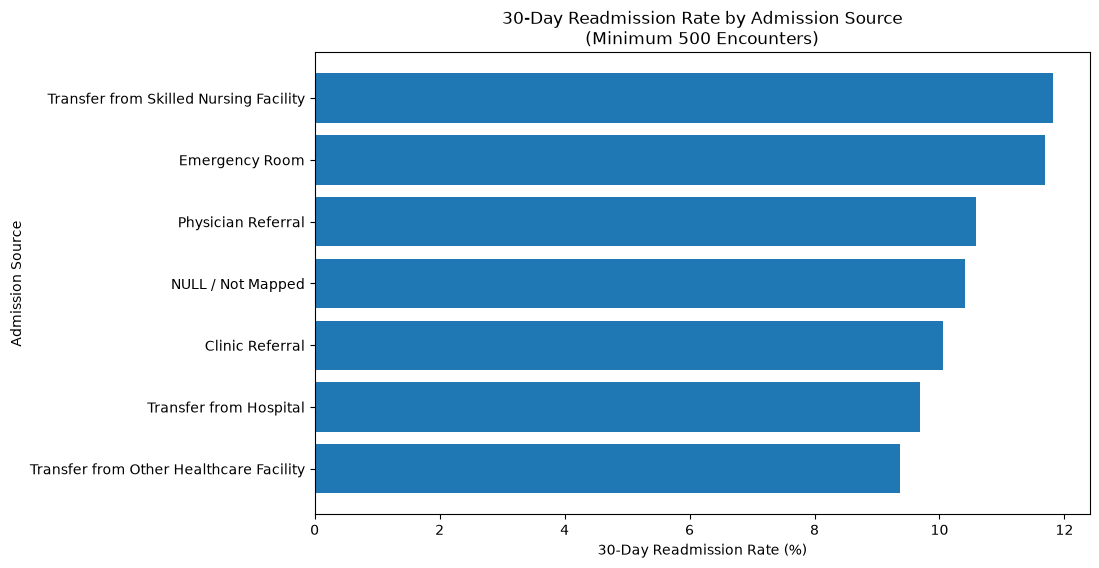

In [108]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(
    admission_source_viz["admission_source"],
    admission_source_viz["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Admission Source")
plt.title("30-Day Readmission Rate by Admission Source\n(Minimum 500 Encounters)")
plt.gca().invert_yaxis()
plt.show()

### Admission Source Findings

Among admission-source categories with at least 500 encounters, the observed 30-day readmission rates ranged from 9.36% to 11.81%.

Transfer from a Skilled Nursing Facility had a rate of 11.81%, while Emergency Room admissions had a rate of 11.69%.

Physician Referral had a rate of 10.59%, followed by NULL / Not Mapped at 10.41% and Clinic Referral at 10.05%.

Transfer from Hospital had a rate of 9.70%, while Transfer from Other Healthcare Facility had the lowest observed rate among the selected groups at 9.36%.

The differences between these larger admission-source groups were relatively modest compared with some of the differences observed in prior-utilization variables such as number of previous inpatient visits.

Several admission-source categories were excluded from the visualization because they contained fewer than 500 encounters. Their results remain in the complete `admission_source_analysis` table but should be interpreted cautiously because of their small denominators.

These findings represent unadjusted associations and do not establish that admission source causes differences in 30-day readmission risk.

## 27. Discharge Disposition and 30-Day Readmission

Discharge disposition describes the patient's status or destination at the time of discharge from the hospital.

The dataset stores discharge disposition as coded values in `discharge_disposition_id`. The code distribution will first be examined before mapping the codes to descriptive categories and calculating 30-day readmission rates.

In [109]:
discharge_disposition_counts = (
    df_analysis["discharge_disposition_id"]
    .value_counts()
    .sort_index()
)
discharge_disposition_counts

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

In [110]:
sorted(df_analysis["discharge_disposition_id"].dropna().unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(27),
 np.int64(28)]

### Mapping Discharge Disposition Codes

The `discharge_disposition_id` variable contains coded categories describing the patient's disposition at discharge.

To make the analysis interpretable, the documented codes will be mapped to descriptive labels while retaining the original numeric variable.

The original `discharge_disposition_id` column will not be modified.

In [111]:
discharge_disposition_map = {
    1: "Discharged to Home",
    2: "Transferred to Short-Term Hospital",
    3: "Transferred to Skilled Nursing Facility",
    4: "Transferred to Intermediate Care Facility",
    5: "Transferred to Other Inpatient Care Institution",
    6: "Discharged to Home with Home Health",
    7: "Left Against Medical Advice",
    8: "Discharged to Home with Home IV",
    9: "Admitted as Inpatient to This Hospital",
    10: "Neonate Discharged for Neonatal Aftercare",
    11: "Expired",
    12: "Still Patient / Expected to Return",
    13: "Hospice / Home",
    14: "Hospice / Medical Facility",
    15: "Transferred to Medicare-Approved Swing Bed",
    16: "Transferred for Outpatient Services",
    17: "Referred to This Institution for Outpatient Services",
    18: "NULL",
    19: "Expired at Home / Hospice",
    20: "Expired in Medical Facility / Hospice",
    21: "Expired / Place Unknown",
    22: "Transferred to Rehabilitation Facility",
    23: "Transferred to Long-Term Care Hospital",
    24: "Transferred to Medicaid-Certified Nursing Facility",
    25: "Not Mapped",
    26: "Unknown / Invalid",
    27: "Transferred to Federal Healthcare Facility",
    28: "Transferred to Psychiatric Hospital / Unit",
    29: "Transferred to Critical Access Hospital",
    30: "Other Healthcare Institution"
}
df_analysis["discharge_disposition"] = (
    df_analysis["discharge_disposition_id"]
    .map(discharge_disposition_map)
)

In [112]:
pd.crosstab(
    df_analysis["discharge_disposition_id"],
    df_analysis["discharge_disposition"]
)

discharge_disposition,Admitted as Inpatient to This Hospital,Discharged to Home,Discharged to Home with Home Health,Discharged to Home with Home IV,Expired,Expired at Home / Hospice,Expired in Medical Facility / Hospice,Hospice / Home,Hospice / Medical Facility,Left Against Medical Advice,...,Transferred to Federal Healthcare Facility,Transferred to Intermediate Care Facility,Transferred to Long-Term Care Hospital,Transferred to Medicaid-Certified Nursing Facility,Transferred to Medicare-Approved Swing Bed,Transferred to Other Inpatient Care Institution,Transferred to Psychiatric Hospital / Unit,Transferred to Rehabilitation Facility,Transferred to Short-Term Hospital,Transferred to Skilled Nursing Facility
discharge_disposition_id,,,,,,,,,,,,,,,,,,,,,
1,0,60234,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2128,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,13954
4,0,0,0,0,0,0,0,0,0,0,...,0,815,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1184,0,0,0,0
6,0,0,12902,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,623,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,108,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [113]:
discharge_disposition_analysis = (
    df_analysis
    .groupby("discharge_disposition")["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
discharge_disposition_analysis["readmission_rate"] = (
    discharge_disposition_analysis["readmissions_30d"]
    / discharge_disposition_analysis["total_encounters"]
    * 100
)
discharge_disposition_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,discharge_disposition,total_encounters,readmissions_30d,readmission_rate
14,Still Patient / Expected to Return,3,2,66.666667
20,Transferred to Medicare-Approved Swing Bed,63,28,44.444444
0,Admitted as Inpatient to This Hospital,21,9,42.857143
22,Transferred to Psychiatric Hospital / Unit,139,51,36.690647
23,Transferred to Rehabilitation Facility,1993,552,27.696939
21,Transferred to Other Inpatient Care Institution,1184,247,20.861486
24,Transferred to Short-Term Hospital,2128,342,16.071429
25,Transferred to Skilled Nursing Facility,13954,2046,14.662462
19,Transferred to Medicaid-Certified Nursing Faci...,48,7,14.583333
9,Left Against Medical Advice,623,90,14.446228


In [114]:
discharge_disposition_viz = (
    discharge_disposition_analysis[
        discharge_disposition_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
discharge_disposition_viz

,discharge_disposition,total_encounters,readmissions_30d,readmission_rate
23,Transferred to Rehabilitation Facility,1993,552,27.696939
21,Transferred to Other Inpatient Care Institution,1184,247,20.861486
24,Transferred to Short-Term Hospital,2128,342,16.071429
25,Transferred to Skilled Nursing Facility,13954,2046,14.662462
9,Left Against Medical Advice,623,90,14.446228
17,Transferred to Intermediate Care Facility,815,104,12.760736
2,Discharged to Home with Home Health,12902,1638,12.695706
10,NULL,3691,459,12.435654
12,Not Mapped,989,92,9.302326
1,Discharged to Home,60234,5602,9.300395


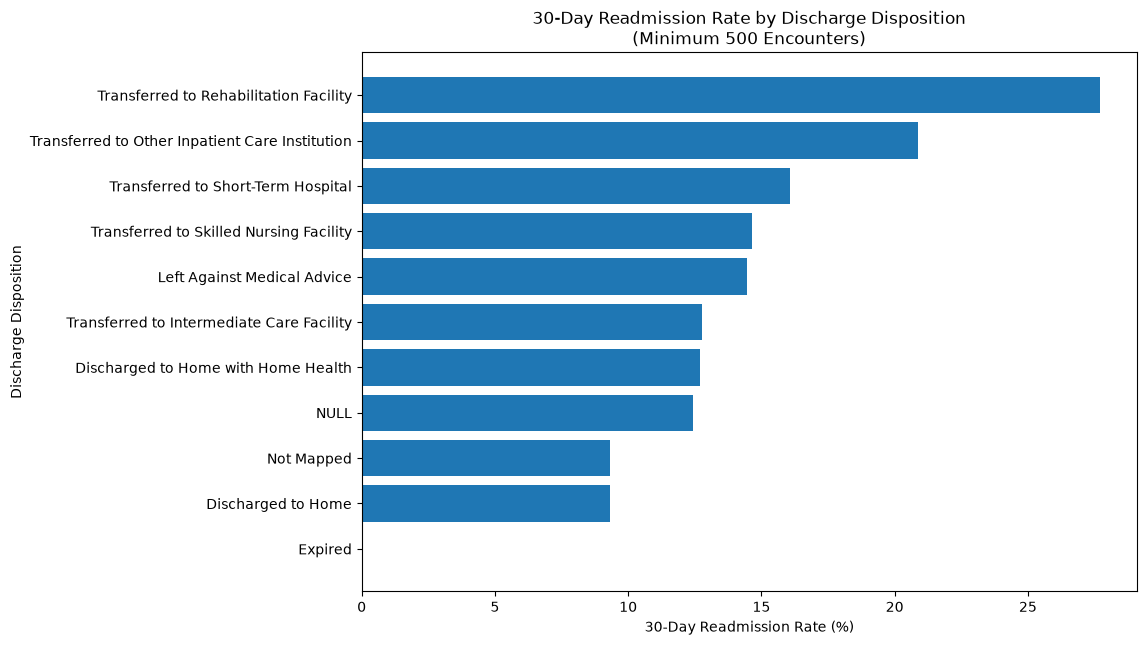

In [115]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.barh(
    discharge_disposition_viz["discharge_disposition"],
    discharge_disposition_viz["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Discharge Disposition")
plt.title(
    "30-Day Readmission Rate by Discharge Disposition\n"
    "(Minimum 500 Encounters)"
)
plt.gca().invert_yaxis()
plt.show()

## Findings

The analysis shows substantial variation in 30-day readmission rates across discharge disposition categories among groups with at least 500 encounters.

- Transfers to a rehabilitation facility had a 30-day readmission rate of 27.70% (1,993 encounters).
- Transfers to other inpatient care institutions had a rate of 20.86% (1,184 encounters).
- Transfers to short-term hospitals had a rate of 16.07% (2,128 encounters).
- Transfers to skilled nursing facilities had a rate of 14.66% (13,954 encounters).
- Discharges to home with home health had a rate of 12.70% (12,902 encounters).
- Discharges directly to home had a rate of 9.30% (60,234 encounters).

The results indicate an unadjusted association between discharge disposition and 30-day readmission in this dataset. Discharge destinations involving continued or higher levels of healthcare support show different readmission patterns than routine discharge to home.

However, these results should not be interpreted as evidence that discharge disposition itself causes readmission. Discharge destination may reflect differences in illness severity, patient characteristics, prior healthcare utilization, diagnoses, and other clinical factors.

The `Expired` category is not directly comparable with other discharge destinations because patients recorded as expired cannot subsequently experience a readmission in the dataset. Similarly, `NULL` and `Not Mapped` categories represent data-quality or coding limitations rather than meaningful clinical discharge destinations.

Small discharge categories were retained in the full analytical table but excluded from the visualization because their small sample sizes can produce unstable readmission rates.

## 28. Prior Inpatient Utilization and 30-Day Readmission

`number_inpatient` represents the number of inpatient visits recorded for the patient during the year preceding the current encounter.

The analysis will group patients by prior inpatient utilization and compare 30-day readmission rates across these groups.

The purpose is to determine whether previous inpatient utilization is associated with subsequent 30-day readmission.

In [116]:
df_analysis["prior_inpatient_group"] = pd.cut(
    df_analysis["number_inpatient"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)
df_analysis["prior_inpatient_group"].value_counts().sort_index()

prior_inpatient_group
0     67630
1     19521
2      7566
3      3411
4+     3638
Name: count, dtype: int64

In [117]:
prior_inpatient_analysis = (
    df_analysis
    .groupby("prior_inpatient_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
prior_inpatient_analysis["readmission_rate"] = (
    prior_inpatient_analysis["readmissions_30d"]
    / prior_inpatient_analysis["total_encounters"]
    * 100
)
prior_inpatient_analysis

,prior_inpatient_group,total_encounters,readmissions_30d,readmission_rate
0,0,67630,5706,8.437084
1,1,19521,2523,12.924543
2,2,7566,1319,17.433254
3,3,3411,692,20.287306
4,4+,3638,1117,30.703683


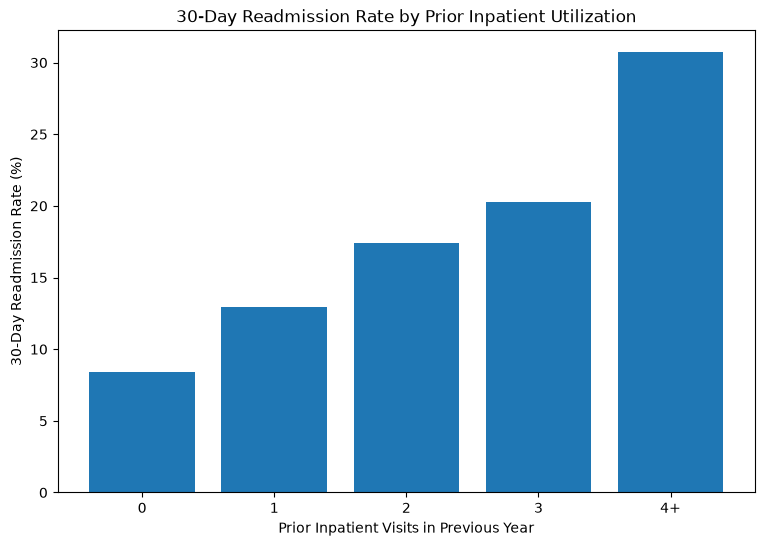

In [118]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.bar(
    prior_inpatient_analysis["prior_inpatient_group"].astype(str),
    prior_inpatient_analysis["readmission_rate"]
)
plt.xlabel("Prior Inpatient Visits in Previous Year")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Inpatient Utilization")
plt.show()

## Findings

The analysis shows a clear increasing association between prior inpatient utilization and 30-day readmission.

- Patients with 0 prior inpatient visits had a 30-day readmission rate of 8.44%.
- Patients with 1 prior inpatient visit had a rate of 12.92%.
- Patients with 2 prior inpatient visits had a rate of 17.43%.
- Patients with 3 prior inpatient visits had a rate of 20.29%.
- Patients with 4 or more prior inpatient visits had the highest observed rate at 30.70%.

The difference between patients with 0 prior inpatient visits and those with 4 or more was approximately 22.27 percentage points. The observed rate in the 4+ group was approximately 3.64 times the rate in the 0-visit group.

This pattern suggests that prior inpatient utilization is an important variable for further analysis of 30-day readmission risk.

However, this is an unadjusted association and should not be interpreted as evidence that prior inpatient utilization directly causes readmission. Previous inpatient utilization may also reflect underlying illness severity, comorbidities, healthcare utilization patterns, or other patient-level factors.

The 4+ group contained 3,638 encounters, so the observed rate is based on a substantial number of encounters rather than a very small subgroup.

In [119]:
df_analysis["prior_emergency_group"] = pd.cut(
    df_analysis["number_emergency"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["0", "1", "2", "3+"]
)
df_analysis["prior_emergency_group"].value_counts().sort_index()

prior_emergency_group
0     90383
1      7677
2      2042
3+     1664
Name: count, dtype: int64

In [120]:
prior_emergency_analysis = (
    df_analysis
    .groupby("prior_emergency_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
prior_emergency_analysis["readmission_rate"] = (
    prior_emergency_analysis["readmissions_30d"]
    / prior_emergency_analysis["total_encounters"]
    * 100
)
prior_emergency_analysis

,prior_emergency_group,total_encounters,readmissions_30d,readmission_rate
0,0,90383,9467,10.474315
1,1,7677,1102,14.354566
2,2,2042,373,18.266405
3,3+,1664,415,24.939904


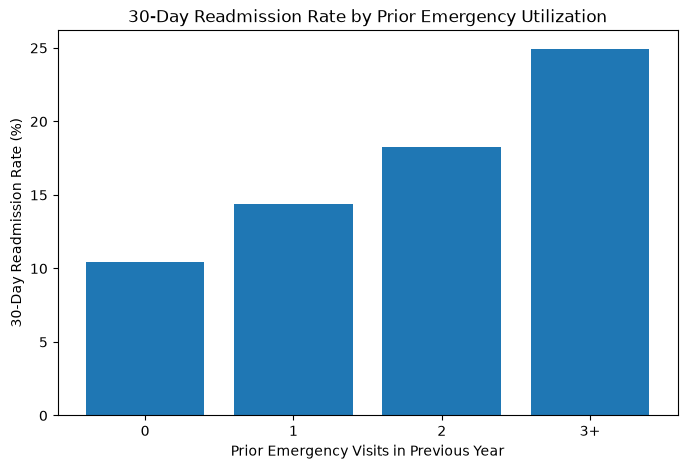

In [121]:
plt.figure(figsize=(8, 5))
plt.bar(
    prior_emergency_analysis["prior_emergency_group"].astype(str),
    prior_emergency_analysis["readmission_rate"]
)
plt.xlabel("Prior Emergency Visits in Previous Year")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Emergency Utilization")
plt.show()

## Findings

The analysis shows a clear increasing association between prior emergency department utilization and 30-day readmission.

- Patients with 0 prior emergency visits had a 30-day readmission rate of 10.47%.
- Patients with 1 prior emergency visit had a rate of 14.35%.
- Patients with 2 prior emergency visits had a rate of 18.27%.
- Patients with 3 or more prior emergency visits had the highest observed rate at 24.94%.

The difference between patients with 0 prior emergency visits and those with 3 or more was approximately 14.47 percentage points. The observed rate in the 3+ group was approximately 2.38 times the rate in the 0-visit group.

The results indicate a clear unadjusted association between prior emergency department utilization and subsequent 30-day readmission.

This finding should not be interpreted as evidence that prior emergency visits directly cause readmission. Prior emergency utilization may reflect underlying illness severity, chronic disease burden, healthcare access, or other patient-level factors.

The 3+ group contained 1,664 encounters, providing a substantial number of observations for this descriptive analysis.

In [122]:
df_analysis["prior_outpatient_group"] = pd.cut(
    df_analysis["number_outpatient"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)
df_analysis["prior_outpatient_group"].value_counts().sort_index()

prior_outpatient_group
0     85027
1      8547
2      3594
3      2042
4+     2556
Name: count, dtype: int64

In [123]:
prior_outpatient_analysis = (
    df_analysis
    .groupby("prior_outpatient_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
prior_outpatient_analysis["readmission_rate"] = (
    prior_outpatient_analysis["readmissions_30d"]
    / prior_outpatient_analysis["total_encounters"]
    * 100
)
prior_outpatient_analysis

,prior_outpatient_group,total_encounters,readmissions_30d,readmission_rate
0,0,85027,9076,10.674256
1,1,8547,1190,13.923014
2,2,3594,494,13.745131
3,3,2042,251,12.291871
4,4+,2556,346,13.536776


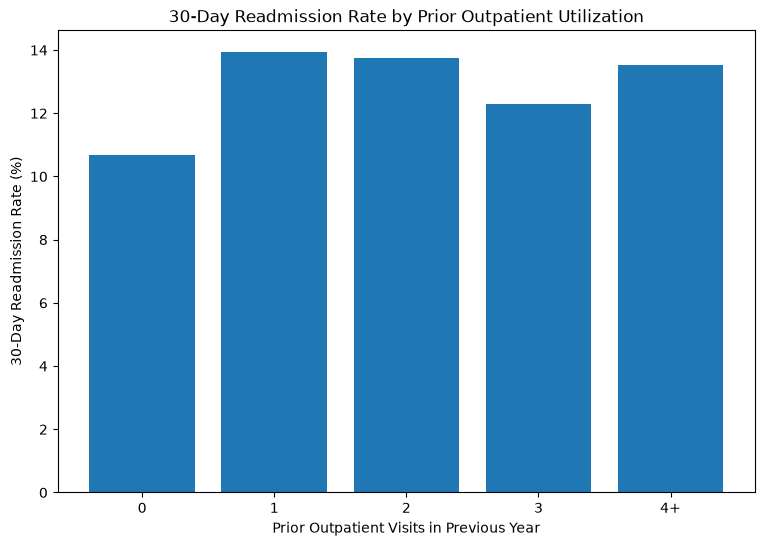

In [124]:
plt.figure(figsize=(9, 6))
plt.bar(
    prior_outpatient_analysis["prior_outpatient_group"].astype(str),
    prior_outpatient_analysis["readmission_rate"]
)
plt.xlabel("Prior Outpatient Visits in Previous Year")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Prior Outpatient Utilization")
plt.show()

## Findings

The analysis shows that prior outpatient utilization is associated with a higher 30-day readmission rate compared with having no prior outpatient visits, but the relationship is not consistently increasing.

- Patients with 0 prior outpatient visits had a 30-day readmission rate of 10.67%.
- Patients with 1 prior outpatient visit had the highest observed rate at 13.92%.
- Patients with 2 prior outpatient visits had a similar rate of 13.75%.
- Patients with 3 prior outpatient visits had a lower rate of 12.29%.
- Patients with 4 or more prior outpatient visits had a rate of 13.54%.

The difference between the 0-visit group and the 1-visit group was approximately 3.25 percentage points.

Unlike prior inpatient and emergency utilization, there is no clear dose-response pattern in which the readmission rate continuously increases as utilization increases.

These results indicate an unadjusted association between prior outpatient utilization and 30-day readmission, but the relationship is less pronounced and less consistent than the patterns observed for prior inpatient and emergency utilization.

The findings should not be interpreted as evidence that outpatient utilization causes or prevents readmission. Other patient and clinical factors may influence both outpatient utilization and subsequent readmission.

In [125]:
df_analysis["length_of_stay_group"] = pd.cut(
    df_analysis["time_in_hospital"],
    bins=[0, 2, 4, 6, 9, float("inf")],
    labels=["1-2", "3-4", "5-6", "7-9", "10+"]
)
df_analysis["length_of_stay_group"].value_counts().sort_index()

length_of_stay_group
1-2    31432
3-4    31680
5-6    17505
7-9    13252
10+     7897
Name: count, dtype: int64

In [126]:
length_of_stay_analysis = (
    df_analysis
    .groupby("length_of_stay_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
length_of_stay_analysis["readmission_rate"] = (
    length_of_stay_analysis["readmissions_30d"]
    / length_of_stay_analysis["total_encounters"]
    * 100
)
length_of_stay_analysis

,length_of_stay_group,total_encounters,readmissions_30d,readmission_rate
0,1-2,31432,2874,9.143548
1,3-4,31680,3538,11.167929
2,5-6,17505,2148,12.270780
3,7-9,13252,1789,13.499849
4,10+,7897,1008,12.764341


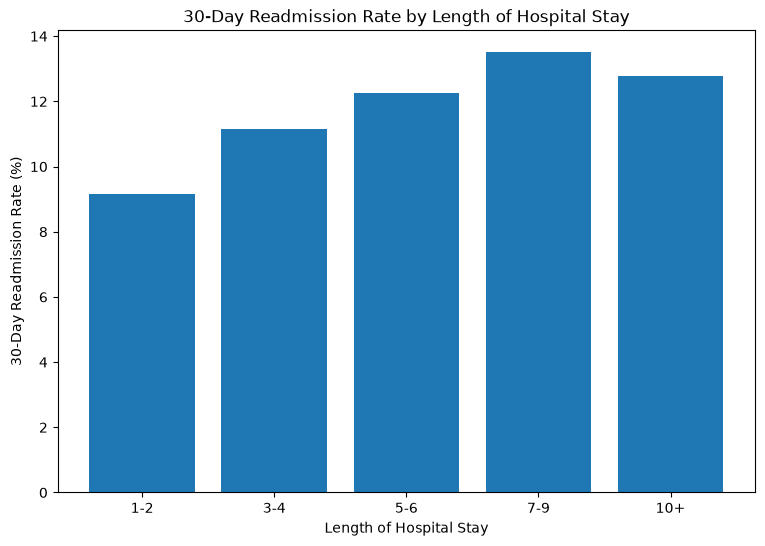

In [127]:
plt.figure(figsize=(9, 6))
plt.bar(
    length_of_stay_analysis["length_of_stay_group"].astype(str),
    length_of_stay_analysis["readmission_rate"]
)
plt.xlabel("Length of Hospital Stay")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Length of Hospital Stay")
plt.show()

## Findings

The analysis shows that 30-day readmission rates generally increase with length of hospital stay through the 7–9 day group, followed by a modest decline in the 10+ day group.

- Patients with a 1–2 day stay had a 30-day readmission rate of 9.14%.
- Patients with a 3–4 day stay had a rate of 11.17%.
- Patients with a 5–6 day stay had a rate of 12.27%.
- Patients with a 7–9 day stay had the highest observed rate at 13.50%.
- Patients with a 10+ day stay had a slightly lower rate of 12.76%.

The difference between the 1–2 day group and the 7–9 day group was approximately 4.36 percentage points.

The results indicate an unadjusted association between length of hospital stay and 30-day readmission. However, the relationship is not strictly linear because the rate decreases slightly in the 10+ day group.

Length of stay may reflect differences in clinical complexity, illness severity, treatment requirements, or other patient and encounter characteristics. Therefore, these results should not be interpreted as evidence that a longer hospital stay directly causes readmission.

In [128]:
df_analysis["medication_group"] = pd.cut(
    df_analysis["num_medications"],
    bins=[0, 5, 10, 15, 20, 30, float("inf")],
    labels=["1-5", "6-10", "11-15", "16-20", "21-30", "31+"]
)
df_analysis["medication_group"].value_counts().sort_index()

medication_group
1-5       5066
6-10     20795
11-15    29384
16-20    22641
21-30    18643
31+       5237
Name: count, dtype: int64

In [129]:
medication_analysis = (
    df_analysis
    .groupby("medication_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
medication_analysis["readmission_rate"] = (
    medication_analysis["readmissions_30d"]
    / medication_analysis["total_encounters"]
    * 100
)
medication_analysis

,medication_group,total_encounters,readmissions_30d,readmission_rate
0,1-5,5066,379,7.481248
1,6-10,20795,1965,9.449387
2,11-15,29384,3206,10.910700
3,16-20,22641,2756,12.172607
4,21-30,18643,2400,12.873465
5,31+,5237,651,12.430781


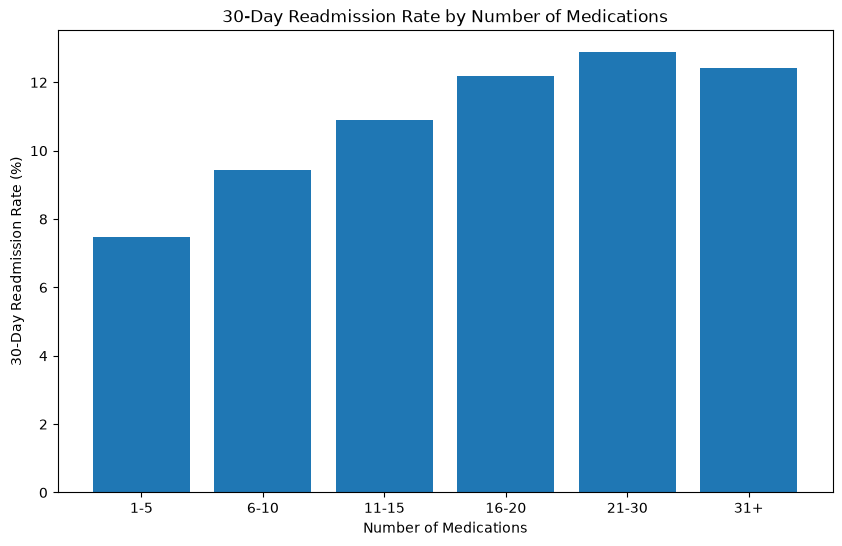

In [130]:
plt.figure(figsize=(10, 6))
plt.bar(
    medication_analysis["medication_group"].astype(str),
    medication_analysis["readmission_rate"]
)
plt.xlabel("Number of Medications")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Medications")
plt.show()

## Findings

The analysis shows a generally increasing association between the number of medications recorded during the current hospital encounter and 30-day readmission.

- Patients with 1–5 medications had a 30-day readmission rate of 7.48%.
- Patients with 6–10 medications had a rate of 9.45%.
- Patients with 11–15 medications had a rate of 10.91%.
- Patients with 16–20 medications had a rate of 12.17%.
- Patients with 21–30 medications had the highest observed rate at 12.87%.
- Patients with 31+ medications had a slightly lower rate of 12.43%.

The difference between the 1–5 medication group and the 21–30 medication group was approximately 5.39 percentage points.

The relationship is not strictly linear because the readmission rate decreases slightly in the 31+ medication group.

The results indicate an unadjusted association between medication count and 30-day readmission. Higher medication counts may reflect greater clinical complexity, comorbidity, or treatment requirements. Therefore, the analysis should not be interpreted as evidence that a higher number of medications directly causes hospital readmission.

In [131]:
df_analysis["diagnosis_group"] = pd.cut(
    df_analysis["number_diagnoses"],
    bins=[0, 4, 6, 8, 9, float("inf")],
    labels=["1-4", "5-6", "7-8", "9", "10+"]
)
df_analysis["diagnosis_group"].value_counts().sort_index()

diagnosis_group
1-4     9614
5-6    21554
7-8    21009
9      49474
10+      115
Name: count, dtype: int64

In [132]:
diagnosis_analysis = (
    df_analysis
    .groupby("diagnosis_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diagnosis_analysis["readmission_rate"] = (
    diagnosis_analysis["readmissions_30d"]
    / diagnosis_analysis["total_encounters"]
    * 100
)
diagnosis_analysis

,diagnosis_group,total_encounters,readmissions_30d,readmission_rate
0,1-4,9614,741,7.707510
1,5-6,21554,2101,9.747611
2,7-8,21009,2373,11.295159
3,9,49474,6125,12.380240
4,10+,115,17,14.782609


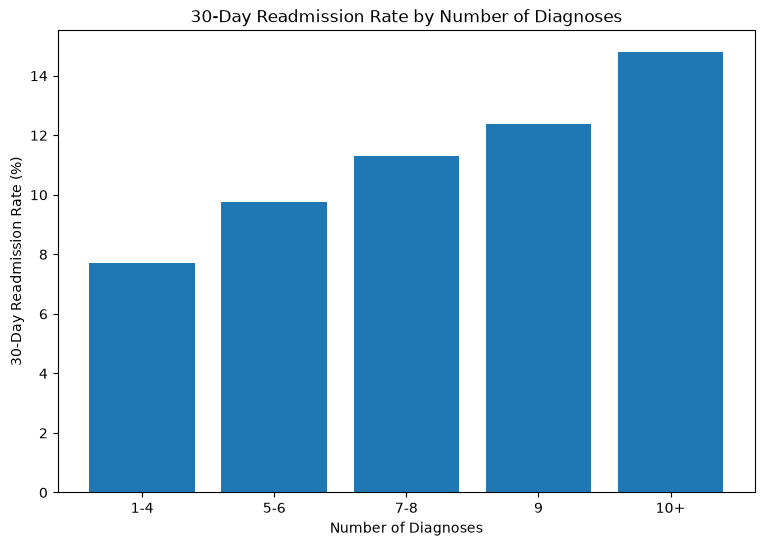

In [133]:
plt.figure(figsize=(9, 6))
plt.bar(
    diagnosis_analysis["diagnosis_group"].astype(str),
    diagnosis_analysis["readmission_rate"]
)
plt.xlabel("Number of Diagnoses")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Diagnoses")
plt.show()

## Findings

The analysis shows a consistent increasing association between the number of diagnoses recorded during the hospital encounter and 30-day readmission.

- Patients with 1–4 diagnoses had a 30-day readmission rate of 7.71%.
- Patients with 5–6 diagnoses had a rate of 9.75%.
- Patients with 7–8 diagnoses had a rate of 11.30%.
- Patients with 9 diagnoses had a rate of 12.38%.
- Patients with 10+ diagnoses had the highest observed rate at 14.78%.

The difference between the 1–4 diagnosis group and the 9-diagnosis group was approximately 4.67 percentage points.

The 10+ diagnosis group had a higher observed rate, but it contained only 115 encounters. Therefore, this small group should be interpreted cautiously.

Overall, the results indicate an unadjusted association between the number of diagnoses and 30-day readmission. A higher number of recorded diagnoses may reflect greater clinical complexity or comorbidity. However, these results do not establish that having more diagnoses directly causes hospital readmission.

In [134]:
df_analysis["lab_procedure_group"] = pd.cut(
    df_analysis["num_lab_procedures"],
    bins=[0, 30, 44, 57, float("inf")],
    labels=["1-30", "31-44", "45-57", "58+"]
)
df_analysis["lab_procedure_group"].value_counts().sort_index()

lab_procedure_group
1-30     24201
31-44    27614
45-57    25594
58+      24357
Name: count, dtype: int64

In [135]:
lab_procedure_analysis = (
    df_analysis
    .groupby("lab_procedure_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
lab_procedure_analysis["readmission_rate"] = (
    lab_procedure_analysis["readmissions_30d"]
    / lab_procedure_analysis["total_encounters"]
    * 100
)
lab_procedure_analysis

,lab_procedure_group,total_encounters,readmissions_30d,readmission_rate
0,1-30,24201,2445,10.102888
1,31-44,27614,3088,11.182733
2,45-57,25594,2925,11.428460
3,58+,24357,2899,11.902123


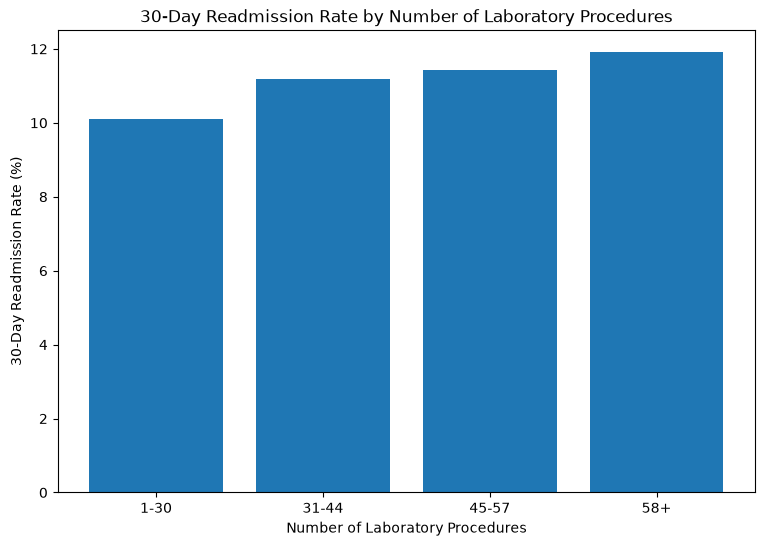

In [136]:
plt.figure(figsize=(9, 6))
plt.bar(
    lab_procedure_analysis["lab_procedure_group"].astype(str),
    lab_procedure_analysis["readmission_rate"]
)
plt.xlabel("Number of Laboratory Procedures")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Laboratory Procedures")
plt.show()

## Findings

The analysis shows a gradual increase in 30-day readmission rates as the number of laboratory procedures increases.

- Patients with 1–30 laboratory procedures had a 30-day readmission rate of 10.10%.
- Patients with 31–44 procedures had a rate of 11.18%.
- Patients with 45–57 procedures had a rate of 11.43%.
- Patients with 58+ procedures had the highest observed rate at 11.90%.

The difference between the 1–30 and 58+ groups was approximately 1.80 percentage points.

Compared with some other utilization and clinical-complexity measures, the observed difference across laboratory-procedure groups is relatively modest.

The results indicate an unadjusted association between the number of laboratory procedures and 30-day readmission. A higher number of procedures may reflect differences in clinical complexity, illness severity, or treatment requirements. Therefore, these results should not be interpreted as evidence that laboratory procedures directly cause hospital readmission.

In [137]:
df_analysis["num_procedures"].value_counts().sort_index()

num_procedures
0    46652
1    20742
2    12717
3     9443
4     4180
5     3078
6     4954
Name: count, dtype: int64

In [138]:
procedure_analysis = (
    df_analysis
    .groupby("num_procedures", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
procedure_analysis["readmission_rate"] = (
    procedure_analysis["readmissions_30d"]
    / procedure_analysis["total_encounters"]
    * 100
)
procedure_analysis

,num_procedures,total_encounters,readmissions_30d,readmission_rate
0,0,46652,5168,11.077767
1,1,20742,2532,12.207116
2,2,12717,1422,11.181883
3,3,9443,1009,10.685164
4,4,4180,461,11.028708
5,5,3078,290,9.421702
6,6,4954,475,9.588212


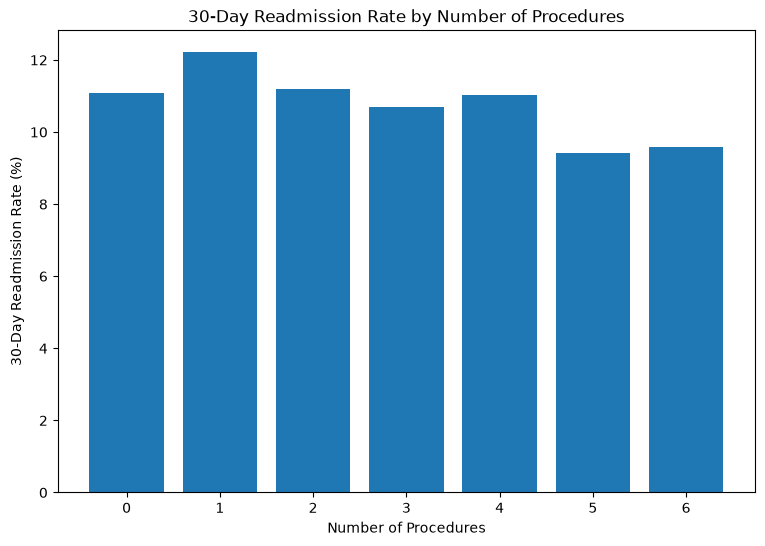

In [139]:
plt.figure(figsize=(9, 6))
plt.bar(
    procedure_analysis["num_procedures"].astype(str),
    procedure_analysis["readmission_rate"]
)
plt.xlabel("Number of Procedures")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Procedures")
plt.show()

### Findings

- The number of procedures does not show a clear monotonic relationship with 30-day readmission.
- The highest observed readmission rate was among encounters with **1 procedure (12.21%)**.
- The lowest observed rate was among encounters with **5 procedures (9.42%)**.
- Encounters with **0 procedures had an 11.08% readmission rate**, similar to several procedure groups.
- Overall, the rates fluctuate between approximately **9.42% and 12.21%**, with no consistent increase or decrease as procedure count rises.
- Therefore, procedure count alone does not appear to be a strong unadjusted indicator of 30-day readmission in this dataset.
- These are **unadjusted associations** and should not be interpreted as causal relationships.

In [140]:
df_analysis["race"].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [141]:
race_analysis = (
    df_analysis
    .assign(race=df_analysis["race"].fillna("Missing"))
    .groupby("race", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
race_analysis["readmission_rate"] = (
    race_analysis["readmissions_30d"]
    / race_analysis["total_encounters"]
    * 100
)
race_analysis.sort_values(
    "readmission_rate",
    ascending=False
)

,race,total_encounters,readmissions_30d,readmission_rate
2,Caucasian,76099,8592,11.290556
0,AfricanAmerican,19210,2155,11.218116
3,Hispanic,2037,212,10.407462
1,Asian,641,65,10.140406
5,Other,1506,145,9.628154
4,Missing,2273,188,8.271007


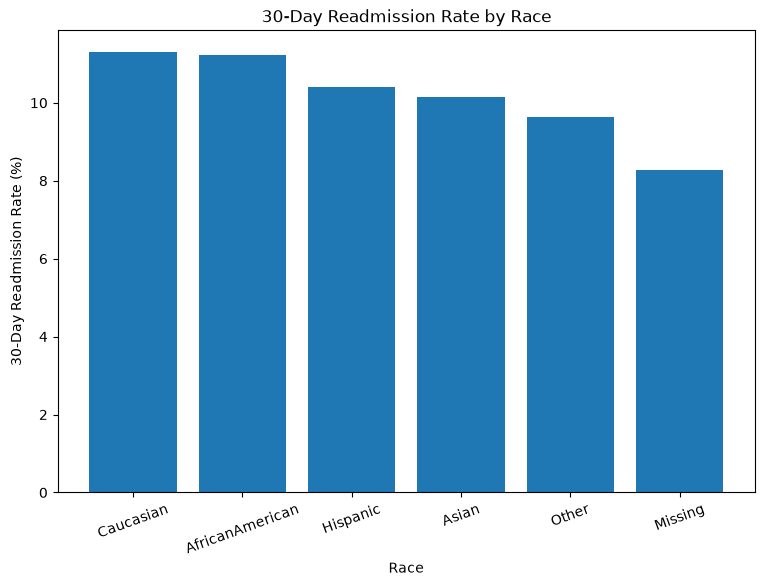

In [142]:
race_chart = race_analysis.sort_values(
    "readmission_rate",
    ascending=False
)
plt.figure(figsize=(9, 6))
plt.bar(
    race_chart["race"],
    race_chart["readmission_rate"]
)
plt.xlabel("Race")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Race")
plt.xticks(rotation=20)
plt.show()

### Findings

- The observed 30-day readmission rates were relatively similar across the two largest race groups: **Caucasian (11.29%)** and **AfricanAmerican (11.22%)**.
- Hispanic encounters had a readmission rate of **10.41%**, while Asian encounters had **10.14%**.
- The Other category had a rate of **9.63%**.
- The Missing category had the lowest observed rate at **8.27%**, but this represents missing race information and should not be interpreted as a demographic group.
- The differences observed across race categories are **unadjusted associations** and should not be interpreted as evidence that race itself causes differences in readmission.
- Differences may reflect other patient, clinical, healthcare-access, or data-related factors that are not accounted for in this descriptive analysis.
- Smaller groups, particularly Asian and Other, should be interpreted cautiously because they contain substantially fewer encounters than the largest groups.

In [143]:
df_analysis["medical_specialty"].value_counts(dropna=False).head(30)

medical_specialty
NaN                                  49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                    207
Neurology                           

In [144]:
specialty_counts = (
    df_analysis["medical_specialty"]
    .dropna()
    .value_counts()
    .reset_index()
)
specialty_counts.columns = [
    "medical_specialty",
    "total_encounters"
]
specialty_counts.head(20)

,medical_specialty,total_encounters
0,InternalMedicine,14635
1,Emergency/Trauma,7565
2,Family/GeneralPractice,7440
3,Cardiology,5352
4,Surgery-General,3099
5,Nephrology,1613
6,Orthopedics,1400
7,Orthopedics-Reconstructive,1233
8,Radiologist,1140
9,Pulmonology,871


In [145]:
specialty_analysis = (
    df_analysis
    .dropna(subset=["medical_specialty"])
    .groupby("medical_specialty", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
specialty_analysis["readmission_rate"] = (
    specialty_analysis["readmissions_30d"]
    / specialty_analysis["total_encounters"]
    * 100
)
specialty_analysis = (
    specialty_analysis[
        specialty_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
specialty_analysis

,medical_specialty,total_encounters,readmissions_30d,readmission_rate
19,Nephrology,1613,248,15.375077
69,Surgery-Vascular,533,74,13.883677
47,Psychiatry,854,104,12.177986
11,Family/GeneralPractice,7440,883,11.868280
18,InternalMedicine,14635,1646,11.247011
8,Emergency/Trauma,7565,846,11.183080
62,Surgery-General,3099,342,11.035818
51,Pulmonology,871,96,11.021814
12,Gastroenterology,564,62,10.992908
27,Orthopedics,1400,151,10.785714


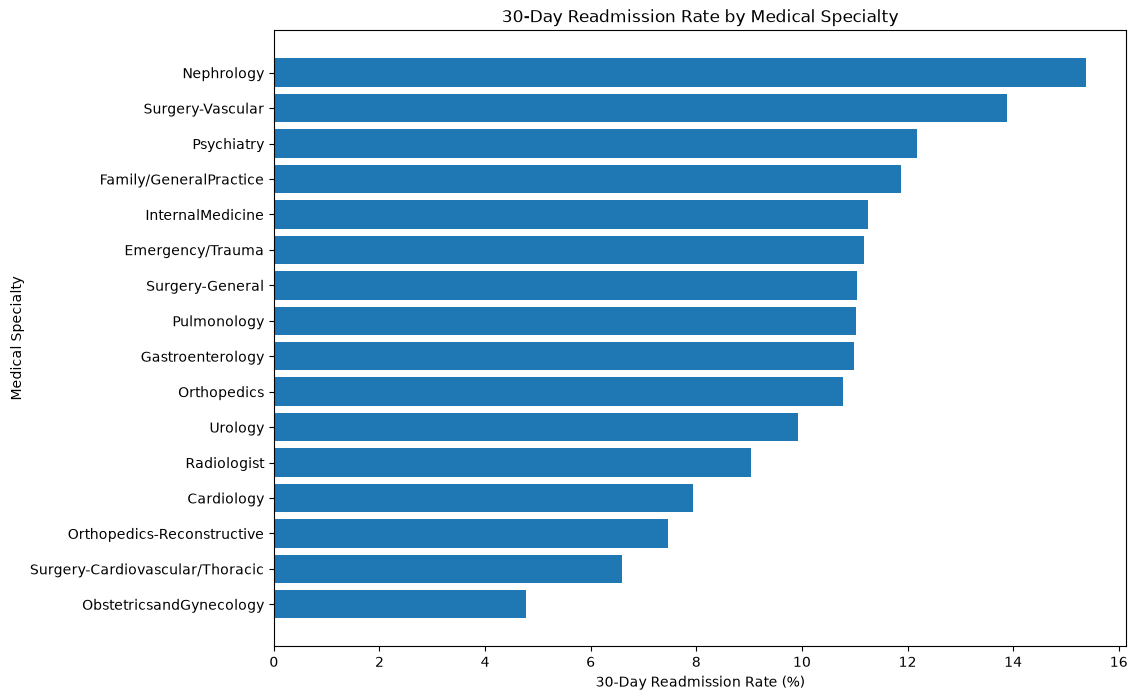

In [146]:
plt.figure(figsize=(11, 8))
plt.barh(
    specialty_analysis["medical_specialty"],
    specialty_analysis["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Medical Specialty")
plt.title("30-Day Readmission Rate by Medical Specialty")
plt.gca().invert_yaxis()
plt.show()

### Findings

- Among medical specialties with at least 500 encounters, observed 30-day readmission rates varied substantially.
- Nephrology had an observed readmission rate of **15.38%**, compared with the overall dataset rate of **11.16%**.
- Family/General Practice, Internal Medicine, Emergency/Trauma, General Surgery, Pulmonology, and Gastroenterology had rates relatively close to the overall dataset rate.
- Several specialties had lower observed rates, including Cardiology (**7.94%**) and Obstetrics and Gynecology (**4.77%**).
- The specialty groups have different encounter volumes, so rates from smaller groups should be interpreted with greater caution.
- Approximately **49% of encounters have missing medical-specialty information**, which limits how completely this variable represents the dataset.
- Medical specialty is an **unadjusted association** with readmission in this analysis and should not be interpreted as a causal factor.
- Differences may reflect variation in patient characteristics, clinical conditions, disease severity, treatment patterns, or other healthcare factors associated with different specialties.

In [147]:
df_analysis["payer_code"].value_counts(dropna=False)

payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64

In [148]:
payer_analysis = (
    df_analysis
    .dropna(subset=["payer_code"])
    .groupby("payer_code", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
payer_analysis["readmission_rate"] = (
    payer_analysis["readmissions_30d"]
    / payer_analysis["total_encounters"]
    * 100
)
payer_analysis = (
    payer_analysis[
        payer_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
payer_analysis

,payer_code,total_encounters,readmissions_30d,readmission_rate
10,OG,1033,136,13.165537
8,MD,3532,416,11.778029
7,MC,32439,3810,11.745122
4,DM,549,64,11.657559
6,HM,6274,644,10.264584
2,CM,1937,198,10.221993
14,SP,5007,510,10.185740
15,UN,2448,227,9.272876
0,BC,4655,426,9.151450
3,CP,2533,214,8.448480


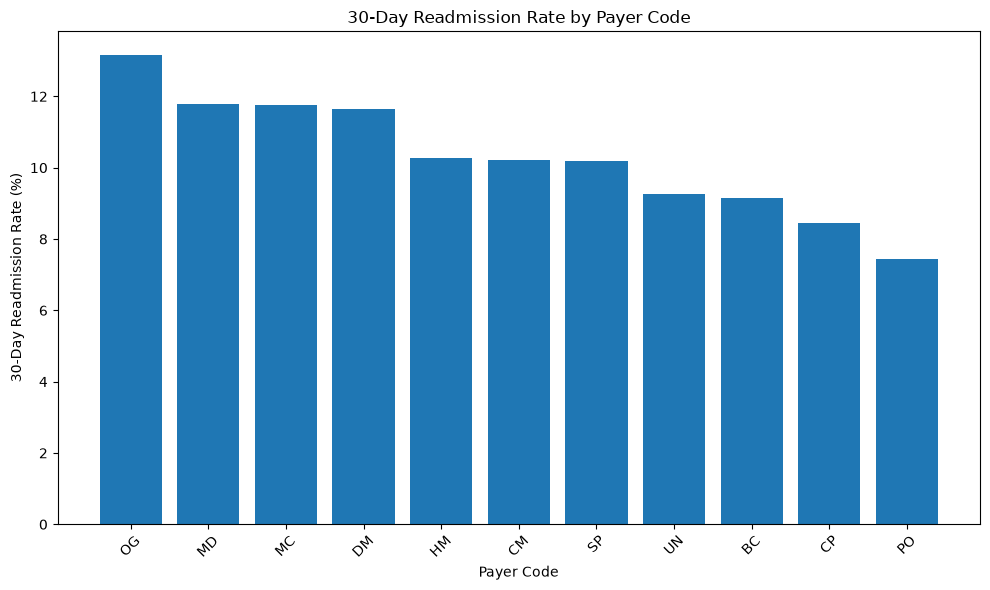

In [149]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    payer_analysis["payer_code"],
    payer_analysis["readmission_rate"]
)
plt.xlabel("Payer Code")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Payer Code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Findings — Payer Code and 30-Day Readmission

- Among payer categories with at least 500 encounters, 30-day readmission rates ranged from 7.43% to 13.17%.
- OG had the highest observed readmission rate at 13.17%, while PO had the lowest at 7.43%.
- MC had the largest number of encounters (32,439) with an observed readmission rate of 11.75%.
- Several payer categories had rates close to the overall dataset readmission rate of 11.16%.
- The variation across payer categories represents an unadjusted association and should not be interpreted as a causal effect of insurance or payer type.
- Differences may reflect patient characteristics, disease severity, healthcare utilization, or other factors.
- Approximately 39.6% of encounters have missing payer information, which limits the completeness of this analysis.
- Payer codes are dataset-specific abbreviations and have not been interpreted as specific insurance programs in this analysis.

In [150]:
medication_analysis = (
    df_analysis
    .groupby("num_medications", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
medication_analysis["readmission_rate"] = (
    medication_analysis["readmissions_30d"]
    / medication_analysis["total_encounters"]
    * 100
)
medication_analysis

,num_medications,total_encounters,readmissions_30d,readmission_rate
0,1,262,11,4.198473
1,2,470,39,8.297872
2,3,900,65,7.222222
3,4,1417,114,8.045166
4,5,2017,150,7.436787
...,...,...,...,...
70,72,3,3,100.000000
71,74,1,0,0.000000
72,75,2,0,0.000000
73,79,1,0,0.000000


In [151]:
df_analysis["medication_group"] = pd.cut(
    df_analysis["num_medications"],
    bins=[0, 5, 10, 15, 20, 30, float("inf")],
    labels=["1–5", "6–10", "11–15", "16–20", "21–30", "31+"],
    include_lowest=True
)
medication_group_analysis = (
    df_analysis
    .groupby("medication_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
medication_group_analysis["readmission_rate"] = (
    medication_group_analysis["readmissions_30d"]
    / medication_group_analysis["total_encounters"]
    * 100
)
medication_group_analysis

,medication_group,total_encounters,readmissions_30d,readmission_rate
0,1–5,5066,379,7.481248
1,6–10,20795,1965,9.449387
2,11–15,29384,3206,10.910700
3,16–20,22641,2756,12.172607
4,21–30,18643,2400,12.873465
5,31+,5237,651,12.430781


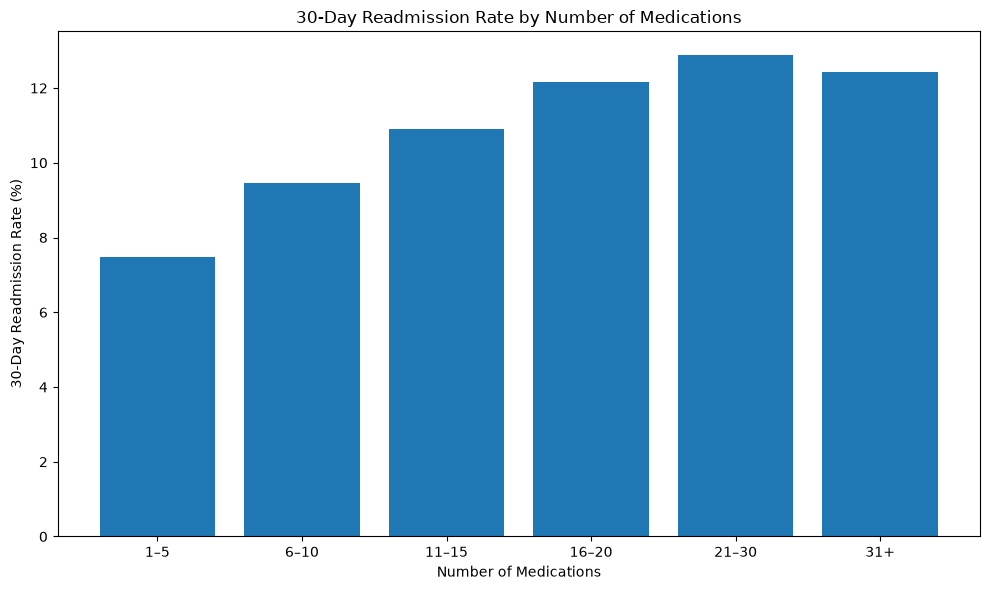

In [152]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    medication_group_analysis["medication_group"].astype(str),
    medication_group_analysis["readmission_rate"]
)
plt.xlabel("Number of Medications")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Medications")
plt.tight_layout()
plt.show()

## Findings — Number of Medications and 30-Day Readmission

- The observed 30-day readmission rate generally increased as the number of medications increased.
- Encounters involving 1–5 medications had a readmission rate of 7.48%.
- The rate increased progressively through the 21–30 medication group, reaching 12.87%.
- The 31+ medication group had a slightly lower rate of 12.43%, indicating that the relationship was not perfectly linear.
- The difference between the 1–5 and 21–30 medication groups was approximately 5.39 percentage points.
- The pattern suggests that medication burden may be associated with higher readmission risk in this dataset.
- This is an unadjusted association and does not establish that a higher number of medications causes readmission.
- Higher medication counts may also reflect greater disease complexity, comorbidities, or overall patient severity.

In [153]:
diagnosis_analysis = (
    df_analysis
    .groupby("number_diagnoses", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diagnosis_analysis["readmission_rate"] = (
    diagnosis_analysis["readmissions_30d"]
    / diagnosis_analysis["total_encounters"]
    * 100
)
diagnosis_analysis

,number_diagnoses,total_encounters,readmissions_30d,readmission_rate
0,1,219,13,5.936073
1,2,1023,62,6.060606
2,3,2835,209,7.372134
3,4,5537,457,8.253567
4,5,11393,1043,9.154744
5,6,10161,1058,10.412361
6,7,10393,1119,10.766862
7,8,10616,1254,11.812359
8,9,49474,6125,12.380240
9,10,17,3,17.647059


In [154]:
df_analysis["diagnosis_group"] = pd.cut(
    df_analysis["number_diagnoses"],
    bins=[0, 4, 6, 8, 9, float("inf")],
    labels=["1–4", "5–6", "7–8", "9", "10+"],
    include_lowest=True
)
diagnosis_group_analysis = (
    df_analysis
    .groupby("diagnosis_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diagnosis_group_analysis["readmission_rate"] = (
    diagnosis_group_analysis["readmissions_30d"]
    / diagnosis_group_analysis["total_encounters"]
    * 100
)
diagnosis_group_analysis

,diagnosis_group,total_encounters,readmissions_30d,readmission_rate
0,1–4,9614,741,7.707510
1,5–6,21554,2101,9.747611
2,7–8,21009,2373,11.295159
3,9,49474,6125,12.380240
4,10+,115,17,14.782609


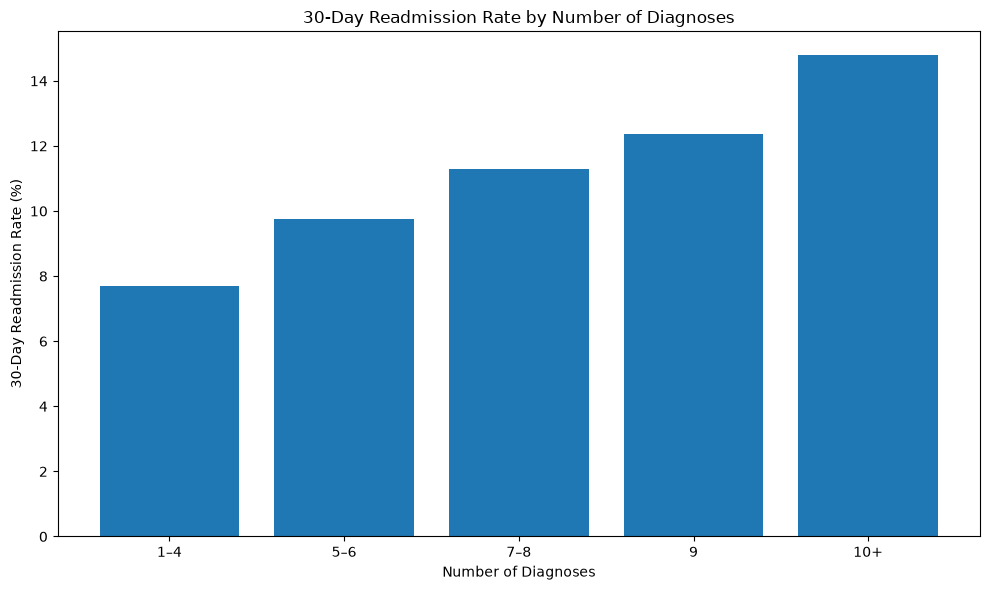

In [155]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    diagnosis_group_analysis["diagnosis_group"].astype(str),
    diagnosis_group_analysis["readmission_rate"]
)
plt.xlabel("Number of Diagnoses")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Diagnoses")
plt.tight_layout()
plt.show()

## Findings — Number of Diagnoses and 30-Day Readmission

- The observed 30-day readmission rate increased consistently across the diagnosis groups.
- Encounters with 1–4 diagnoses had a readmission rate of 7.71%.
- The rate increased to 9.75% for 5–6 diagnoses, 11.30% for 7–8 diagnoses, and 12.38% for encounters with 9 diagnoses.
- The 10+ diagnosis group had the highest observed rate at 14.78%.
- The difference between the 1–4 and 10+ groups was approximately 7.08 percentage points.
- The 10+ group contains only 115 encounters, so its estimate should be interpreted cautiously.
- Overall, a higher number of recorded diagnoses shows a clear unadjusted association with higher 30-day readmission in this dataset.
- This does not establish causation. A higher diagnosis count may reflect greater comorbidity, disease complexity, or patient severity.

In [156]:
lab_analysis = (
    df_analysis
    .groupby("num_lab_procedures", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
lab_analysis["readmission_rate"] = (
    lab_analysis["readmissions_30d"]
    / lab_analysis["total_encounters"]
    * 100
)
lab_analysis

,num_lab_procedures,total_encounters,readmissions_30d,readmission_rate
0,1,3208,302,9.413965
1,2,1101,126,11.444142
2,3,668,63,9.431138
3,4,378,24,6.349206
4,5,286,27,9.440559
...,...,...,...,...
113,120,1,0,0.000000
114,121,1,0,0.000000
115,126,1,0,0.000000
116,129,1,0,0.000000


In [157]:
df_analysis["lab_procedure_group"] = pd.cut(
    df_analysis["num_lab_procedures"],
    bins=[0, 30, 44, 57, float("inf")],
    labels=["1–30", "31–44", "45–57", "58+"],
    include_lowest=True
)
lab_group_analysis = (
    df_analysis
    .groupby("lab_procedure_group", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
lab_group_analysis["readmission_rate"] = (
    lab_group_analysis["readmissions_30d"]
    / lab_group_analysis["total_encounters"]
    * 100
)
lab_group_analysis

,lab_procedure_group,total_encounters,readmissions_30d,readmission_rate
0,1–30,24201,2445,10.102888
1,31–44,27614,3088,11.182733
2,45–57,25594,2925,11.428460
3,58+,24357,2899,11.902123


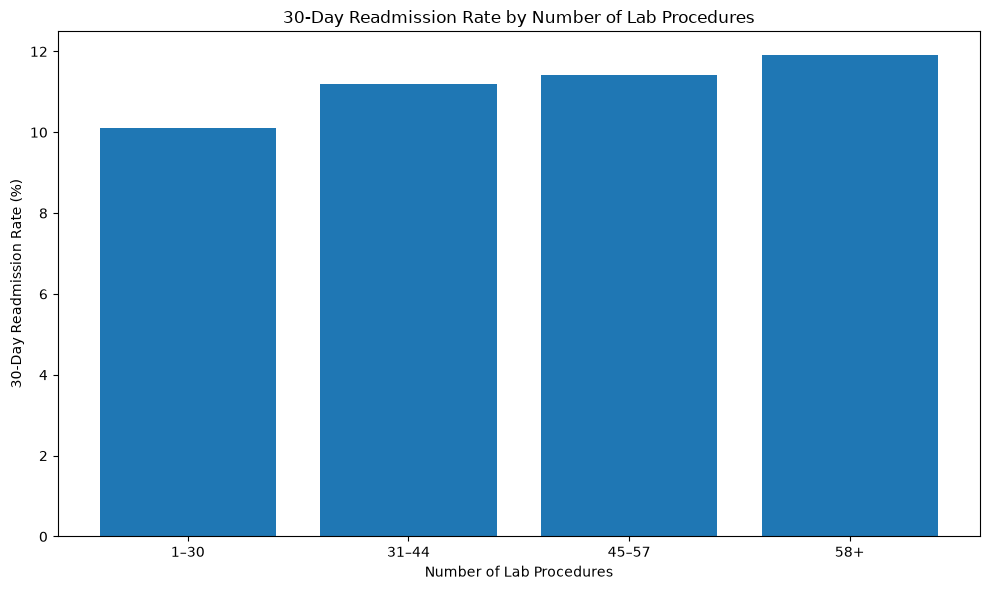

In [158]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    lab_group_analysis["lab_procedure_group"].astype(str),
    lab_group_analysis["readmission_rate"]
)
plt.xlabel("Number of Lab Procedures")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Number of Lab Procedures")
plt.tight_layout()
plt.show()

### Findings — Number of Lab Procedures

- The 30-day readmission rate shows a gradual increase as the number of laboratory procedures increases.
- Patients with **1–30 lab procedures** had a readmission rate of **10.10%**.
- Patients with **31–44 lab procedures** had a rate of **11.18%**.
- Patients with **45–57 lab procedures** had a rate of **11.43%**.
- Patients with **58+ lab procedures** had the highest observed rate at **11.90%**.
- The difference between the lowest and highest groups is approximately **1.80 percentage points**.
- This indicates a **modest positive association** between laboratory procedure volume and 30-day readmission in this dataset.
- This is an **unadjusted association and does not establish causation**. Higher laboratory procedure counts may reflect greater clinical complexity, illness severity, or monitoring requirements.
- Grouping the procedure counts was preferable to analyzing individual values because very high procedure counts had very few encounters and could produce unstable rates.

In [159]:
df_analysis["insulin"].value_counts(dropna=False)

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

In [160]:
insulin_analysis = (
    df_analysis
    .groupby("insulin", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
insulin_analysis["readmission_rate"] = (
    insulin_analysis["readmissions_30d"]
    / insulin_analysis["total_encounters"]
    * 100
)
insulin_analysis

,insulin,total_encounters,readmissions_30d,readmission_rate
0,Down,12218,1698,13.897528
1,No,47383,4756,10.037355
2,Steady,30849,3433,11.128400
3,Up,11316,1470,12.990456


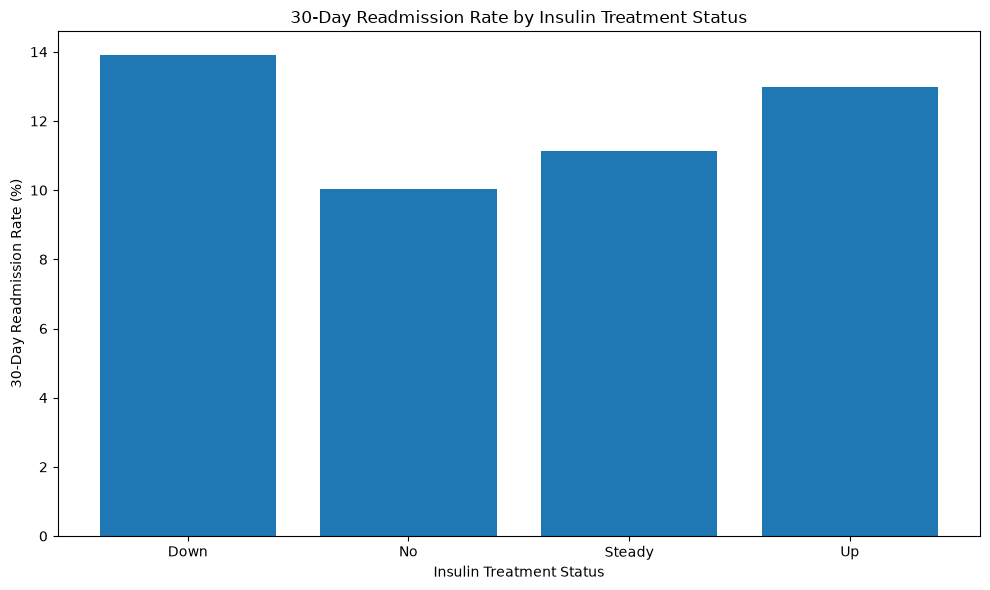

In [161]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    insulin_analysis["insulin"],
    insulin_analysis["readmission_rate"]
)
plt.xlabel("Insulin Treatment Status")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Insulin Treatment Status")
plt.tight_layout()
plt.show()

### Findings — Insulin Treatment Status

- The observed 30-day readmission rate differed across insulin treatment categories.
- Patients with **No insulin** had a readmission rate of **10.04%**.
- Patients with **Steady insulin** had a rate of **11.13%**.
- Patients with insulin treatment **Up** had a rate of **12.99%**.
- Patients with insulin treatment **Down** had the highest observed rate at **13.90%**.
- The difference between the **No insulin** and **Down** groups was approximately **3.86 percentage points**.
- The pattern suggests an association between insulin treatment status and 30-day readmission in this dataset.
- This is an **unadjusted association and does not establish causation**. Changes in insulin treatment may reflect differences in disease severity, treatment complexity, comorbidities, or other patient characteristics.
- The results should therefore be interpreted as an exploratory finding rather than evidence that a particular insulin treatment status causes readmission.

In [162]:
df_analysis["change"].value_counts(dropna=False)

change
No    54755
Ch    47011
Name: count, dtype: int64

In [163]:
change_analysis = (
    df_analysis
    .groupby("change", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
change_analysis["readmission_rate"] = (
    change_analysis["readmissions_30d"]
    / change_analysis["total_encounters"]
    * 100
)
change_analysis

,change,total_encounters,readmissions_30d,readmission_rate
0,Ch,47011,5558,11.822765
1,No,54755,5799,10.590814


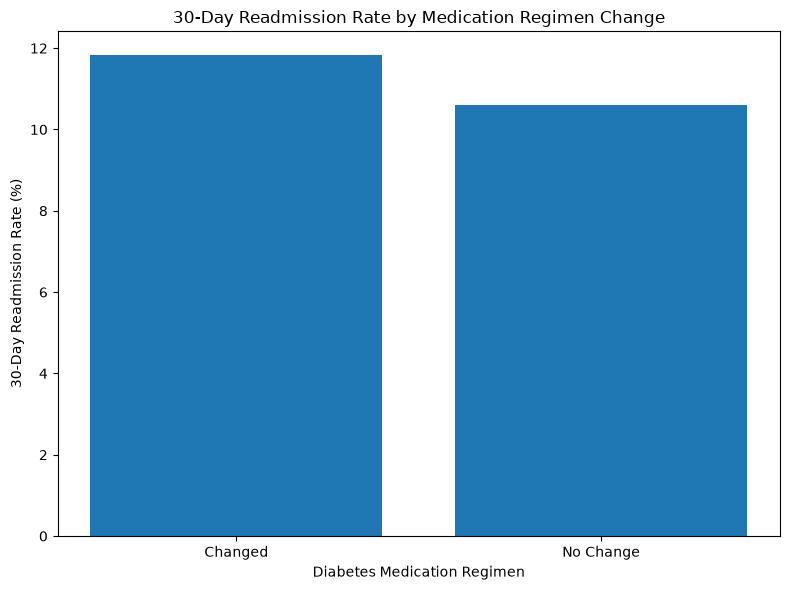

In [164]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(
    change_analysis["change"].map({
        "No": "No Change",
        "Ch": "Changed"
    }),
    change_analysis["readmission_rate"]
)
plt.xlabel("Diabetes Medication Regimen")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Medication Regimen Change")
plt.tight_layout()
plt.show()

### Findings — Diabetes Medication Regimen Change

- Encounters with **no change** in the diabetes medication regimen had a 30-day readmission rate of **10.59%**.
- Encounters where the medication regimen was **changed** had a rate of **11.82%**.
- The difference between the two groups was approximately **1.23 percentage points**.
- The observed data therefore shows a **modest positive association** between medication regimen change and 30-day readmission.
- This is an **unadjusted association and does not establish causation**.
- A medication change may reflect differences in disease severity, treatment response, clinical complexity, or other patient characteristics.
- The result should therefore be treated as an **exploratory finding** rather than evidence that changing medication causes readmission.

In [165]:
df_clean["A1Cresult"].value_counts(dropna=False)

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [166]:
a1c_analysis = (
    df_clean
    .dropna(subset=["A1Cresult"])
    .assign(
        readmitted_30d=(
            df_clean.loc[df_clean["A1Cresult"].notna(), "readmitted"] == "<30"
        ).astype(int)
    )
    .groupby("A1Cresult", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
a1c_analysis["readmission_rate"] = (
    a1c_analysis["readmissions_30d"]
    / a1c_analysis["total_encounters"]
    * 100
)
a1c_analysis

,A1Cresult,total_encounters,readmissions_30d,readmission_rate
0,>7,3812,383,10.047219
1,>8,8216,811,9.870983
2,Norm,4990,482,9.659319


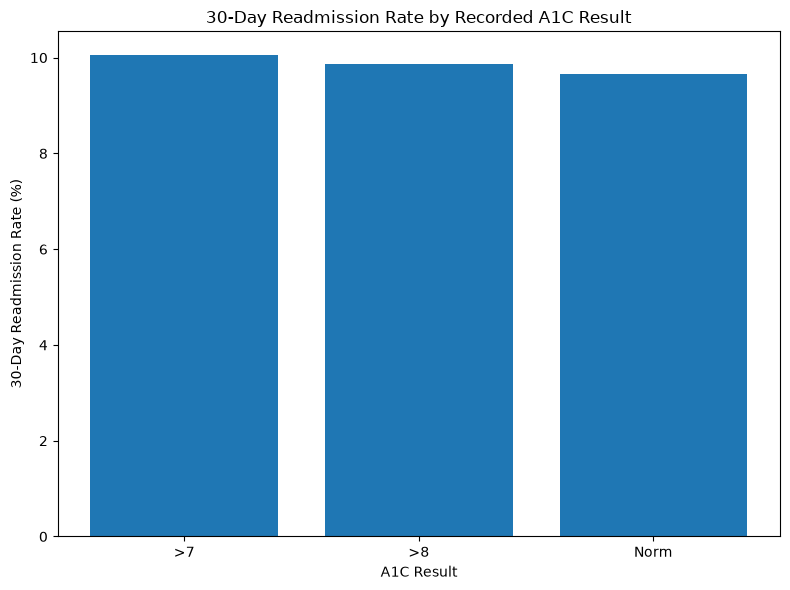

In [167]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(
    a1c_analysis["A1Cresult"],
    a1c_analysis["readmission_rate"]
)
plt.xlabel("A1C Result")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Recorded A1C Result")
plt.tight_layout()
plt.show()

### Findings — Recorded A1C Result

- Among encounters with a recorded A1C result, the 30-day readmission rates were relatively similar across the three categories.
- **Norm:** 9.66% readmission rate.
- **A1C >7:** 10.05% readmission rate.
- **A1C >8:** 9.87% readmission rate.
- The difference between the highest and lowest observed rates was approximately **0.39 percentage points**.
- There was therefore **no large difference in unadjusted 30-day readmission rates** across the recorded A1C categories in this dataset.
- This analysis is limited because **83.3% of encounters had a missing A1C result**.
- The results apply only to encounters where A1C was recorded and should not be generalized to the entire dataset without further analysis.
- Missingness may itself be related to clinical circumstances, testing practices, or patient characteristics.
- These findings represent an **unadjusted exploratory analysis and do not establish causation**.

In [168]:
df_clean["max_glu_serum"].value_counts(dropna=False)

max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [169]:
glucose_analysis = (
    df_clean
    .dropna(subset=["max_glu_serum"])
    .assign(
        readmitted_30d=(
            df_clean.loc[df_clean["max_glu_serum"].notna(), "readmitted"] == "<30"
        ).astype(int)
    )
    .groupby("max_glu_serum", observed=True)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
glucose_analysis["readmission_rate"] = (
    glucose_analysis["readmissions_30d"]
    / glucose_analysis["total_encounters"]
    * 100
)
glucose_analysis

,max_glu_serum,total_encounters,readmissions_30d,readmission_rate
0,>200,1485,185,12.457912
1,>300,1264,181,14.319620
2,Norm,2597,295,11.359261


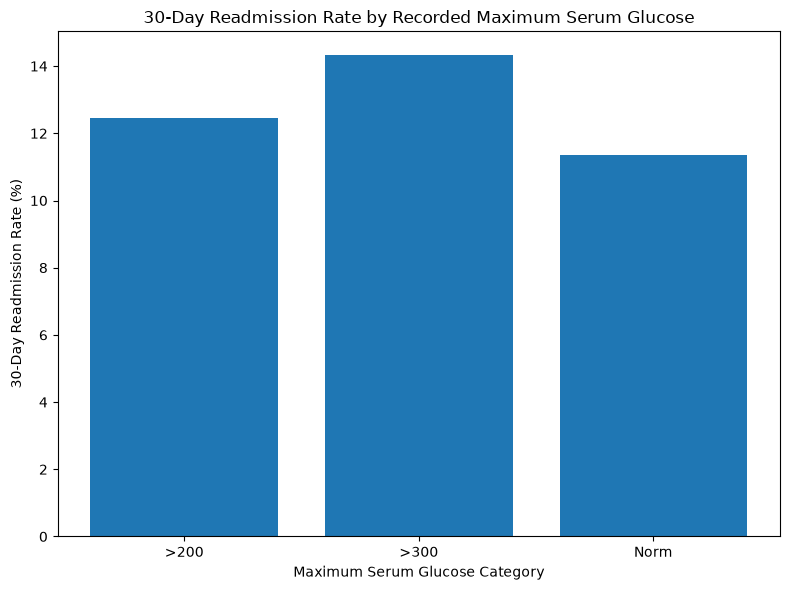

In [170]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(
    glucose_analysis["max_glu_serum"],
    glucose_analysis["readmission_rate"]
)
plt.xlabel("Maximum Serum Glucose Category")
plt.ylabel("30-Day Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Recorded Maximum Serum Glucose")
plt.tight_layout()
plt.show()

## Findings – Maximum Serum Glucose

- Among encounters with a recorded maximum serum glucose result, the 30-day readmission rate increased from **11.36% for Normal** glucose to **12.46% for >200** and **14.32% for >300**.
- The difference between the Normal and >300 groups was approximately **2.96 percentage points**.
- This suggests a **positive unadjusted association** between higher recorded maximum serum glucose category and 30-day readmission.
- However, maximum serum glucose was recorded for only **5,346 of 101,766 encounters (5.25%)**, while **94.75% were missing**.
- Therefore, these findings apply only to the **recorded-glucose subset** and should not be generalized to all encounters without further analysis.
- Higher glucose may also reflect differences in illness severity, comorbidity, or clinical complexity.
- **No causal relationship is inferred from this analysis.**

In [171]:
df_analysis["diag_1"].value_counts(dropna=False).head(30)

diag_1
428       6862
414       6581
786       4016
410       3614
486       3508
427       2766
491       2275
715       2151
682       2042
434       2028
780       2019
996       1967
276       1889
38        1688
250.8     1680
599       1595
584       1520
V57       1207
250.6     1183
518       1115
820       1082
577       1057
493       1056
435       1016
562        989
574        965
296        896
560        876
250.7      871
250.13     851
Name: count, dtype: int64

In [172]:
df_analysis["diag_1_category"] = (
    df_analysis["diag_1"]
    .astype("string")
    .str.extract(r"^(\d{3})")[0]
)
df_analysis["diag_1_category"].value_counts(dropna=False).head(30)

diag_1_category
250     8757
428     6862
414     6581
<NA>    4312
786     4016
410     3614
486     3508
427     2766
491     2275
715     2151
682     2042
434     2028
780     2019
996     1967
276     1889
599     1595
584     1520
518     1115
820     1082
577     1057
493     1056
435     1016
562      989
574      965
296      896
560      876
440      840
433      789
998      784
722      771
Name: count, dtype: Int64

In [173]:
diag1_analysis = (
    df_analysis
    .groupby("diag_1_category", dropna=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diag1_analysis["readmission_rate"] = (
    diag1_analysis["readmissions_30d"]
    / diag1_analysis["total_encounters"]
    * 100
)
diag1_analysis = (
    diag1_analysis[
        diag1_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
diag1_analysis

,diag_1_category,total_encounters,readmissions_30d,readmission_rate
236,434,2028,329,16.222880
241,440,840,133,15.833333
508,820,1082,171,15.804067
211,403,513,79,15.399610
289,507,610,90,14.754098
230,428,6862,968,14.106674
106,276,1889,257,13.605082
343,577,1057,142,13.434248
623,996,1967,264,13.421454
627,<NA>,4312,574,13.311688


In [174]:
diag1_chart = (
    diag1_analysis[
        diag1_analysis["diag_1_category"].notna()
    ]
    .sort_values("total_encounters", ascending=False)
    .head(15)
    .sort_values("readmission_rate", ascending=False)
)
diag1_chart

,diag_1_category,total_encounters,readmissions_30d,readmission_rate
236,434,2028,329,16.222880
230,428,6862,968,14.106674
106,276,1889,257,13.605082
623,996,1967,264,13.421454
92,250,8757,1137,12.983899
280,491,2275,287,12.615385
362,599,1595,171,10.721003
214,410,3614,373,10.320974
442,715,2151,215,9.995351
473,780,2019,191,9.460129


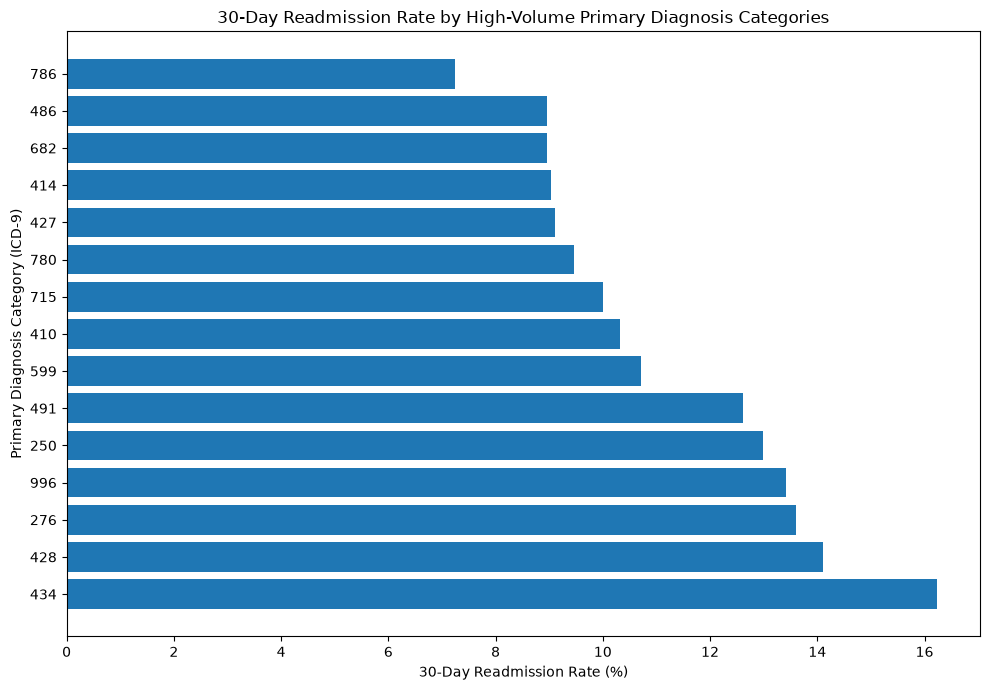

In [175]:
plt.figure(figsize=(10, 7))
plt.barh(
    diag1_chart["diag_1_category"].astype(str),
    diag1_chart["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Primary Diagnosis Category (ICD-9)")
plt.title("30-Day Readmission Rate by High-Volume Primary Diagnosis Categories")
plt.tight_layout()
plt.show()

## Findings – Primary Diagnosis

- Among the 15 highest-volume primary diagnosis categories, observed 30-day readmission rates varied substantially, ranging from **7.25% to 16.22%**.
- Diagnosis category **434** had the highest observed rate among these high-volume categories at **16.22%**, based on 2,028 encounters.
- Diagnosis category **428** had a readmission rate of **14.11%** across 6,862 encounters.
- Diagnosis category **250** had **8,757 encounters** and a readmission rate of **12.98%**.
- Diagnosis category **786** had the lowest observed rate among these 15 high-volume categories at **7.25%**, based on 4,016 encounters.
- These differences indicate that **primary diagnosis category is an important variable to investigate further** when studying 30-day readmission.
- The analysis uses 3-digit ICD-9 categories to combine related subcodes and reduce instability from very small groups.
- The chart includes the 15 highest-volume diagnosis categories rather than ranking all diagnosis categories by readmission rate, which reduces the influence of very small groups.
- The results are **unadjusted associations** and do not establish that a particular diagnosis causes readmission.
- Differences may also reflect patient demographics, comorbidities, illness severity, utilization history, treatment patterns, and other factors.

In [176]:
df_analysis["diag_2"].value_counts(dropna=False).head(30)

diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
250.01    1523
285       1520
780       1491
425       1434
682       1433
486       1379
518       1355
424       1071
413       1042
250.6      895
493        881
305        702
786        644
280        606
998        571
Name: count, dtype: int64

In [177]:
df_analysis["diag_2_category"] = (
    df_analysis["diag_2"]
    .astype("string")
    .str.extract(r"^(\d{3})")[0]
)
df_analysis["diag_2_category"].value_counts(dropna=False).head(30)

diag_2_category
250     12794
276      6752
428      6662
427      5036
<NA>     4454
401      3736
496      3305
599      3288
403      2823
414      2650
411      2566
707      1999
585      1871
584      1649
491      1545
285      1520
780      1491
425      1434
682      1433
486      1379
518      1355
424      1071
413      1042
493       881
305       702
786       644
280       606
998       571
410       549
511       519
Name: count, dtype: Int64

In [178]:
diag2_analysis = (
    df_analysis
    .groupby("diag_2_category", dropna=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diag2_analysis["readmission_rate"] = (
    diag2_analysis["readmissions_30d"]
    / diag2_analysis["total_encounters"]
    * 100
)
diag2_analysis = (
    diag2_analysis[
        diag2_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
diag2_analysis

,diag_2_category,total_encounters,readmissions_30d,readmission_rate
201,403,2823,429,15.196599
462,785,516,77,14.922481
339,585,1871,272,14.537680
414,707,1999,285,14.257129
396,682,1433,190,13.258897
270,491,1545,201,13.009709
282,511,519,66,12.716763
219,428,6662,842,12.638847
216,425,1434,175,12.203626
98,276,6752,810,11.996445


In [179]:
diag2_chart = (
    diag2_analysis[
        diag2_analysis["diag_2_category"].notna()
    ]
    .sort_values("total_encounters", ascending=False)
    .head(15)
    .sort_values("readmission_rate", ascending=False)
)
diag2_chart

,diag_2_category,total_encounters,readmissions_30d,readmission_rate
201,403,2823,429,15.196599
339,585,1871,272,14.537680
414,707,1999,285,14.257129
270,491,1545,201,13.009709
219,428,6662,842,12.638847
98,276,6752,810,11.996445
338,584,1649,190,11.522135
350,599,3288,371,11.283455
218,427,5036,563,11.179508
275,496,3305,368,11.134644


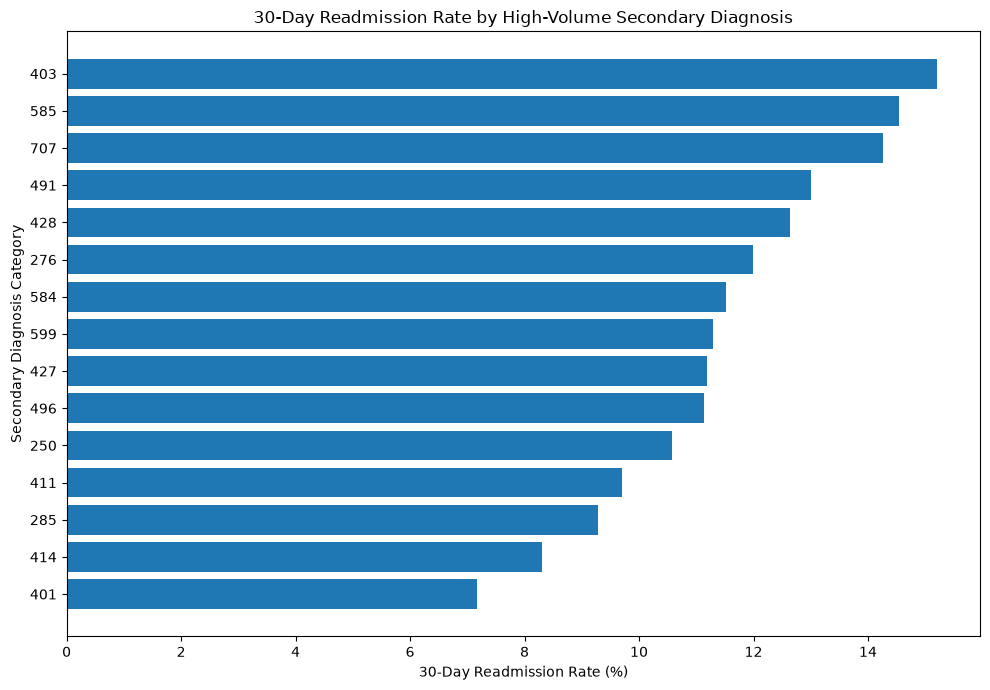

In [180]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.barh(
    diag2_chart["diag_2_category"].astype(str),
    diag2_chart["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Secondary Diagnosis Category")
plt.title("30-Day Readmission Rate by High-Volume Secondary Diagnosis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Findings – Secondary Diagnosis

- Among the **15 highest-volume secondary diagnosis categories**, observed 30-day readmission rates ranged from **7.17% to 15.20%**.
- Category **403** had the highest observed rate among these high-volume categories at **15.20%**, based on 2,823 encounters.
- Category **585** had a readmission rate of **14.54%** across 1,871 encounters.
- Category **707** had a readmission rate of **14.26%** across 1,999 encounters.
- Category **428** had **6,662 encounters** and a readmission rate of **12.64%**.
- Category **276** had **6,752 encounters** and a readmission rate of **12.00%**.
- Category **250** was the largest secondary diagnosis category, with **12,794 encounters**, and had a readmission rate of **10.58%**.
- Category **401** had the lowest observed rate among these 15 high-volume categories at **7.17%**, based on 3,736 encounters.
- The difference between the highest and lowest observed rates was approximately **8.02 percentage points**.
- The analysis uses **3-digit numeric ICD-9 categories** to combine related diagnosis subcodes and reduce instability from very small groups.
- The chart includes the **15 highest-volume categories**, rather than simply selecting the categories with the highest readmission rates, to reduce the influence of small groups.
- These findings represent **unadjusted associations** and do not establish that a secondary diagnosis causes readmission.
- Differences may also reflect patient characteristics, comorbidities, illness severity, prior utilization, treatment patterns, and other factors.

In [181]:
df_analysis["diag_3"].value_counts(dropna=False).head(30)

diag_3
250       11555
401        8289
276        5175
428        4577
427        3955
414        3664
496        2605
403        2357
585        1992
272        1969
599        1941
NaN        1423
V45        1389
250.02     1369
707        1360
780        1334
285        1200
425        1136
250.6      1080
424        1063
584         963
305         924
250.01      915
682         887
518         854
41          727
493         694
278         680
530         625
786         584
Name: count, dtype: int64

In [182]:
df_analysis["diag_3_category"] = (
    df_analysis["diag_3"]
    .astype("string")
    .str.extract(r"^(\d{3})")[0]
)
df_analysis["diag_3_category"].value_counts(dropna=False).head(30)

diag_3_category
250     17157
401      8289
<NA>     8007
276      5175
428      4577
427      3955
414      3664
496      2605
403      2357
585      1992
272      1969
599      1941
707      1360
780      1334
285      1200
425      1136
424      1063
584       963
305       924
682       887
518       854
493       694
278       680
530       625
786       584
491       574
486       568
244       540
411       399
280       398
Name: count, dtype: Int64

In [183]:
diag3_analysis = (
    df_analysis
    .groupby("diag_3_category", dropna=False)["readmitted_30d"]
    .agg(
        total_encounters="count",
        readmissions_30d="sum"
    )
    .reset_index()
)
diag3_analysis["readmission_rate"] = (
    diag3_analysis["readmissions_30d"]
    / diag3_analysis["total_encounters"]
    * 100
)
diag3_analysis = (
    diag3_analysis[
        diag3_analysis["total_encounters"] >= 500
    ]
    .sort_values("readmission_rate", ascending=False)
)
diag3_analysis

,diag_3_category,total_encounters,readmissions_30d,readmission_rate
347,585,1992,336,16.867470
208,403,2357,385,16.334323
428,707,1360,202,14.852941
282,496,2605,350,13.435701
346,584,963,127,13.187954
274,486,568,74,13.028169
410,682,887,113,12.739572
295,518,854,106,12.412178
359,599,1941,239,12.313241
226,428,4577,560,12.235088


In [184]:
diag3_chart = (
    diag3_analysis[
        diag3_analysis["diag_3_category"].notna()
    ]
    .sort_values("total_encounters", ascending=False)
    .head(15)
    .sort_values("readmission_rate", ascending=False)
)
diag3_chart

,diag_3_category,total_encounters,readmissions_30d,readmission_rate
347,585,1992,336,16.867470
208,403,2357,385,16.334323
428,707,1360,202,14.852941
282,496,2605,350,13.435701
359,599,1941,239,12.313241
226,428,4577,560,12.235088
104,276,5175,603,11.652174
225,427,3955,459,11.605563
223,425,1136,131,11.531690
476,780,1334,149,11.169415


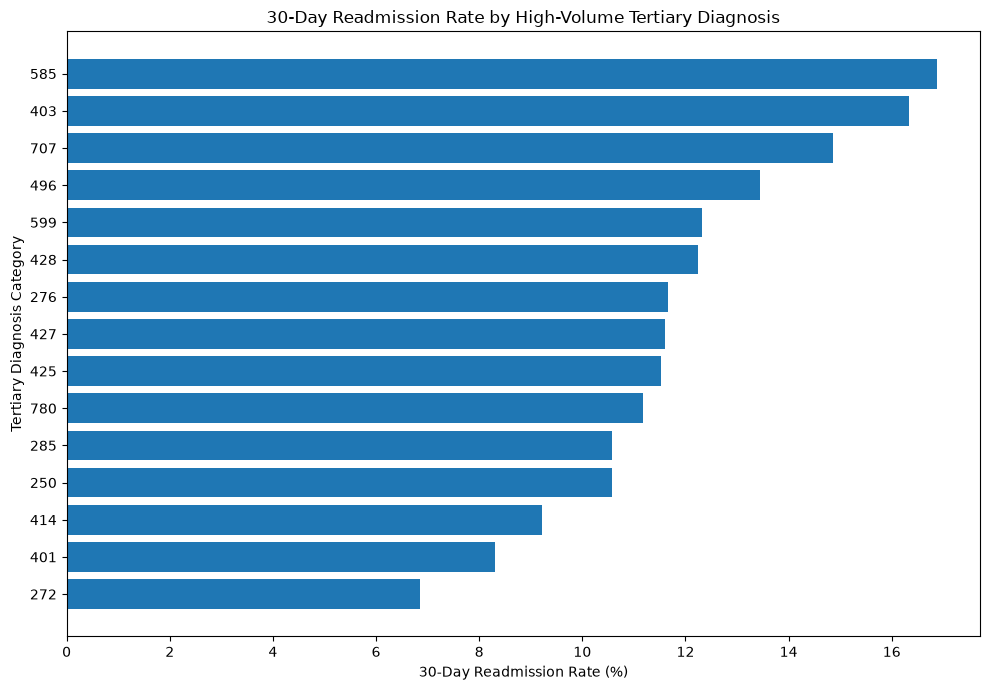

In [185]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.barh(
    diag3_chart["diag_3_category"].astype(str),
    diag3_chart["readmission_rate"]
)
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Tertiary Diagnosis Category")
plt.title("30-Day Readmission Rate by High-Volume Tertiary Diagnosis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Findings – Tertiary Diagnosis

- Among the **15 highest-volume tertiary diagnosis categories**, observed 30-day readmission rates ranged from **6.86% to 16.87%**.
- Category **585** had the highest observed rate among these high-volume categories at **16.87%**, based on 1,992 encounters.
- Category **403** had a readmission rate of **16.33%** across 2,357 encounters.
- Category **707** had a readmission rate of **14.85%** across 1,360 encounters.
- Category **428** had **4,577 encounters** and a readmission rate of **12.24%**.
- Category **276** had **5,175 encounters** and a readmission rate of **11.65%**.
- Category **250** was the largest tertiary diagnosis category, with **17,157 encounters**, and had a readmission rate of **10.57%**.
- Category **401** had **8,289 encounters** and a readmission rate of **8.30%**.
- Category **272** had the lowest observed rate among these 15 high-volume categories at **6.86%**, based on 1,969 encounters.
- The difference between the highest and lowest observed rates was approximately **10.01 percentage points**.
- The analysis uses **3-digit numeric ICD-9 categories** to combine related diagnosis subcodes and reduce instability from very small groups.
- The chart includes the **15 highest-volume categories**, rather than simply selecting categories with the highest readmission rates, to reduce the influence of small groups.
- These findings represent **unadjusted associations** and do not establish that a tertiary diagnosis causes readmission.
- Differences may also reflect patient characteristics, comorbidities, illness severity, prior utilization, treatment patterns, and other factors.
- The analysis excludes non-numeric ICD-9 categories such as `V45` from the numeric category grouping, so the `<NA>` category should not be interpreted as a clinical diagnosis.

# Overall EDA Findings

## Stronger Observed Associations

The exploratory analysis identified several variables with notable unadjusted differences in 30-day readmission rates:

- **Prior inpatient visits:** Readmission increased from **8.44%** among patients with no prior inpatient visits to **30.70%** among those with 4 or more prior inpatient visits.
- **Prior emergency visits:** Readmission increased from **10.47%** with no prior emergency visits to **24.94%** among patients with 3 or more prior emergency visits.
- **Number of diagnoses:** Readmission increased from **7.71%** for 1–4 diagnoses to **14.78%** for 10 or more diagnoses.
- **Number of medications:** Readmission generally increased from **7.48%** for 1–5 medications to **12.87%** for 21–30 medications.
- **Insulin treatment:** Readmission was **10.04%** for patients with no insulin treatment versus **13.90%** among patients whose insulin status was recorded as Down.
- **Maximum serum glucose:** Among the small recorded subset, readmission increased from **11.36%** for Normal glucose to **14.32%** for >300.
- **Primary diagnosis:** Among high-volume diagnosis categories, observed rates varied substantially.
- **Secondary diagnosis:** Among high-volume categories, observed rates ranged from **7.17% to 15.20%**.
- **Tertiary diagnosis:** Among high-volume categories, observed rates ranged from **6.86% to 16.87%**.

## Moderate or Less Consistent Associations

- **Length of stay:** Readmission generally increased with longer hospitalization, although the highest group did not continue the pattern perfectly.
- **Number of lab procedures:** A gradual increase was observed, from **10.10%** in the lowest group to **11.90%** in the highest group.
- **Admission type:** Differences were relatively modest across the major admission categories.
- **Gender:** Female and male readmission rates were very similar.
- **Race:** Readmission rates among the major recorded racial groups were relatively similar.
- **Outpatient visits:** Patients with prior outpatient visits had somewhat higher rates than those with none, but the relationship was not consistently increasing.
- **Number of procedures:** No clear monotonic relationship was observed.

## Important Data Limitations

- `A1Cresult` was missing for approximately **83.3%** of encounters.
- `max_glu_serum` was missing for approximately **94.7%** of encounters.
- `weight` was missing for approximately **96.9%** of encounters and was excluded from the main analysis.
- `medical_specialty` was missing for approximately **49.1%** of encounters.
- `payer_code` was missing for approximately **39.6%** of encounters.
- Some diagnosis fields contain non-numeric ICD-9 codes such as `V` codes that were not included in the numeric 3-digit grouping.

## Interpretation

These results represent **exploratory, unadjusted associations**. They identify variables that may contain useful information about 30-day readmission, but they do not establish causation.

Several observed relationships may reflect underlying differences in patient complexity, comorbidity, illness severity, prior healthcare utilization, or treatment patterns.

The next stage of the project will therefore evaluate multiple predictors together using **multivariable analysis**.

In [186]:
# Review variables available for modeling
modeling_overview = pd.DataFrame({
    "column": df_analysis.columns,
    "data_type": df_analysis.dtypes.astype(str).values,
    "missing_values": df_analysis.isna().sum().values,
    "unique_values": df_analysis.nunique(dropna=True).values
})
modeling_overview

,column,data_type,missing_values,unique_values
0,encounter_id,int64,0,101766
1,patient_nbr,int64,0,71518
2,race,str,2273,5
3,gender,str,0,3
4,age,str,0,10
...,...,...,...,...
60,prior_outpatient_group,category,0,5
61,length_of_stay_group,category,0,5
62,diag_1_category,string,4312,627
63,diag_2_category,string,4454,591


In [187]:
# Define the initial variables for multivariable analysis
model_features = [
    "age",
    "gender",
    "race",
    "admission_type_id",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
    "num_lab_procedures",
    "num_procedures",
    "insulin",
    "change",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
target = "readmitted_30d"
model_df = df_analysis[model_features + [target]].copy()
print("Modeling dataset shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df[target].value_counts())
print("\nTarget rate:")
print(model_df[target].mean() * 100)

Modeling dataset shape: (101766, 18)

Target distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Target rate:
11.159915885462727


In [188]:
# Check missing values in the modeling dataset
missing_model = (
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)
missing_model

diag_3_category       8007
diag_2_category       4454
diag_1_category       4312
race                  2273
gender                   0
age                      0
number_outpatient        0
admission_type_id        0
number_inpatient         0
number_emergency         0
number_diagnoses         0
num_medications          0
time_in_hospital         0
num_lab_procedures       0
change                   0
insulin                  0
num_procedures           0
readmitted_30d           0
dtype: int64

In [189]:
# Create a modeling copy and handle missing categorical values
model_df_clean = model_df.copy()
categorical_columns = [
    "age",
    "gender",
    "race",
    "insulin",
    "change",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
for col in categorical_columns:
    model_df_clean[col] = (
        model_df_clean[col]
        .astype("string")
        .fillna("Unknown")
    )
print("Remaining missing values:")
print(model_df_clean.isna().sum().sort_values(ascending=False).head(10))

Remaining missing values:
age                  0
gender               0
race                 0
admission_type_id    0
number_inpatient     0
number_emergency     0
number_outpatient    0
time_in_hospital     0
num_medications      0
number_diagnoses     0
dtype: int64


In [190]:
# Inspect categorical variables before encoding
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(model_df_clean[col].value_counts().head(20))


--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: Int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: Int64

--- race ---
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: Int64

--- insulin ---
insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: Int64

--- change ---
change
No    54755
Ch    47011
Name: count, dtype: Int64

--- diag_1_category ---
diag_1_category
250        8757
428        6862
414        6581
Unknown    4312
786        4016
410        3614
486        3508
427        2766
491        2275
715        2151
682        2042
434        2028
780        2019
996        1967
276  

In [191]:
# Check how many diagnosis categories meet different frequency thresholds
diagnosis_columns = [
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
thresholds = [100, 250, 500, 1000]
for col in diagnosis_columns:
    print(f"\n--- {col} ---")
    
    counts = model_df_clean[col].value_counts()
    
    for threshold in thresholds:
        number_of_categories = (counts >= threshold).sum()
        encounters = counts[counts >= threshold].sum()
        
        print(
            f"Categories with >= {threshold} encounters: "
            f"{number_of_categories} | "
            f"Encounters covered: {encounters:,}"
        )


--- diag_1_category ---
Categories with >= 100 encounters: 121 | Encounters covered: 92,209
Categories with >= 250 encounters: 66 | Encounters covered: 83,876
Categories with >= 500 encounters: 36 | Encounters covered: 73,562
Categories with >= 1000 encounters: 22 | Encounters covered: 63,228

--- diag_2_category ---
Categories with >= 100 encounters: 107 | Encounters covered: 93,771
Categories with >= 250 encounters: 56 | Encounters covered: 85,736
Categories with >= 500 encounters: 31 | Encounters covered: 76,843
Categories with >= 1000 encounters: 23 | Encounters covered: 71,855

--- diag_3_category ---
Categories with >= 100 encounters: 110 | Encounters covered: 93,759
Categories with >= 250 encounters: 58 | Encounters covered: 85,467
Categories with >= 500 encounters: 28 | Encounters covered: 75,674
Categories with >= 1000 encounters: 17 | Encounters covered: 67,781


In [192]:
# Group less frequent diagnosis categories into "Other"
model_df_encoded = model_df_clean.copy()
diagnosis_threshold = 500
for col in diagnosis_columns:
    counts = model_df_encoded[col].value_counts()
    
    frequent_categories = counts[counts >= diagnosis_threshold].index
    
    model_df_encoded[col] = model_df_encoded[col].where(
        model_df_encoded[col].isin(frequent_categories),
        "Other"
    )
# Check the resulting number of categories
for col in diagnosis_columns:
    print(f"\n--- {col} ---")
    print("Number of categories:", model_df_encoded[col].nunique())
    print(model_df_encoded[col].value_counts().head(10))


--- diag_1_category ---
Number of categories: 37
diag_1_category
Other      28204
250         8757
428         6862
414         6581
Unknown     4312
786         4016
410         3614
486         3508
427         2766
491         2275
Name: count, dtype: Int64

--- diag_2_category ---
Number of categories: 32
diag_2_category
Other      24923
250        12794
276         6752
428         6662
427         5036
Unknown     4454
401         3736
496         3305
599         3288
403         2823
Name: count, dtype: Int64

--- diag_3_category ---
Number of categories: 29
diag_3_category
Other      26092
250        17157
401         8289
Unknown     8007
276         5175
428         4577
427         3955
414         3664
496         2605
403         2357
Name: count, dtype: Int64


In [193]:
# One-hot encode categorical variables
categorical_columns_model = [
    "age",
    "gender",
    "race",
    "insulin",
    "change",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
model_encoded = pd.get_dummies(
    model_df_encoded,
    columns=categorical_columns_model,
    drop_first=True,
    dtype=int
)
print("Encoded dataset shape:", model_encoded.shape)
print("\nFirst 10 columns:")
print(model_encoded.columns[:10].tolist())
print("\nData types:")
print(model_encoded.dtypes.value_counts())

Encoded dataset shape: (101766, 125)

First 10 columns:
['admission_type_id', 'number_inpatient', 'number_emergency', 'number_outpatient', 'time_in_hospital', 'num_medications', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'readmitted_30d']

Data types:
int64    125
Name: count, dtype: int64


In [194]:
# Separate predictors (X) and target (y)
X = model_encoded.drop(columns=["readmitted_30d"])
y = model_encoded["readmitted_30d"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (101766, 124)
y shape: (101766,)

Target distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Target percentage:
readmitted_30d
0    88.84
1    11.16
Name: proportion, dtype: float64


In [195]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nTest target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Note: you may need to restart the kernel to use updated packages.
Training set:
X_train: (81412, 124)
y_train: (81412,)

Test set:
X_test: (20354, 124)
y_test: (20354,)

Training target distribution (%):
readmitted_30d
0    88.84
1    11.16
Name: proportion, dtype: float64

Test target distribution (%):
readmitted_30d
0    88.84
1    11.16
Name: proportion, dtype: float64


In [196]:
from sklearn.linear_model import LogisticRegression
# Create and train the baseline logistic regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train, y_train)
print("Logistic regression model trained successfully.")
print("Number of coefficients:", len(logistic_model.coef_[0]))

Logistic regression model trained successfully.
Number of coefficients: 124


d:\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [197]:
from sklearn.preprocessing import StandardScaler
# Numeric variables that need scaling
numeric_model_columns = [
    "admission_type_id",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
    "num_lab_procedures",
    "num_procedures"
]
# Create copies so the original encoded dataset remains unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# Fit scaler only on training data
scaler = StandardScaler()
X_train_scaled[numeric_model_columns] = scaler.fit_transform(
    X_train[numeric_model_columns]
)
# Apply the same transformation to test data
X_test_scaled[numeric_model_columns] = scaler.transform(
    X_test[numeric_model_columns]
)
print("Scaling completed.")
print("\nTraining shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("\nTraining numeric means after scaling:")
print(X_train_scaled[numeric_model_columns].mean().round(3))

Scaling completed.

Training shape: (81412, 124)
Test shape: (20354, 124)

Training numeric means after scaling:
admission_type_id    -0.0
number_inpatient     -0.0
number_emergency      0.0
number_outpatient     0.0
time_in_hospital      0.0
num_medications       0.0
number_diagnoses      0.0
num_lab_procedures   -0.0
num_procedures        0.0
dtype: float64


In [198]:
from sklearn.linear_model import LogisticRegression
# Train logistic regression on scaled predictors
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)
print("Logistic regression model trained successfully.")
print("Number of coefficients:", len(logistic_model.coef_[0]))
print("Iterations used:", logistic_model.n_iter_[0])

Logistic regression model trained successfully.
Number of coefficients: 124
Iterations used: 65


In [199]:
# Generate predictions on the unseen test set
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
print("Predictions generated successfully.")
print("\nPredicted classes:")
print(pd.Series(y_pred).value_counts())
print("\nFirst 10 predicted probabilities:")
print(y_pred_proba[:10])

Predictions generated successfully.

Predicted classes:
0    13122
1     7232
Name: count, dtype: int64

First 10 predicted probabilities:
[0.57263966 0.32082194 0.50437875 0.61227988 0.44078687 0.33917975
 0.41521664 0.38163663 0.68820021 0.58267309]


In [200]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
# Calculate evaluation metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Confusion Matrix:")
print(cm)
print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Confusion Matrix:
[[12094  5989]
 [ 1028  1243]]

Model Performance:
Accuracy : 0.6553
Precision: 0.1719
Recall   : 0.5473
F1 Score : 0.2616
ROC-AUC  : 0.6516


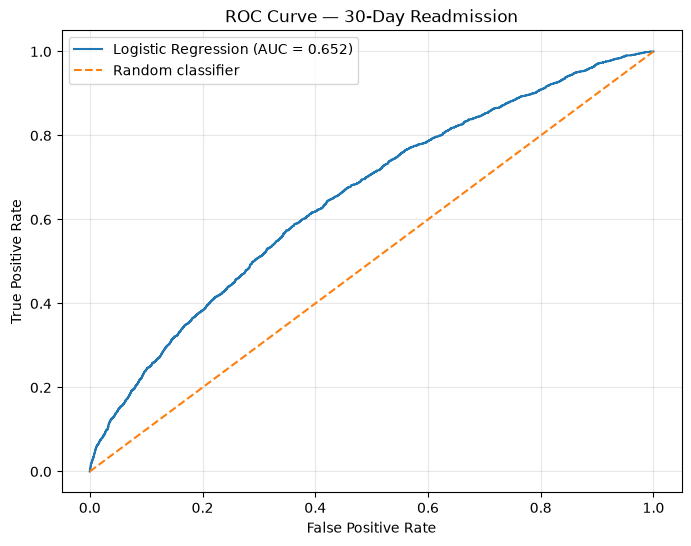

In [201]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 30-Day Readmission")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [202]:
# Check whether the same patients appear in both training and test sets
train_indices = X_train.index
test_indices = X_test.index
train_patients = set(df_analysis.loc[train_indices, "patient_nbr"])
test_patients = set(df_analysis.loc[test_indices, "patient_nbr"])
overlapping_patients = train_patients.intersection(test_patients)
print("Unique patients in training set:", len(train_patients))
print("Unique patients in test set:", len(test_patients))
print("Patients appearing in both sets:", len(overlapping_patients))

Unique patients in training set: 60132
Unique patients in test set: 18387
Patients appearing in both sets: 7001


In [203]:
from sklearn.model_selection import GroupShuffleSplit
# Patient IDs corresponding to each modeling row
patient_groups = df_analysis.loc[model_encoded.index, "patient_nbr"]
# Create patient-level train/test split
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)
train_idx, test_idx = next(
    group_splitter.split(X, y, groups=patient_groups)
)
X_train_patient = X.iloc[train_idx].copy()
X_test_patient = X.iloc[test_idx].copy()
y_train_patient = y.iloc[train_idx].copy()
y_test_patient = y.iloc[test_idx].copy()
print("Patient-level split created successfully.")
print("\nTraining:")
print("X:", X_train_patient.shape)
print("y:", y_train_patient.shape)
print("\nTesting:")
print("X:", X_test_patient.shape)
print("y:", y_test_patient.shape)
print("\nTraining readmission rate:", y_train_patient.mean())
print("Test readmission rate:", y_test_patient.mean())

Patient-level split created successfully.

Training:
X: (81613, 124)
y: (81613,)

Testing:
X: (20153, 124)
y: (20153,)

Training readmission rate: 0.11280065675811451
Test readmission rate: 0.10673348881059892


In [204]:
# Verify that no patient appears in both training and test sets
train_patient_ids = set(
    df_analysis.loc[X_train_patient.index, "patient_nbr"]
)
test_patient_ids = set(
    df_analysis.loc[X_test_patient.index, "patient_nbr"]
)
patient_overlap = train_patient_ids.intersection(test_patient_ids)
print("Unique patients in training:", len(train_patient_ids))
print("Unique patients in testing:", len(test_patient_ids))
print("Patients appearing in both sets:", len(patient_overlap))

Unique patients in training: 57214
Unique patients in testing: 14304
Patients appearing in both sets: 0


In [205]:
from sklearn.preprocessing import StandardScaler
# Create copies
X_train_patient_scaled = X_train_patient.copy()
X_test_patient_scaled = X_test_patient.copy()
# Fit scaler only on training data
patient_scaler = StandardScaler()
X_train_patient_scaled[numeric_model_columns] = (
    patient_scaler.fit_transform(
        X_train_patient[numeric_model_columns]
    )
)
# Apply the already-fitted scaler to test data
X_test_patient_scaled[numeric_model_columns] = (
    patient_scaler.transform(
        X_test_patient[numeric_model_columns]
    )
)
print("Patient-level scaling completed.")
print("\nTraining shape:", X_train_patient_scaled.shape)
print("Testing shape:", X_test_patient_scaled.shape)
print("\nTraining means after scaling:")
print(
    X_train_patient_scaled[numeric_model_columns]
    .mean()
    .round(4)
)

Patient-level scaling completed.

Training shape: (81613, 124)
Testing shape: (20153, 124)

Training means after scaling:
admission_type_id     0.0
number_inpatient      0.0
number_emergency     -0.0
number_outpatient    -0.0
time_in_hospital      0.0
num_medications      -0.0
number_diagnoses      0.0
num_lab_procedures    0.0
num_procedures        0.0
dtype: float64


In [206]:
from sklearn.linear_model import LogisticRegression
patient_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)
patient_logistic_model.fit(
    X_train_patient_scaled,
    y_train_patient
)
print("Patient-level logistic regression trained successfully.")
print("Number of coefficients:", len(patient_logistic_model.coef_[0]))
print("Iterations used:", patient_logistic_model.n_iter_[0])

Patient-level logistic regression trained successfully.
Number of coefficients: 124
Iterations used: 58


In [207]:
# Generate predictions on the patient-level test set
y_pred_patient = patient_logistic_model.predict(
    X_test_patient_scaled
)
y_pred_proba_patient = patient_logistic_model.predict_proba(
    X_test_patient_scaled
)[:, 1]
print("Patient-level predictions generated successfully.")
print("\nPredicted classes:")
print(pd.Series(y_pred_patient).value_counts())
print("\nFirst 10 predicted probabilities:")
print(y_pred_proba_patient[:10])

Patient-level predictions generated successfully.

Predicted classes:
0    13220
1     6933
Name: count, dtype: int64

First 10 predicted probabilities:
[0.55404272 0.41262838 0.4932955  0.53274714 0.47296905 0.31248121
 0.3869541  0.67278697 0.3983284  0.38694067]


In [208]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
# Patient-level model evaluation
cm_patient = confusion_matrix(
    y_test_patient,
    y_pred_patient
)
accuracy_patient = accuracy_score(
    y_test_patient,
    y_pred_patient
)
precision_patient = precision_score(
    y_test_patient,
    y_pred_patient
)
recall_patient = recall_score(
    y_test_patient,
    y_pred_patient
)
f1_patient = f1_score(
    y_test_patient,
    y_pred_patient
)
roc_auc_patient = roc_auc_score(
    y_test_patient,
    y_pred_proba_patient
)
print("Patient-Level Confusion Matrix:")
print(cm_patient)
print("\nPatient-Level Model Performance:")
print(f"Accuracy : {accuracy_patient:.4f}")
print(f"Precision: {precision_patient:.4f}")
print(f"Recall   : {recall_patient:.4f}")
print(f"F1 Score : {f1_patient:.4f}")
print(f"ROC-AUC  : {roc_auc_patient:.4f}")

Patient-Level Confusion Matrix:
[[12155  5847]
 [ 1065  1086]]

Patient-Level Model Performance:
Accuracy : 0.6570
Precision: 0.1566
Recall   : 0.5049
F1 Score : 0.2391
ROC-AUC  : 0.6351


In [209]:
print("Admission type ID values:")
print(
    df_analysis["admission_type_id"]
    .value_counts()
    .sort_index()
)
print("\nCurrent admission type feature in model:")
print(
    X["admission_type_id"].describe()
)

Admission type ID values:
admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

Current admission type feature in model:
count    101766.000000
mean          2.024006
std           1.445403
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           8.000000
Name: admission_type_id, dtype: float64


In [210]:
# Rebuild the modeling dataset with admission_type_id treated as categorical
model_df_refined = model_df_clean.copy()
categorical_columns_refined = [
    "age",
    "gender",
    "race",
    "admission_type_id",
    "insulin",
    "change",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
# Group infrequent diagnosis categories as before
for col in diagnosis_columns:
    counts = model_df_refined[col].value_counts()
    frequent_categories = counts[counts >= diagnosis_threshold].index

    model_df_refined[col] = model_df_refined[col].where(
        model_df_refined[col].isin(frequent_categories),
        "Other"
    )
# One-hot encode categorical variables
model_encoded_refined = pd.get_dummies(
    model_df_refined,
    columns=categorical_columns_refined,
    drop_first=True,
    dtype=int
)
print("Refined encoded dataset shape:", model_encoded_refined.shape)
print("\nAdmission type encoded columns:")
print(
    [
        col
        for col in model_encoded_refined.columns
        if col.startswith("admission_type_id_")
    ]
)

Refined encoded dataset shape: (101766, 131)

Admission type encoded columns:
['admission_type_id_2', 'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_6', 'admission_type_id_7', 'admission_type_id_8']


In [211]:
# Create refined feature matrix and target
X_refined = model_encoded_refined.drop(columns=["readmitted_30d"])
y_refined = model_encoded_refined["readmitted_30d"]
print("X_refined shape:", X_refined.shape)
print("y_refined shape:", y_refined.shape)
print("\nTarget distribution:")
print(y_refined.value_counts())
print("\nTarget percentage:")
print(
    (y_refined.value_counts(normalize=True) * 100).round(2)
)

X_refined shape: (101766, 130)
y_refined shape: (101766,)

Target distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Target percentage:
readmitted_30d
0    88.84
1    11.16
Name: proportion, dtype: float64


In [212]:
from sklearn.model_selection import GroupShuffleSplit
# Patient IDs used as groups
patient_groups_refined = df_analysis.loc[
    X_refined.index, "patient_nbr"
]
# Create patient-level train/test split
group_splitter_refined = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)
train_idx_refined, test_idx_refined = next(
    group_splitter_refined.split(
        X_refined,
        y_refined,
        groups=patient_groups_refined
    )
)
# Create train/test datasets
X_train_refined = X_refined.iloc[train_idx_refined].copy()
X_test_refined = X_refined.iloc[test_idx_refined].copy()
y_train_refined = y_refined.iloc[train_idx_refined].copy()
y_test_refined = y_refined.iloc[test_idx_refined].copy()
print("Training shape:", X_train_refined.shape)
print("Testing shape:", X_test_refined.shape)
print("\nTraining readmission rate:")
print(y_train_refined.mean())
print("\nTesting readmission rate:")
print(y_test_refined.mean())
# Verify patient overlap
train_patient_ids_refined = set(
    df_analysis.loc[X_train_refined.index, "patient_nbr"]
)
test_patient_ids_refined = set(
    df_analysis.loc[X_test_refined.index, "patient_nbr"]
)
patient_overlap_refined = (
    train_patient_ids_refined.intersection(test_patient_ids_refined)
)
print("\nUnique patients in training:", len(train_patient_ids_refined))
print("Unique patients in testing:", len(test_patient_ids_refined))
print("Patients appearing in both:", len(patient_overlap_refined))

Training shape: (81613, 130)
Testing shape: (20153, 130)

Training readmission rate:
0.11280065675811451

Testing readmission rate:
0.10673348881059892

Unique patients in training: 57214
Unique patients in testing: 14304
Patients appearing in both: 0


In [213]:
# Continuous numerical variables to scale
numeric_model_columns_refined = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
    "num_lab_procedures",
    "num_procedures"
]
from sklearn.preprocessing import StandardScaler
# Create copies so the original refined datasets remain unchanged
X_train_refined_scaled = X_train_refined.copy()
X_test_refined_scaled = X_test_refined.copy()
# Fit scaler ONLY on training data
refined_scaler = StandardScaler()
X_train_refined_scaled[numeric_model_columns_refined] = (
    refined_scaler.fit_transform(
        X_train_refined[numeric_model_columns_refined]
    )
)
# Apply the same training scaler to test data
X_test_refined_scaled[numeric_model_columns_refined] = (
    refined_scaler.transform(
        X_test_refined[numeric_model_columns_refined]
    )
)
print("Training scaled shape:", X_train_refined_scaled.shape)
print("Testing scaled shape:", X_test_refined_scaled.shape)
print("\nTraining means after scaling:")
print(
    X_train_refined_scaled[numeric_model_columns_refined]
    .mean()
    .round(4)
)
print("\nTraining standard deviations after scaling:")
print(
    X_train_refined_scaled[numeric_model_columns_refined]
    .std()
    .round(4)
)

Training scaled shape: (81613, 130)
Testing scaled shape: (20153, 130)

Training means after scaling:
number_inpatient      0.0
number_emergency     -0.0
number_outpatient    -0.0
time_in_hospital      0.0
num_medications      -0.0
number_diagnoses      0.0
num_lab_procedures    0.0
num_procedures        0.0
dtype: float64

Training standard deviations after scaling:
number_inpatient      1.0
number_emergency      1.0
number_outpatient     1.0
time_in_hospital      1.0
num_medications       1.0
number_diagnoses      1.0
num_lab_procedures    1.0
num_procedures        1.0
dtype: float64


In [214]:
from sklearn.linear_model import LogisticRegression
refined_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)
refined_logistic_model.fit(
    X_train_refined_scaled,
    y_train_refined
)
print("Model training completed.")
print("Number of coefficients:", len(refined_logistic_model.coef_[0]))
print("Number of iterations:", refined_logistic_model.n_iter_[0])

Model training completed.
Number of coefficients: 130
Number of iterations: 65


In [215]:
# Generate predictions for the unseen patient test set
y_pred_refined = refined_logistic_model.predict(
    X_test_refined_scaled
)
y_pred_proba_refined = refined_logistic_model.predict_proba(
    X_test_refined_scaled
)[:, 1]
print("Predicted class distribution:")
print(
    pd.Series(y_pred_refined)
    .value_counts()
    .sort_index()
)
print("\nFirst 10 predicted probabilities:")
print(
    y_pred_proba_refined[:10]
)

Predicted class distribution:
0    13193
1     6960
Name: count, dtype: int64

First 10 predicted probabilities:
[0.5529005  0.41356202 0.49352265 0.53672137 0.47290551 0.31219195
 0.38380603 0.66543559 0.39377938 0.38793061]


In [216]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
# Confusion matrix
cm_refined = confusion_matrix(
    y_test_refined,
    y_pred_refined
)
# Classification metrics
accuracy_refined = accuracy_score(
    y_test_refined,
    y_pred_refined
)
precision_refined = precision_score(
    y_test_refined,
    y_pred_refined
)
recall_refined = recall_score(
    y_test_refined,
    y_pred_refined
)
f1_refined = f1_score(
    y_test_refined,
    y_pred_refined
)
roc_auc_refined = roc_auc_score(
    y_test_refined,
    y_pred_proba_refined
)
print("Confusion Matrix:")
print(cm_refined)
print("\nModel Performance:")
print(f"Accuracy : {accuracy_refined:.4f}")
print(f"Precision: {precision_refined:.4f}")
print(f"Recall   : {recall_refined:.4f}")
print(f"F1 Score : {f1_refined:.4f}")
print(f"ROC-AUC  : {roc_auc_refined:.4f}")

Confusion Matrix:
[[12136  5866]
 [ 1057  1094]]

Model Performance:
Accuracy : 0.6565
Precision: 0.1572
Recall   : 0.5086
F1 Score : 0.2401
ROC-AUC  : 0.6356


In [217]:
# Compare previous patient-level model with refined model
baseline_metrics = {
    "Accuracy": 0.6570,
    "Precision": 0.1566,
    "Recall": 0.5049,
    "F1 Score": 0.2391,
    "ROC-AUC": 0.6351
}
refined_metrics = {
    "Accuracy": accuracy_refined,
    "Precision": precision_refined,
    "Recall": recall_refined,
    "F1 Score": f1_refined,
    "ROC-AUC": roc_auc_refined
}
comparison_df = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline": list(baseline_metrics.values()),
    "Refined": list(refined_metrics.values())
})
comparison_df["Change"] = (
    comparison_df["Refined"] - comparison_df["Baseline"]
)
print(comparison_df.round(4))

      Metric  Baseline  Refined  Change
0   Accuracy    0.6570   0.6565 -0.0005
1  Precision    0.1566   0.1572  0.0006
2     Recall    0.5049   0.5086  0.0037
3   F1 Score    0.2391   0.2401  0.0010
4    ROC-AUC    0.6351   0.6356  0.0005


In [218]:
# Extract logistic regression coefficients
coefficient_df = pd.DataFrame({
    "Feature": X_train_refined_scaled.columns,
    "Coefficient": refined_logistic_model.coef_[0]
})
# Convert coefficients to odds ratios
coefficient_df["Odds_Ratio"] = np.exp(
    coefficient_df["Coefficient"]
)
# Sort by absolute coefficient to identify strongest associations
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)
coefficient_df_sorted = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)
print("Top 20 features by absolute coefficient:")
print(
    coefficient_df_sorted[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].head(20).to_string(index=False)
)

Top 20 features by absolute coefficient:
            Feature  Coefficient  Odds_Ratio
diag_1_category_722    -0.575836    0.562234
diag_1_category_518    -0.513883    0.598168
diag_2_category_786    -0.487607    0.614094
diag_1_category_820     0.437424    1.548712
diag_1_category_434     0.430666    1.538282
diag_2_category_493    -0.430548    0.650153
diag_1_category_486    -0.421497    0.656064
diag_2_category_305    -0.420472    0.656737
diag_2_category_285    -0.400646    0.669887
diag_1_category_786    -0.393472    0.674710
   number_inpatient     0.360520    1.434075
diag_2_category_486    -0.358173    0.698952
        age_[80-90)     0.352909    1.423202
        age_[70-80)     0.347981    1.416205
diag_1_category_682    -0.345731    0.707703
diag_1_category_493    -0.337218    0.713753
diag_2_category_518    -0.321974    0.724717
diag_1_category_599    -0.313133    0.731152
       age_[90-100)     0.312809    1.367260
diag_3_category_278    -0.307487    0.735293


In [219]:
# Add category sample sizes to the coefficient table
feature_sample_sizes = {}
for col in diagnosis_columns:
    counts = model_df_encoded[col].value_counts()
    
    for category, count in counts.items():
        feature_name = f"{col}_{category}"
        feature_sample_sizes[feature_name] = count
# Add sample size for categorical age groups
age_counts = model_df_encoded["age"].value_counts()
for category, count in age_counts.items():
    feature_sample_sizes[f"age_{category}"] = count
# Add sample size for other categorical variables
for col in ["gender", "race", "insulin", "change", "admission_type_id"]:
    counts = model_df_encoded[col].value_counts()
    
    for category, count in counts.items():
        feature_sample_sizes[f"{col}_{category}"] = count
coefficient_df_sorted["Sample_Size"] = (
    coefficient_df_sorted["Feature"]
    .map(feature_sample_sizes)
)
print(
    coefficient_df_sorted[
        ["Feature", "Coefficient", "Odds_Ratio", "Sample_Size"]
    ].head(20).to_string(index=False)
)

            Feature  Coefficient  Odds_Ratio  Sample_Size
diag_1_category_722    -0.575836    0.562234        771.0
diag_1_category_518    -0.513883    0.598168       1115.0
diag_2_category_786    -0.487607    0.614094        644.0
diag_1_category_820     0.437424    1.548712       1082.0
diag_1_category_434     0.430666    1.538282       2028.0
diag_2_category_493    -0.430548    0.650153        881.0
diag_1_category_486    -0.421497    0.656064       3508.0
diag_2_category_305    -0.420472    0.656737        702.0
diag_2_category_285    -0.400646    0.669887       1520.0
diag_1_category_786    -0.393472    0.674710       4016.0
   number_inpatient     0.360520    1.434075          NaN
diag_2_category_486    -0.358173    0.698952       1379.0
        age_[80-90)     0.352909    1.423202      17197.0
        age_[70-80)     0.347981    1.416205      26068.0
diag_1_category_682    -0.345731    0.707703       2042.0
diag_1_category_493    -0.337218    0.713753       1056.0
diag_2_categor

In [220]:
# Calculate standard errors and 95% confidence intervals
# for the logistic regression coefficients
import numpy as np
X_train_matrix = X_train_refined_scaled.values
n = X_train_matrix.shape[0]
p = X_train_matrix.shape[1]
# Predicted probabilities on training data
train_probabilities = refined_logistic_model.predict_proba(
    X_train_refined_scaled
)[:, 1]
# Design matrix with intercept
X_design = np.column_stack([
    np.ones(n),
    X_train_matrix
])
# Weight matrix for logistic regression
W = train_probabilities * (1 - train_probabilities)
# Calculate covariance matrix
X_weighted = X_design.T * W
covariance_matrix = np.linalg.pinv(
    X_weighted @ X_design
)
# Standard errors excluding intercept
standard_errors = np.sqrt(
    np.diag(covariance_matrix)[1:]
)
# Coefficients
coefficients = refined_logistic_model.coef_[0]
# 95% confidence intervals for coefficients
lower_coef = coefficients - 1.96 * standard_errors
upper_coef = coefficients + 1.96 * standard_errors
# Convert to odds-ratio scale
odds_ratios = np.exp(coefficients)
lower_or = np.exp(lower_coef)
upper_or = np.exp(upper_coef)
coefficient_ci_df = pd.DataFrame({
    "Feature": X_train_refined_scaled.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratios,
    "CI_Lower_95": lower_or,
    "CI_Upper_95": upper_or
})
# Sort by absolute coefficient
coefficient_ci_df["Absolute_Coefficient"] = (
    coefficient_ci_df["Coefficient"].abs()
)
coefficient_ci_df = coefficient_ci_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)
print(
    coefficient_ci_df[
        [
            "Feature",
            "Coefficient",
            "Odds_Ratio",
            "CI_Lower_95",
            "CI_Upper_95"
        ]
    ].head(20).round(4).to_string(index=False)
)

            Feature  Coefficient  Odds_Ratio  CI_Lower_95  CI_Upper_95
diag_1_category_722      -0.5758      0.5622       0.4667       0.6773
diag_1_category_518      -0.5139      0.5982       0.5134       0.6970
diag_2_category_786      -0.4876      0.6141       0.5074       0.7433
diag_1_category_820       0.4374      1.5487       1.3317       1.8011
diag_1_category_434       0.4307      1.5383       1.3683       1.7294
diag_2_category_493      -0.4305      0.6502       0.5538       0.7633
diag_1_category_486      -0.4215      0.6561       0.5953       0.7230
diag_2_category_305      -0.4205      0.6567       0.5457       0.7903
diag_2_category_285      -0.4006      0.6699       0.5897       0.7610
diag_1_category_786      -0.3935      0.6747       0.6134       0.7421
   number_inpatient       0.3605      1.4341       1.4081       1.4605
diag_2_category_486      -0.3582      0.6990       0.6123       0.7979
        age_[80-90)       0.3529      1.4232       0.9702       2.0877
      

In [221]:
# Identify associations whose 95% OR confidence interval
# does not cross 1.00
significant_associations = coefficient_ci_df[
    (
        (coefficient_ci_df["CI_Lower_95"] > 1.00) |
        (coefficient_ci_df["CI_Upper_95"] < 1.00)
    )
].copy()
# Calculate distance from OR = 1 for sorting
significant_associations["OR_Distance"] = (
    (significant_associations["Odds_Ratio"] - 1).abs()
)
# Show strongest associations by distance from 1
significant_associations = significant_associations.sort_values(
    "OR_Distance",
    ascending=False
)
print(
    significant_associations[
        [
            "Feature",
            "Odds_Ratio",
            "CI_Lower_95",
            "CI_Upper_95"
        ]
    ].head(20).round(4).to_string(index=False)
)
print(
    "\nNumber of associations with 95% CI excluding OR=1:",
    len(significant_associations)
)

            Feature  Odds_Ratio  CI_Lower_95  CI_Upper_95
diag_1_category_820      1.5487       1.3317       1.8011
diag_1_category_434      1.5383       1.3683       1.7294
diag_1_category_722      0.5622       0.4667       0.6773
   number_inpatient      1.4341       1.4081       1.4605
diag_1_category_518      0.5982       0.5134       0.6970
diag_2_category_786      0.6141       0.5074       0.7433
diag_2_category_493      0.6502       0.5538       0.7633
diag_1_category_486      0.6561       0.5953       0.7230
diag_2_category_305      0.6567       0.5457       0.7903
diag_1_category_440      1.3398       1.1362       1.5798
diag_2_category_285      0.6699       0.5897       0.7610
diag_1_category_786      0.6747       0.6134       0.7421
diag_3_category_585      1.3142       1.0503       1.6444
diag_2_category_486      0.6990       0.6123       0.7979
diag_3_category_403      1.3009       1.0446       1.6201
diag_1_category_682      0.7077       0.6315       0.7931
diag_1_categor

In [222]:
# Extract unique ICD-9 category codes from significant associations
import re
significant_features = significant_associations["Feature"].tolist()
icd9_codes = sorted(
    set(
        re.findall(
            r"diag_[123]_category_(\d{3})",
            " ".join(significant_features)
        )
    )
)
print("ICD-9 category codes requiring interpretation:")
print(icd9_codes)
print("\nNumber of unique ICD-9 codes:", len(icd9_codes))

ICD-9 category codes requiring interpretation:
['272', '276', '278', '285', '305', '401', '403', '411', '413', '414', '424', '427', '434', '435', '440', '486', '491', '493', '496', '507', '518', '530', '562', '574', '578', '584', '585', '599', '682', '715', '722', '780', '786', '820', '998']

Number of unique ICD-9 codes: 35


In [223]:
# ICD-9 three-digit category descriptions
# Used to make model results understandable to healthcare stakeholders.
icd9_descriptions = {
    "272": "Disorders of lipoid metabolism",
    "276": "Disorders of fluid, electrolyte, and acid-base balance",
    "278": "Overweight, obesity and other hyperalimentation",
    "285": "Other and unspecified anemias",
    "305": "Nondependent abuse of drugs",
    "401": "Essential hypertension",
    "403": "Hypertensive chronic kidney disease",
    "411": "Other acute and subacute forms of ischemic heart disease",
    "413": "Angina pectoris",
    "414": "Other forms of chronic ischemic heart disease",
    "424": "Other diseases of mitral and aortic valves",
    "427": "Cardiac dysrhythmias",
    "434": "Occlusion of cerebral arteries",
    "435": "Transient cerebral ischemia",
    "440": "Atherosclerosis",
    "486": "Pneumonia, organism unspecified",
    "491": "Chronic bronchitis",
    "493": "Asthma",
    "496": "Chronic airway obstruction, not elsewhere classified",
    "507": "Pneumonitis due to solids and liquids",
    "518": "Other diseases of lung",
    "530": "Diseases of esophagus",
    "562": "Diverticula of intestine",
    "574": "Cholelithiasis",
    "578": "Gastrointestinal hemorrhage",
    "584": "Acute kidney failure",
    "585": "Chronic kidney disease",
    "599": "Other disorders of urethra and urinary tract",
    "682": "Other cellulitis and abscess",
    "715": "Osteoarthrosis",
    "722": "Intervertebral disc disorders",
    "780": "General symptoms",
    "786": "Symptoms involving respiratory system",
    "820": "Fracture of neck of femur",
    "998": "Complications of medical care, not elsewhere classified"
}
# Verify that every extracted code has a description
mapping_check = pd.DataFrame({
    "ICD9_Code": icd9_codes
})
mapping_check["Description"] = mapping_check["ICD9_Code"].map(
    icd9_descriptions
)
print(mapping_check.to_string(index=False))
print(
    "\nCodes without a description:",
    mapping_check["Description"].isna().sum()
)

ICD9_Code                                              Description
      272                           Disorders of lipoid metabolism
      276   Disorders of fluid, electrolyte, and acid-base balance
      278          Overweight, obesity and other hyperalimentation
      285                            Other and unspecified anemias
      305                              Nondependent abuse of drugs
      401                                   Essential hypertension
      403                      Hypertensive chronic kidney disease
      411 Other acute and subacute forms of ischemic heart disease
      413                                          Angina pectoris
      414            Other forms of chronic ischemic heart disease
      424               Other diseases of mitral and aortic valves
      427                                     Cardiac dysrhythmias
      434                           Occlusion of cerebral arteries
      435                              Transient cerebral isch

In [224]:
# Build an interpretable clinical association table
clinical_associations = significant_associations.copy()
# Extract ICD-9 code from diagnosis features
clinical_associations["ICD9_Code"] = (
    clinical_associations["Feature"]
    .str.extract(r"diag_[123]_category_(\d{3})")[0]
)
# Add clinical description
clinical_associations["Clinical_Description"] = (
    clinical_associations["ICD9_Code"]
    .map(icd9_descriptions)
)
# Identify whether modeled odds are higher or lower than the reference
clinical_associations["Association_Direction"] = np.where(
    clinical_associations["Odds_Ratio"] > 1,
    "Higher modeled odds",
    "Lower modeled odds"
)
# Approximate percentage difference from OR = 1
clinical_associations["OR_Percent_Difference"] = (
    (clinical_associations["Odds_Ratio"] - 1) * 100
)
# Add sample sizes
clinical_associations["Sample_Size"] = (
    clinical_associations["Feature"]
    .map(feature_sample_sizes)
)
# Select useful columns
clinical_associations_final = clinical_associations[
    [
        "Feature",
        "ICD9_Code",
        "Clinical_Description",
        "Association_Direction",
        "Odds_Ratio",
        "CI_Lower_95",
        "CI_Upper_95",
        "OR_Percent_Difference",
        "Sample_Size"
    ]
].copy()
# Display the strongest 20 associations
print(
    clinical_associations_final
    .head(20)
    .round(3)
    .to_string(index=False)
)

            Feature ICD9_Code                                 Clinical_Description Association_Direction  Odds_Ratio  CI_Lower_95  CI_Upper_95  OR_Percent_Difference  Sample_Size
diag_1_category_820       820                            Fracture of neck of femur   Higher modeled odds       1.549        1.332        1.801                 54.871       1082.0
diag_1_category_434       434                       Occlusion of cerebral arteries   Higher modeled odds       1.538        1.368        1.729                 53.828       2028.0
diag_1_category_722       722                        Intervertebral disc disorders    Lower modeled odds       0.562        0.467        0.677                -43.777        771.0
   number_inpatient       NaN                                                  NaN   Higher modeled odds       1.434        1.408        1.460                 43.408          NaN
diag_1_category_518       518                               Other diseases of lung    Lower modeled odds 

In [225]:
# Step 86: Summarize strongest modeled associations
top_positive = (
    clinical_associations_final[
        clinical_associations_final["Odds_Ratio"] > 1
    ]
    .sort_values("Odds_Ratio", ascending=False)
    .head(10)
)
top_negative = (
    clinical_associations_final[
        clinical_associations_final["Odds_Ratio"] < 1
    ]
    .sort_values("Odds_Ratio", ascending=True)
    .head(10)
)
print("TOP 10 FEATURES WITH HIGHER MODELED ODDS")
print(
    top_positive[
        [
            "Feature",
            "ICD9_Code",
            "Clinical_Description",
            "Odds_Ratio",
            "CI_Lower_95",
            "CI_Upper_95",
            "Sample_Size"
        ]
    ].round(3).to_string(index=False)
)
print("\n" + "=" * 100 + "\n")
print("TOP 10 FEATURES WITH LOWER MODELED ODDS")
print(
    top_negative[
        [
            "Feature",
            "ICD9_Code",
            "Clinical_Description",
            "Odds_Ratio",
            "CI_Lower_95",
            "CI_Upper_95",
            "Sample_Size"
        ]
    ].round(3).to_string(index=False)
)

TOP 10 FEATURES WITH HIGHER MODELED ODDS
            Feature ICD9_Code                                   Clinical_Description  Odds_Ratio  CI_Lower_95  CI_Upper_95  Sample_Size
diag_1_category_820       820                              Fracture of neck of femur       1.549        1.332        1.801       1082.0
diag_1_category_434       434                         Occlusion of cerebral arteries       1.538        1.368        1.729       2028.0
   number_inpatient       NaN                                                    NaN       1.434        1.408        1.460          NaN
diag_1_category_440       440                                        Atherosclerosis       1.340        1.136        1.580        840.0
diag_3_category_585       585                                 Chronic kidney disease       1.314        1.050        1.644       1992.0
diag_3_category_403       403                    Hypertensive chronic kidney disease       1.301        1.045        1.620       2357.0
diag_3_

In [226]:
# Step 87: Compare baseline and refined logistic regression models
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Refined Logistic Regression"
    ],
    "Accuracy": [
        0.6570,
        0.6565
    ],
    "Precision": [
        0.1566,
        0.1572
    ],
    "Recall": [
        0.5049,
        0.5086
    ],
    "F1_Score": [
        0.2391,
        0.2401
    ],
    "ROC_AUC": [
        0.6351,
        0.6356
    ]
})
print(model_comparison.round(4).to_string(index=False))

                       Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
Baseline Logistic Regression    0.6570     0.1566  0.5049    0.2391   0.6351
 Refined Logistic Regression    0.6565     0.1572  0.5086    0.2401   0.6356


In [227]:
# Step 88: Examine predicted probability distribution
patient_test_probabilities = refined_logistic_model.predict_proba(
    X_test_refined_scaled
)[:, 1]
print("Number of test patients:", len(patient_test_probabilities))
print("Minimum probability:", patient_test_probabilities.min())
print("Maximum probability:", patient_test_probabilities.max())
print("Mean probability:", patient_test_probabilities.mean())
print("Median probability:", np.median(patient_test_probabilities))
print("\nProbability percentiles:")
print(
    pd.Series(patient_test_probabilities).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(4)
)

Number of test patients: 20153
Minimum probability: 0.16548369075923283
Maximum probability: 0.9795660926880038
Mean probability: 0.4713060450366609
Median probability: 0.4562410140329506

Probability percentiles:
count    20153.0000
mean         0.4713
std          0.1166
min          0.1655
10%          0.3380
25%          0.3913
50%          0.4562
75%          0.5338
90%          0.6241
95%          0.6892
99%          0.8267
max          0.9796
dtype: float64


In [228]:
# Step 89: Threshold analysis for the refined logistic regression model
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
thresholds = np.arange(0.20, 0.71, 0.05)
threshold_results = []
for threshold in thresholds:

    y_pred_threshold = (
        patient_test_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_refined,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test_refined,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test_refined,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_refined,
        y_pred_threshold,
        zero_division=0
    )

    flagged_percentage = (
        y_pred_threshold.mean() * 100
    )

    threshold_results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Flagged_Percentage": flagged_percentage
    })
threshold_results_df = pd.DataFrame(threshold_results)
print(
    threshold_results_df.round(4).to_string(index=False)
)

 Threshold   TP    FP    TN   FN  Precision  Recall  F1_Score  Flagged_Percentage
      0.20 2151 17991    11    0     0.1068  1.0000    0.1930             99.9454
      0.25 2147 17832   170    4     0.1075  0.9981    0.1940             99.1366
      0.30 2120 17216   786   31     0.1096  0.9856    0.1973             95.9460
      0.35 2021 15569  2433  130     0.1149  0.9396    0.2048             87.2823
      0.40 1819 12700  5302  332     0.1253  0.8457    0.2182             72.0439
      0.45 1487  9091  8911  664     0.1406  0.6913    0.2336             52.4885
      0.50 1094  5866 12136 1057     0.1572  0.5086    0.2401             34.5358
      0.55  777  3523 14479 1374     0.1807  0.3612    0.2409             21.3368
      0.60  543  2051 15951 1608     0.2093  0.2524    0.2289             12.8715
      0.65  373  1147 16855 1778     0.2454  0.1734    0.2032              7.5423
      0.70  256   665 17337 1895     0.2780  0.1190    0.1667              4.5700


In [229]:
# Step 90: Create final threshold performance summary
threshold_summary = threshold_results_df[
    ["Threshold", "Precision", "Recall", "F1_Score", "Flagged_Percentage"]
].copy()
threshold_summary["Threshold"] = (
    threshold_summary["Threshold"] * 100
)
threshold_summary = threshold_summary.rename(
    columns={
        "Threshold": "Threshold_Percent",
        "Flagged_Percentage": "Patients_Flagged_Percent"
    }
)
print(
    threshold_summary.round(2).to_string(index=False)
)

 Threshold_Percent  Precision  Recall  F1_Score  Patients_Flagged_Percent
              20.0       0.11    1.00      0.19                     99.95
              25.0       0.11    1.00      0.19                     99.14
              30.0       0.11    0.99      0.20                     95.95
              35.0       0.11    0.94      0.20                     87.28
              40.0       0.13    0.85      0.22                     72.04
              45.0       0.14    0.69      0.23                     52.49
              50.0       0.16    0.51      0.24                     34.54
              55.0       0.18    0.36      0.24                     21.34
              60.0       0.21    0.25      0.23                     12.87
              65.0       0.25    0.17      0.20                      7.54
              70.0       0.28    0.12      0.17                      4.57


In [230]:
# Step 91: Precision-Recall analysis
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test_refined,
    patient_test_probabilities
)
average_precision = average_precision_score(
    y_test_refined,
    patient_test_probabilities
)
baseline_prevalence = y_test_refined.mean()
print("Average Precision:", round(average_precision, 4))
print("Baseline prevalence:", round(baseline_prevalence, 4))
print("Baseline prevalence (%):", round(baseline_prevalence * 100, 2))
print("Number of PR curve points:", len(precision_curve))

Average Precision: 0.1824
Baseline prevalence: 0.1067
Baseline prevalence (%): 10.67
Number of PR curve points: 20153


In [231]:
# Step 92: Final model performance summary
final_model_performance = pd.DataFrame({
    "Metric": [
        "Test Set Size",
        "Actual 30-Day Readmission Rate",
        "ROC-AUC",
        "Average Precision",
        "Precision at 0.50",
        "Recall at 0.50",
        "F1 Score at 0.50",
        "Patients Flagged at 0.50",
        "Maximum Recall Observed",
        "Precision at Maximum Recall",
        "F1 Score at Maximum Recall"
    ],
    "Value": [
        len(y_test_refined),
        baseline_prevalence,
        0.6356,
        average_precision,
        0.1572,
        0.5086,
        0.2401,
        0.345358,
        threshold_results_df["Recall"].max(),
        threshold_results_df.loc[
            threshold_results_df["Recall"].idxmax(),
            "Precision"
        ],
        threshold_results_df.loc[
            threshold_results_df["Recall"].idxmax(),
            "F1_Score"
        ]
    ]
})
print(
    final_model_performance.to_string(index=False)
)

                        Metric        Value
                 Test Set Size 20153.000000
Actual 30-Day Readmission Rate     0.106733
                       ROC-AUC     0.635600
             Average Precision     0.182432
             Precision at 0.50     0.157200
                Recall at 0.50     0.508600
              F1 Score at 0.50     0.240100
      Patients Flagged at 0.50     0.345358
       Maximum Recall Observed     1.000000
   Precision at Maximum Recall     0.106792
    F1 Score at Maximum Recall     0.192975


In [232]:
# Step 93: Calibration assessment
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
brier_score = brier_score_loss(
    y_test_refined,
    patient_test_probabilities
)
prob_true, prob_pred = calibration_curve(
    y_test_refined,
    patient_test_probabilities,
    n_bins=10,
    strategy="quantile"
)
calibration_df = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_Readmission_Rate": prob_true
})
print("Brier Score:", round(brier_score, 4))
print("\nCalibration by probability group:")
print(
    calibration_df.round(4).to_string(index=False)
)

Brier Score: 0.2301

Calibration by probability group:
 Mean_Predicted_Probability  Observed_Readmission_Rate
                     0.3000                     0.0501
                     0.3581                     0.0556
                     0.3913                     0.0734
                     0.4183                     0.0829
                     0.4436                     0.0947
                     0.4699                     0.1107
                     0.4987                     0.1107
                     0.5345                     0.1241
                     0.5862                     0.1419
                     0.7125                     0.2232


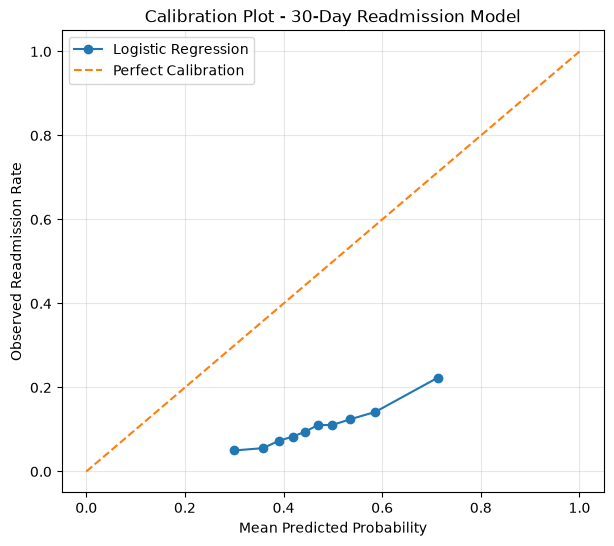

In [233]:
# Step 94: Calibration plot
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Plot - 30-Day Readmission Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [234]:
print("Number of calibration points:", len(prob_pred))
print("\nPredicted probabilities:")
print(prob_pred)
print("\nObserved rates:")
print(prob_true)

Number of calibration points: 10

Predicted probabilities:
[0.29996117 0.35813657 0.39129906 0.4182907  0.44363854 0.46992008
 0.49865384 0.53445874 0.5862214  0.71245943]

Observed rates:
[0.05009921 0.05558313 0.07344913 0.08287841 0.09474206 0.11066998
 0.11066998 0.12406948 0.14193548 0.22321429]


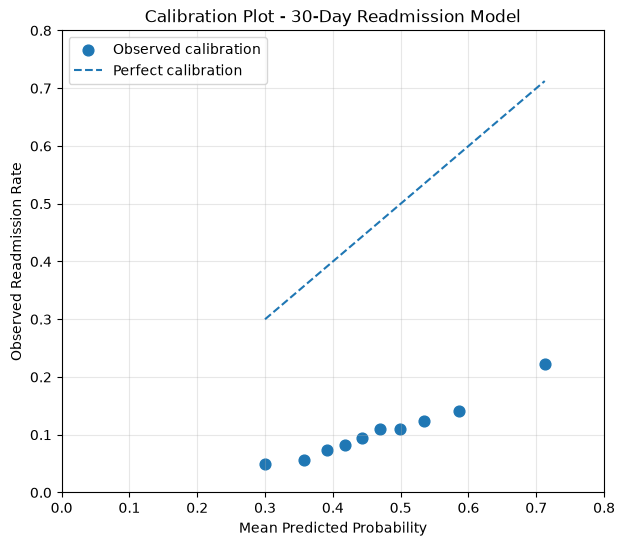

In [235]:
# Step 95: Explicit calibration plot
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
plt.scatter(
    prob_pred,
    prob_true,
    s=60,
    label="Observed calibration"
)
plt.plot(
    prob_pred,
    prob_pred,
    linestyle="--",
    label="Perfect calibration"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Plot - 30-Day Readmission Model")
plt.xlim(0, 0.8)
plt.ylim(0, 0.8)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [236]:
# Step 96: Final model performance summary
from sklearn.metrics import precision_score, recall_score, f1_score
# Recreate predictions at the standard 0.50 threshold
patient_test_predictions = (
    patient_test_probabilities >= 0.50
).astype(int)
final_model_summary = pd.DataFrame({
    "Metric": [
        "Test Set Size",
        "Actual 30-Day Readmission Rate",
        "ROC-AUC",
        "Average Precision",
        "Brier Score",
        "Precision @ 0.50",
        "Recall @ 0.50",
        "F1 Score @ 0.50",
        "Patients Flagged @ 0.50",
        "Maximum Recall Observed"
    ],
    "Value": [
        len(y_test_refined),
        y_test_refined.mean(),
        roc_auc,
        average_precision,
        brier_score,
        precision_score(y_test_refined, patient_test_predictions),
        recall_score(y_test_refined, patient_test_predictions),
        f1_score(y_test_refined, patient_test_predictions),
        (patient_test_predictions == 1).mean(),
        recall_curve.max()
    ]
})
print(final_model_summary.to_string(index=False))

                        Metric        Value
                 Test Set Size 20153.000000
Actual 30-Day Readmission Rate     0.106733
                       ROC-AUC     0.651588
             Average Precision     0.182432
                   Brier Score     0.230143
              Precision @ 0.50     0.157184
                 Recall @ 0.50     0.508601
               F1 Score @ 0.50     0.240149
       Patients Flagged @ 0.50     0.345358
       Maximum Recall Observed     1.000000


In [237]:
# Step 97: Final model conclusion
print("FINAL MODEL CONCLUSION")
print("=" * 60)
print(
    f"The patient-level logistic regression model achieved a "
    f"ROC-AUC of {roc_auc:.4f} and Average Precision of "
    f"{average_precision:.4f} on {len(y_test_refined):,} test patients."
)
print(
    f"At the 0.50 classification threshold, precision was "
    f"{precision_score(y_test_refined, patient_test_predictions):.4f}, "
    f"recall was {recall_score(y_test_refined, patient_test_predictions):.4f}, "
    f"and F1 score was {f1_score(y_test_refined, patient_test_predictions):.4f}."
)
print(
    f"The model flagged "
    f"{(patient_test_predictions == 1).mean():.2%} of test patients, "
    f"while the observed 30-day readmission rate was "
    f"{y_test_refined.mean():.2%}."
)
print(
    f"The Brier score was {brier_score:.4f}, and the calibration analysis "
    f"showed that predicted probabilities were substantially higher "
    f"than observed readmission rates."
)
print(
    "\nOverall interpretation: the model provides modest risk "
    "discrimination but is not sufficiently calibrated or accurate "
    "for direct clinical deployment."
)

FINAL MODEL CONCLUSION
The patient-level logistic regression model achieved a ROC-AUC of 0.6516 and Average Precision of 0.1824 on 20,153 test patients.
At the 0.50 classification threshold, precision was 0.1572, recall was 0.5086, and F1 score was 0.2401.
The model flagged 34.54% of test patients, while the observed 30-day readmission rate was 10.67%.
The Brier score was 0.2301, and the calibration analysis showed that predicted probabilities were substantially higher than observed readmission rates.

Overall interpretation: the model provides modest risk discrimination but is not sufficiently calibrated or accurate for direct clinical deployment.


In [238]:
# Step 98: Model limitations
model_limitations = [
    "The dataset is historical and comes from U.S. hospitals from 1999–2008, so findings may not generalize to current hospitals or other healthcare systems.",
    
    "The analysis uses observational data, so associations identified by the model should not be interpreted as causal relationships.",
    
    "The outcome is relatively uncommon, with approximately 10.67% of the patient-level test set experiencing 30-day readmission.",
    
    "Class weighting was used to address class imbalance, which shifts the predicted score distribution and contributes to poor probability calibration.",
    
    "The model demonstrated only modest discrimination, with a ROC-AUC of approximately 0.65.",
    
    "At the default 0.50 threshold, precision was low, meaning many patients flagged by the model did not experience 30-day readmission.",
    
    "The calibration analysis showed substantial overprediction of absolute risk.",
    
    "Several clinically relevant variables contained substantial missing or placeholder values, including weight, laboratory measurements, medical specialty, and payer information.",
    
    "Diagnosis variables were grouped using frequency thresholds and simplified ICD-9 categories, which may lose some clinical detail.",
    
    "The model was developed and evaluated on a single dataset without external validation or prospective clinical validation.",
    
    "The analysis focused primarily on logistic regression and therefore does not establish that this is the optimal predictive modeling approach for the dataset.",
    
    "Multiple exploratory associations were examined, so statistically significant coefficients should be interpreted cautiously and not treated as independent causal discoveries."
]
print("MODEL LIMITATIONS")
print("=" * 60)
for i, limitation in enumerate(model_limitations, start=1):
    print(f"{i}. {limitation}")

MODEL LIMITATIONS
1. The dataset is historical and comes from U.S. hospitals from 1999–2008, so findings may not generalize to current hospitals or other healthcare systems.
2. The analysis uses observational data, so associations identified by the model should not be interpreted as causal relationships.
3. The outcome is relatively uncommon, with approximately 10.67% of the patient-level test set experiencing 30-day readmission.
4. Class weighting was used to address class imbalance, which shifts the predicted score distribution and contributes to poor probability calibration.
5. The model demonstrated only modest discrimination, with a ROC-AUC of approximately 0.65.
6. At the default 0.50 threshold, precision was low, meaning many patients flagged by the model did not experience 30-day readmission.
7. The calibration analysis showed substantial overprediction of absolute risk.
8. Several clinically relevant variables contained substantial missing or placeholder values, including weig

In [239]:
# Step 99: Final modeling findings summary
modeling_findings = {
    "Model": "Patient-level Logistic Regression",
    "Test Set": f"{len(y_test_refined):,} patients",
    "Observed 30-Day Readmission Rate": f"{y_test_refined.mean():.2%}",
    "ROC-AUC": f"{roc_auc:.4f}",
    "Average Precision": f"{average_precision:.4f}",
    "Brier Score": f"{brier_score:.4f}",
    "Precision @ 0.50": f"{precision_score(y_test_refined, patient_test_predictions):.2%}",
    "Recall @ 0.50": f"{recall_score(y_test_refined, patient_test_predictions):.2%}",
    "F1 Score @ 0.50": f"{f1_score(y_test_refined, patient_test_predictions):.2%}",
    "Patients Flagged @ 0.50": f"{(patient_test_predictions == 1).mean():.2%}",
    "Calibration": "Predicted probabilities substantially overestimated observed readmission rates",
    "Overall Interpretation": "Modest discrimination; not suitable for direct clinical deployment"
}
print("FINAL MODELING FINDINGS")
print("=" * 60)
for key, value in modeling_findings.items():
    print(f"{key}: {value}")

FINAL MODELING FINDINGS
Model: Patient-level Logistic Regression
Test Set: 20,153 patients
Observed 30-Day Readmission Rate: 10.67%
ROC-AUC: 0.6516
Average Precision: 0.1824
Brier Score: 0.2301
Precision @ 0.50: 15.72%
Recall @ 0.50: 50.86%
F1 Score @ 0.50: 24.01%
Patients Flagged @ 0.50: 34.54%
Calibration: Predicted probabilities substantially overestimated observed readmission rates
Overall Interpretation: Modest discrimination; not suitable for direct clinical deployment


In [240]:
df_analysis.shape

(101766, 65)

In [241]:
df_analysis.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'readmitted_30d',
 'inpatient_utilization_group',
 'emergency_utilization_group',
 'outpatient_utilization_group',
 'los_group',
 'medication_group',
 'diagnosis_group',
 'lab

In [242]:
powerbi_columns = [
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "admission_type",
    "admission_source",
    "discharge_disposition",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "insulin",
    "change",
    "diabetesMed",
    "readmitted",
    "readmitted_30d",
    "prior_inpatient_group",
    "prior_emergency_group",
    "prior_outpatient_group",
    "length_of_stay_group",
    "medication_group",
    "diagnosis_group",
    "lab_procedure_group",
    "inpatient_utilization_group",
    "emergency_utilization_group",
    "outpatient_utilization_group",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category"
]
df_powerbi = df_analysis[powerbi_columns].copy()
powerbi_path = "../04_PowerBI_Dashboard/hospital_readmission_powerbi.csv"
df_powerbi.to_csv(powerbi_path, index=False)
print("Power BI dataset created successfully")
print("Shape:", df_powerbi.shape)
print("File:", powerbi_path)
print("Columns:", len(df_powerbi.columns))

Power BI dataset created successfully
Shape: (101766, 34)
File: ../04_PowerBI_Dashboard/hospital_readmission_powerbi.csv
Columns: 34


In [243]:
df_powerbi_check = pd.read_csv(powerbi_path)
print("Shape:", df_powerbi_check.shape)
print("Columns:", df_powerbi_check.columns.tolist())
print("Duplicate rows:", df_powerbi_check.duplicated().sum())
print("Duplicate encounter IDs:", df_powerbi_check["encounter_id"].duplicated().sum())
print("30-day readmissions:", df_powerbi_check["readmitted_30d"].sum())
print("30-day readmission rate:", round(df_powerbi_check["readmitted_30d"].mean() * 100, 2), "%")

Shape: (101766, 34)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type', 'admission_source', 'discharge_disposition', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'insulin', 'change', 'diabetesMed', 'readmitted', 'readmitted_30d', 'prior_inpatient_group', 'prior_emergency_group', 'prior_outpatient_group', 'length_of_stay_group', 'medication_group', 'diagnosis_group', 'lab_procedure_group', 'inpatient_utilization_group', 'emergency_utilization_group', 'outpatient_utilization_group', 'diag_1_category', 'diag_2_category', 'diag_3_category']
Duplicate rows: 0
Duplicate encounter IDs: 0
30-day readmissions: 11357
30-day readmission rate: 11.16 %


In [244]:
df_analysis.groupby("diabetesMed")["readmitted_30d"].agg(
    encounters="count",
    readmissions="sum",
    readmission_rate="mean"
)

,encounters,readmissions,readmission_rate
diabetesMed,,,
No,23403,2246,0.095971
Yes,78363,9111,0.116267
